# Apresentação dos resultados

**Discente: Igor Sousa dos Santos Santana**
<br>
**Docente: Esbel Tomás Valero Orellana**
<br>
**Disciplina: Processamento Paralelo**
<br>

## A proposta

Este trabalho propõe o desenvolvimento e a análise de desempenho de um algoritmo para o cálculo de *Bounding Box* aplicado a conjuntos de dados multidimensionais. A implementação é realizada integralmente na linguagem C, focando em eficiência e controle de baixo nível sobre a memória.

### Objetivos Principais:
- **Estrutura de Dados Customizada:** Para gerenciar os dados de entrada, foi implementada uma estrutura chamada **Tensor**, que encapsula o ponteiro de dados e as informações de dimensionalidade, permitindo uma manipulação robusta de volumes de dados médicos ou científicos.
- **Implementação Sequencial:** Desenvolvimento de uma versão de referência executada em uma única thread, garantindo a corretude do cálculo dos limites espaciais da região de interesse.
- **Implementação Paralela com OpenMP:** Integração da biblioteca OpenMP para distribuir a carga de processamento entre os núcleos da CPU, visando reduzir o tempo de execução em grandes volumes de dados.
    - Os testes foram feitos com 2, 4, 8 e 16 threads;
    - Após testes, foi confirmado que o melhores números de threads era: 4 e 8;
    - Para os resutlados desse trabalho: formam utilizadas 4 threads.

### Estudo de Escalabilidade e Diretivas OpenMP:

O foco central é a comparação entre diferentes estratégias de escalonamento fornecidas pelo OpenMP. O objetivo é identificar qual abordagem de distribuição de iterações melhor se adapta à carga de trabalho do algoritmo de *Bounding Box*. Estão sendo comparadas as seguintes diretivas de loop for:
- **Sequencial:** Sem paralelismo.
- **Static:** Divisão de iterações em blocos fixos entre as threads.
- **Dynamic:** Distribuição de iterações conforme a disponibilidade das threads (ideal para cargas de trabalho desbalanceadas).
- **Guided:** Semelhante ao dinâmico, mas com blocos de tamanho decrescente para reduzir o overhead de sincronização.

Ao final desta análise, os resultados de tempo de execução e eficiência serão confrontados para determinar uma configuração de processamento paralelo para a estrutura de *Tensor* proposta.

## Implementação

Nesse capítulos serão apresentados os códigos fonte (cabeçalho e implementação) utilizados para gerar os dados explorados nesse trabalho.

### Implementação de funções utilitárias

#### Cabeçalho

```c
#ifndef CONFIG_H
#define CONFIG_H

#include <locale.h>

#define endl "\n"

void configuration();

#endif
```

#### Implementação

```c
#include <locale.h>
#include "../lib/config.h"

void configuration() {
    setlocale(LC_ALL, "Portuguese");
}
```

### Implementação do Tensor

#### Cabeçalho

```c
#ifndef TENSOR_H
#define TENSOR_H

#include <stdio.h>
#include <stdlib.h>
#include <stddef.h>
#include <float.h>

typedef struct tensor {
    double *data;
    size_t x;
    size_t y;
    size_t z;
} Ttensor;

void build_tensor_from_file(FILE *file, Ttensor *ptr_tensor);
void destroy_tensor_data(Ttensor *ptr_tensor);
void allocate_array(Ttensor *ptr_tensor, size_t data_size);

#endif
```

#### Implementação

```c
#include <stdio.h>
#include <stdlib.h>
#include <stddef.h>
#include <float.h>
#include "../lib/tensor.h"

void build_tensor_from_file(FILE *file, Ttensor *ptr_tensor) {
    size_t array_size;

    fscanf(file, "%lu", &ptr_tensor->x);
    fscanf(file, "%lu", &ptr_tensor->y);
    fscanf(file, "%lu", &ptr_tensor->z);
    array_size = ptr_tensor->x * ptr_tensor->y * ptr_tensor->z;
    allocate_array(ptr_tensor, array_size);

    for(size_t i = 0; i < array_size; i++) {
        fscanf(file, "%lf", (ptr_tensor->data + i));
    }

    return;
}

void destroy_tensor_data(Ttensor *ptr_tensor) {
    free(ptr_tensor->data);

    return;
}

void allocate_array(Ttensor *ptr_tensor, size_t data_size) {
    ptr_tensor->data = (double*) malloc(data_size * sizeof(double));
    
    if(ptr_tensor->data == NULL) {
        printf("Could not allocate enough space to save tensor data.\n");
        exit(-1);
    }

    return;
}
```

### Implementação sequencial

```c
#include <stdint.h>
#include <stdio.h>
#include <stdlib.h>
#include <stddef.h>
#include <float.h>
#include <stdint.h>
#include <string.h>
#include <time.h>
#include "../lib/config.h"
#include "../lib/tensor.h"

typedef struct coordinates {
    size_t x_begin;
    size_t x_end;
    size_t y_begin;
    size_t y_end;
    size_t z_begin;
    size_t z_end;
} Tcoordinates;

void binarize_data(Ttensor *ptr_tensor, const float THRESHOLD);
void check_pixel(const size_t i, const size_t j, const size_t k, const Ttensor *ptr_tensor, Tcoordinates *ptr_coordinates);
void get_indices_binary_search(const Ttensor *ptr_tensor, Tcoordinates *ptr_coordinates);
void crop_data(const Ttensor *ptr_input_tensor, Ttensor *ptr_output_tensor);

int main(const int argc, const char *argv[]) {
    FILE *input_file,
        *output_file;
    Ttensor tensor,
        croped_tensor;
    float threshold;
    const char *filename;
    clock_t start,
        global_start = clock();

    if(argc > 2) {
        filename = argv[1];
        threshold = atof(argv[2]);
    } else {
        filename = " ";
        threshold = 0.5;
    }

    configuration();
    input_file = fopen(filename, "r");

    if(input_file == NULL) {
        printf("Could not find file *%s*" endl, filename);
        exit(-1);
    }

    start = clock();
    printf("Reading data from input file..." endl);
    build_tensor_from_file(input_file, &tensor);
    printf("Read time: %lf" endl, (double) (clock() - start) / CLOCKS_PER_SEC);
    fclose(input_file);
    start = clock();
    printf("Running bounding box..." endl);
    binarize_data(&tensor, threshold);
    crop_data(&tensor, &croped_tensor);
    printf("Process time: %lf" endl, (double) (clock() - start) / CLOCKS_PER_SEC);
    output_file = fopen("output_sequential.txt", "w");

    if(output_file == NULL) {
        printf("Could not find output file." endl);
        exit(-1);
    }

    printf("Writing data to output file..." endl);
    start = clock();

    for(size_t k = 0; k < croped_tensor.z; k++) {
        for(size_t i = 0; i < croped_tensor.x; i++) {
            for(size_t j = 0; j < croped_tensor.y; j++) {
                size_t input_index = (i * croped_tensor.y * croped_tensor.z) + (j * croped_tensor.z) + k;

                fprintf(output_file, "%lf\t", croped_tensor.data[input_index]);
            }

            fprintf(output_file, endl);
        }

        fprintf(output_file, endl "---- ---- ----" endl endl);
    }

    printf("Write time: %lf" endl, (double) (clock() - start) / CLOCKS_PER_SEC);
    fclose(output_file);
    destroy_tensor_data(&tensor);
    destroy_tensor_data(&croped_tensor);
    printf("Total time: %lf" endl, (double) (clock() - global_start) / CLOCKS_PER_SEC);
    return 0;
}

void binarize_data(Ttensor *ptr_tensor, const float THRESHOLD) {
    for(size_t k = 0; k < ptr_tensor->z; k++) {
        for(size_t i = 0; i < ptr_tensor->x; i++) {
            for(size_t j = 0; j < ptr_tensor->y; j++) {
                size_t index = (i * ptr_tensor->y * ptr_tensor->z) + (j * ptr_tensor->z) + k;

                ptr_tensor->data[index] = (ptr_tensor->data[index] > THRESHOLD)? 1.0 : 0.0;
            }
        }
    }

    return;
}

void check_pixel(const size_t i, const size_t j, const size_t k, const Ttensor *ptr_tensor, Tcoordinates *ptr_coordinates) {
    size_t index = (i * ptr_tensor->y * ptr_tensor->z) + (j * ptr_tensor->z) + k;

    if(ptr_tensor->data[index]) {
        if(i < ptr_coordinates->x_begin) {
            ptr_coordinates->x_begin = i;
        }

        if(j < ptr_coordinates->y_begin) {
            ptr_coordinates->y_begin = j;
        }

        if(k < ptr_coordinates->z_begin) {
            ptr_coordinates->z_begin = k;
        }

        if(i > ptr_coordinates->x_end) {
            ptr_coordinates->x_end = i;
        }

        if(j > ptr_coordinates->y_end) {
            ptr_coordinates->y_end = j;
        }

        if(k > ptr_coordinates->z_end) {
            ptr_coordinates->z_end = k;
        }
    }

    return;
}

void get_indices_binary_search(const Ttensor *ptr_tensor, Tcoordinates *ptr_coordinates) {
    size_t X = ptr_tensor->x,
        Y = ptr_tensor->y,
        Z = ptr_tensor->z,
        mid_x = X / 2;

    ptr_coordinates->x_begin = X;
    ptr_coordinates->y_begin = Y;
    ptr_coordinates->z_begin = Z;
    ptr_coordinates->x_end = 0;
    ptr_coordinates->y_end = 0;
    ptr_coordinates->z_end = 0;

    for(int i = (int) mid_x; i >= 0; i--) {
        for(size_t j = 0; j < Y; j++) {
            for(size_t k = 0; k < Z; k++) {
                check_pixel((size_t) i, j, k, ptr_tensor, ptr_coordinates);
            }
        }
    }

    for(size_t i = mid_x + 1; i < X; i++) {
        for(size_t j = 0; j < Y; j++) {
            for(size_t k = 0; k < Z; k++) {
                check_pixel(i, j, k, ptr_tensor, ptr_coordinates);
            }
        }
    }

    return;
}

void crop_data(const Ttensor *ptr_input_tensor, Ttensor *ptr_output_tensor) {
    Tcoordinates coordinates;
    size_t slice_size = 0,
        output_index = 0;

    get_indices_binary_search(ptr_input_tensor, &coordinates);

    if(coordinates.x_end < coordinates.x_begin) {
        printf("Error: No data was found." endl);
        exit(-1);
    }

    ptr_output_tensor->x = coordinates.x_end - coordinates.x_begin + 1;
    ptr_output_tensor->y = coordinates.y_end - coordinates.y_begin + 1;
    ptr_output_tensor->z = coordinates.z_end - coordinates.z_begin + 1;
    allocate_array(ptr_output_tensor, ptr_output_tensor->x * ptr_output_tensor->y * ptr_output_tensor->z);
    slice_size = ptr_output_tensor->z * sizeof(double);

    for(size_t i = coordinates.x_begin; i <= coordinates.x_end; i++) {
        for(size_t j = coordinates.y_begin; j <= coordinates.y_end; j++) {
            size_t input_index = (i * ptr_input_tensor->y * ptr_input_tensor->z) + (j * ptr_input_tensor->z) + coordinates.z_begin;

            memcpy(&ptr_output_tensor->data[output_index], &ptr_input_tensor->data[input_index], slice_size);
            output_index += ptr_output_tensor->z;
        }
    }

    return;
}
```

### Implementação paralela com OpenMP

```c
#include <stdint.h>
#include <stdio.h>
#include <stdlib.h>
#include <stddef.h>
#include <string.h>
#include <strings.h>

#ifdef _OPENMP
    #include <omp.h>
#else
    #define omp_get_wtime() 0.0
#endif

#include "../lib/config.h"
#include "../lib/tensor.h"

typedef struct coordinates {
    size_t x_begin;
    size_t x_end;
    size_t y_begin;
    size_t y_end;
    size_t z_begin;
    size_t z_end;
} Tcoordinates;

void omp_configuration(const unsigned int number_of_threads);
void build_tensor_from_file(FILE *file, Ttensor *tensor);
void binarize_data(Ttensor *ptr_tensor, const float THRESHOLD);
void get_indices(const Ttensor *ptr_tensor, Tcoordinates *ptr_coordinates);
void crop_data(const Ttensor *ptr_input_tensor, Ttensor *ptr_output_tensor);
void print_load_balance(const long *thread_work, const int number_of_threads, const long total_work);

int main(const int argc, const char *argv[]) {
    FILE *input_file,
        *output_file;
    Ttensor tensor,
        croped_tensor;
    int number_of_threads;
    const char *filename;
    float threshold,
        start,
        global_start = omp_get_wtime();

    if(argc > 3) {
        filename = argv[1];
        threshold = atof(argv[2]);
        number_of_threads = atoi(argv[3]);
    } else {
        filename = " ";
        threshold = 0.5;
        number_of_threads = 4;
    }

    omp_set_num_threads(number_of_threads);
    configuration();
    input_file = fopen(filename, "r");

    if(input_file == NULL) {
        printf("Could not find file *%s*" endl, filename);
        exit(-1);
    }

    start = omp_get_wtime();
    printf("Reading data from input file..." endl);
    build_tensor_from_file(input_file, &tensor);
    printf("Read time: %f" endl, omp_get_wtime() - start);
    fclose(input_file);
    start = omp_get_wtime();
    printf("Running bounding box..." endl);
    binarize_data(&tensor, threshold);
    crop_data(&tensor, &croped_tensor);
    printf("Process time: %f" endl, omp_get_wtime() - start);
    output_file = fopen("output_openMP.txt", "w");

    if(output_file == NULL) {
        printf("Could not find output file." endl);
        exit(-1);
    }

    printf("Writing data to output file..." endl);
    start = omp_get_wtime();

    for(size_t k = 0; k < croped_tensor.z; k++) {
        for(size_t i = 0; i < croped_tensor.x; i++) {
            for(size_t j = 0; j < croped_tensor.y; j++) {
                size_t input_index = (i * croped_tensor.y * croped_tensor.z) + (j * croped_tensor.z) + k;

                fprintf(output_file, "%lf\t", croped_tensor.data[input_index]);
            }

            fprintf(output_file, endl);
        }

        fprintf(output_file, endl "---- ---- ----" endl endl);
    }

    printf("Write time: %f" endl, omp_get_wtime() - start);
    fclose(output_file);
    destroy_tensor_data(&tensor);
    destroy_tensor_data(&croped_tensor);
    printf("Total time: %f" endl, omp_get_wtime() - global_start);
    return 0;
}

void binarize_data(Ttensor *ptr_tensor, const float THRESHOLD) {
    size_t X = ptr_tensor->x,
        Y = ptr_tensor->y,
        Z = ptr_tensor->z;
    int number_of_threads = omp_get_max_threads();
    long *thread_work = (long*) calloc(number_of_threads, sizeof(long));

    #pragma omp parallel for schedule(guided, 4)
    for(size_t i = 0; i < X; i++) {
        for(size_t j = 0; j < Y; j++) {
            for(size_t k = 0; k < Z; k++) {
                size_t index = (i * Y * Z) + (j * Z) + k;
                
                ptr_tensor->data[index] = (ptr_tensor->data[index] > THRESHOLD)? 1.0 : 0.0;
                thread_work[omp_get_thread_num()]++;
            }
        }
    }

    printf("BINARIZE DATA" endl);
    print_load_balance(thread_work, number_of_threads, X * Y * Z);
    free(thread_work);
    return;
}

void get_indices(const Ttensor *ptr_tensor, Tcoordinates *ptr_coordinates) {
    size_t x_min = ptr_tensor->x,
        y_min = ptr_tensor->y,
        z_min = ptr_tensor->z,
        x_max = 0,
        y_max = 0,
        z_max = 0;
    int number_of_threads = omp_get_max_threads();
    long *thread_work = (long*) calloc(number_of_threads, sizeof(long));

    #pragma omp parallel for schedule(guided, 4) reduction(min:x_min, y_min, z_min) reduction(max:x_max, y_max, z_max)
    for(size_t k = 0; k < ptr_tensor->z; k++) {
        for(size_t i = 0; i < ptr_tensor->x; i++) {
            for(size_t j = 0; j < ptr_tensor->y; j++) {
                size_t index = (i * ptr_tensor->y * ptr_tensor->z) + (j * ptr_tensor->z) + k;

                if(ptr_tensor->data[index]) {
                    if(i < x_min) {
                        x_min = i;
                    }

                    if(j < y_min) {
                        y_min = j;
                    }

                    if(k < z_min) {
                        z_min = k;
                    }

                    if(i > x_max) {
                        x_max = i;
                    }

                    if(j > y_max) {
                        y_max = j;
                    }

                    if(k > z_max) {
                        z_max = k;
                    }
                }

                thread_work[omp_get_thread_num()]++;

            }
        }
    }

    ptr_coordinates->x_begin = x_min;
    ptr_coordinates->y_begin = y_min;
    ptr_coordinates->z_begin = z_min;
    ptr_coordinates->x_end = x_max;
    ptr_coordinates->y_end = y_max;
    ptr_coordinates->z_end = z_max;
    printf("GET INDICES" endl);
    print_load_balance(thread_work, number_of_threads, ptr_tensor->x * ptr_tensor->y * ptr_tensor->z);
    free(thread_work);
    return;
}

void crop_data(const Ttensor *ptr_input_tensor, Ttensor *ptr_output_tensor) {
    Tcoordinates coordinates;
    size_t total_elements,
        slice_size;
    int number_of_threads = omp_get_max_threads();
    long *thread_work = (long*) calloc(number_of_threads, sizeof(long));

    get_indices(ptr_input_tensor, &coordinates);

    if(coordinates.x_end < coordinates.x_begin) {
        printf("Error: No data was found.\n");
        exit(-1);
    }

    ptr_output_tensor->x = coordinates.x_end - coordinates.x_begin + 1;
    ptr_output_tensor->y = coordinates.y_end - coordinates.y_begin + 1;
    ptr_output_tensor->z = coordinates.z_end - coordinates.z_begin + 1;
    total_elements = ptr_output_tensor->x * ptr_output_tensor->y * ptr_output_tensor->z;
    allocate_array(ptr_output_tensor, total_elements);
    slice_size = ptr_output_tensor->z * sizeof(double);

    #pragma omp parallel for schedule(guided, 4)
    for(size_t i = coordinates.x_begin; i <= coordinates.x_end; i++) {
        for(size_t j = coordinates.y_begin; j <= coordinates.y_end; j++) {
            size_t output_index = ((i - coordinates.x_begin) * ptr_output_tensor->y * ptr_output_tensor->z) + ((j - coordinates.y_begin) * ptr_output_tensor->z),
                input_index = (i * ptr_input_tensor->y * ptr_input_tensor->z) + (j * ptr_input_tensor->z) + coordinates.z_begin;

            memcpy(&ptr_output_tensor->data[output_index], &ptr_input_tensor->data[input_index], slice_size);
            thread_work[omp_get_thread_num()]++;
        }
    }

    printf("CROP DATA" endl);
    print_load_balance(thread_work, number_of_threads, ptr_input_tensor->x * ptr_input_tensor->y * ptr_input_tensor->z);
    free(thread_work);
    return;
}

void print_load_balance(const long *thread_work, const int number_of_threads, const long total_work) {
    long max_work = 0,
        min_work = total_work;
    double imbalance;

    for(int i = 0; i < number_of_threads; i++) {
        double percentage = (100.0 * thread_work[i]) / total_work;

        printf("Thread %d -> %ld iterations (%f)" endl, i, thread_work[i], percentage);

        if(thread_work[i] > max_work) {
            max_work = thread_work[i];
        }

        if(thread_work[i] < min_work) {
            min_work = thread_work[i];
        }
    }

    imbalance = ((double) (max_work - min_work) / max_work) * 100.0;

    printf("===== LOAD BALANCING ======" endl);
    printf("Max work: %ld" endl, max_work);
    printf("Min work: %ld" endl, min_work);
    printf("Imbalance: %f%%" endl, imbalance);
    printf("===========================" endl);
    return;
}
```

## Importando pacotes

A baixo estão os pacotes utilizados para manipulação dos dados e construção dos gráficos

In [1]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Configurando os pacotes de construção de gráficos

In [2]:
sns.set_theme(style="whitegrid")

## Recuperando dataset

In [3]:
result_data_path: str = "data/results.csv"
results_df: pd.DataFrame = pd.read_csv(result_data_path)

## Testes

Nesse capítulo serão realizados pré-processamento dos dados, separação dos dados em *datasets* separados específicos e análise isolada dos dados.

### Pré-processamento

Nesse subcapítulo serão realizadas transformações nos dados para melhor interpretação e manipulação dos *datasets*.

Os dados originais estão dispostos na forma abaixo:

In [4]:
results_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab
0,1,9.736030,0.5,sequencial,NaN,NaN
1,2,9.643935,0.5,sequencial,NaN,NaN
2,3,9.603937,0.5,sequencial,NaN,NaN
3,4,9.587112,0.5,sequencial,NaN,NaN
4,5,9.576417,0.5,sequencial,NaN,NaN
5,6,5.820079,0.5,sequencial,NaN,NaN
6,7,5.733536,0.5,sequencial,NaN,NaN
7,1,11.402553,0.5,static,NaN,0.014493
8,2,9.502563,0.5,static,NaN,0.014493
9,3,9.499928,0.5,static,NaN,0.014493


Verificando os valores não repetidos da coluna `nome_modo`.

In [5]:
results_df["nome_modo"].unique()

<StringArray>
['sequencial', 'static', 'dynamic', 'guided']
Length: 4, dtype: str

Verificando os valores não repetidos da coluna `valor_modo`.

In [6]:
results_df["valor_modo"].unique()

array([nan,  1.,  2.,  4.,  8., 16.])

Removendo os valores *NaN* da coluna `valor_modo` e inserindo valores numéricos no lugar.
<br>
Transformando os dados das colunas `nome_modo` e `valor_modo` para valores categóricos.
<br>
Transformando os dados da coluna `interacao` para valores de números inteiros.
<br>
Transformando os dados da coluna `tempo`, `threshold` e `Fab` para valores de números de ponto flutuante.

In [7]:
results_df["valor_modo"].isna().sum()

14

In [8]:
results_df["Fab"].isna().sum()

7

In [9]:
results_df["interacao"] = results_df["interacao"].astype(np.uint8)
results_df["tempo"] = results_df["tempo"].astype(np.float32)
results_df["threshold"] = results_df["threshold"].astype(np.float32)
results_df["nome_modo"] = results_df["nome_modo"].astype("category")
results_df["valor_modo"] = results_df["valor_modo"].fillna(0).astype(np.uint8)
results_df["valor_modo"] = results_df["valor_modo"].astype("category")
results_df["Fab"] = results_df["Fab"].astype(np.float64)
results_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab
0,1,9.736030,0.5,sequencial,0,NaN
1,2,9.643935,0.5,sequencial,0,NaN
2,3,9.603937,0.5,sequencial,0,NaN
3,4,9.587112,0.5,sequencial,0,NaN
4,5,9.576417,0.5,sequencial,0,NaN
5,6,5.820079,0.5,sequencial,0,NaN
6,7,5.733536,0.5,sequencial,0,NaN
7,1,11.402553,0.5,static,0,0.014493
8,2,9.502563,0.5,static,0,0.014493
9,3,9.499928,0.5,static,0,0.014493


#### Cálculo de *speed-up*

In [10]:
speed_up: list[np.ndarray[np.float32]] = []

# SEQUENCIAL
speed_up.append(np.array([np.nan] * 7, dtype=np.float32))
# STATIC
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "static") & (results_df["valor_modo"] == 0), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "static") & (results_df["valor_modo"] == 1), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "static") & (results_df["valor_modo"] == 2), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "static") & (results_df["valor_modo"] == 4), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "static") & (results_df["valor_modo"] == 8), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "static") & (results_df["valor_modo"] == 16), "tempo"].values)
# DYNAMIC
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "dynamic") & (results_df["valor_modo"] == 1), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "dynamic") & (results_df["valor_modo"] == 2), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "dynamic") & (results_df["valor_modo"] == 4), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "dynamic") & (results_df["valor_modo"] == 8), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "dynamic") & (results_df["valor_modo"] == 16), "tempo"].values)
# GUIDED
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "guided") & (results_df["valor_modo"] == 1), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "guided") & (results_df["valor_modo"] == 2), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "guided") & (results_df["valor_modo"] == 4), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "guided") & (results_df["valor_modo"] == 8), "tempo"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo"].values / results_df.loc[(results_df["nome_modo"] == "guided") & (results_df["valor_modo"] == 16), "tempo"].values)
# UNINDO TUDO
results_df["speed_up"] = np.concatenate(speed_up)
del speed_up
# VERIFICANDO
results_df.head(15)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up
0,1,9.736030,0.5,sequencial,0,NaN,NaN
1,2,9.643935,0.5,sequencial,0,NaN,NaN
2,3,9.603937,0.5,sequencial,0,NaN,NaN
3,4,9.587112,0.5,sequencial,0,NaN,NaN
4,5,9.576417,0.5,sequencial,0,NaN,NaN
5,6,5.820079,0.5,sequencial,0,NaN,NaN
6,7,5.733536,0.5,sequencial,0,NaN,NaN
7,1,11.402553,0.5,static,0,0.014493,0.853846
8,2,9.502563,0.5,static,0,0.014493,1.014877
9,3,9.499928,0.5,static,0,0.014493,1.010948


#### Cálculo de eficiência

In [11]:
number_of_threads: int = 4

results_df["eficiencia"] = results_df["speed_up"] / number_of_threads
del number_of_threads
# VERIFICANDO
results_df.head(15)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
0,1,9.736030,0.5,sequencial,0,NaN,NaN,NaN
1,2,9.643935,0.5,sequencial,0,NaN,NaN,NaN
2,3,9.603937,0.5,sequencial,0,NaN,NaN,NaN
3,4,9.587112,0.5,sequencial,0,NaN,NaN,NaN
4,5,9.576417,0.5,sequencial,0,NaN,NaN,NaN
5,6,5.820079,0.5,sequencial,0,NaN,NaN,NaN
6,7,5.733536,0.5,sequencial,0,NaN,NaN,NaN
7,1,11.402553,0.5,static,0,0.014493,0.853846,0.213462
8,2,9.502563,0.5,static,0,0.014493,1.014877,0.253719
9,3,9.499928,0.5,static,0,0.014493,1.010948,0.252737


### Visualização dos dados

Nesse capítulo serão abordadas as visualizações dos dados adquiridos a partir da execução dos algoritmos sequencial e paralelo (OpenMP).
<br>
As implementações paralelas com OpenMP utilizaram a diretiva `#pragma omp for` com as opções de `schedule`:
- `static`;
    - static
    - static, 1
    - static, 2
    - static, 4
    - static, 8
    - static, 16
- `dynamic`;
    - dynamic, 1
    - dynamic, 2
    - dynamic, 4
    - dynamic, 8
    - dynamic, 16
- `guided`.
    - guided, 1
    - guided, 2
    - guided, 4
    - guided, 8
    - guided, 16

#### Sequencial

Nesse subcapítulo serão visualizados os dados da implementação sequencial.

In [12]:
sequencial_df: pd.DataFrame = results_df[results_df["nome_modo"] == "sequencial"]
sequencial_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
0,1,9.736030,0.5,sequencial,0,NaN,NaN,NaN
1,2,9.643935,0.5,sequencial,0,NaN,NaN,NaN
2,3,9.603937,0.5,sequencial,0,NaN,NaN,NaN
3,4,9.587112,0.5,sequencial,0,NaN,NaN,NaN
4,5,9.576417,0.5,sequencial,0,NaN,NaN,NaN
5,6,5.820079,0.5,sequencial,0,NaN,NaN,NaN
6,7,5.733536,0.5,sequencial,0,NaN,NaN,NaN


##### Tempo de execução

In [13]:
print("TEMPO")
print("Média:", sequencial_df["tempo"].mean())
print("Desvio padrão:", sequencial_df["tempo"].std())
print("Valor mínimo:", sequencial_df["tempo"].min())
print("Valor máximo:", sequencial_df["tempo"].max())

TEMPO
Média: 8.528721
Desvio padrão: 1.8808265
Valor mínimo: 5.733536
Valor máximo: 9.73603


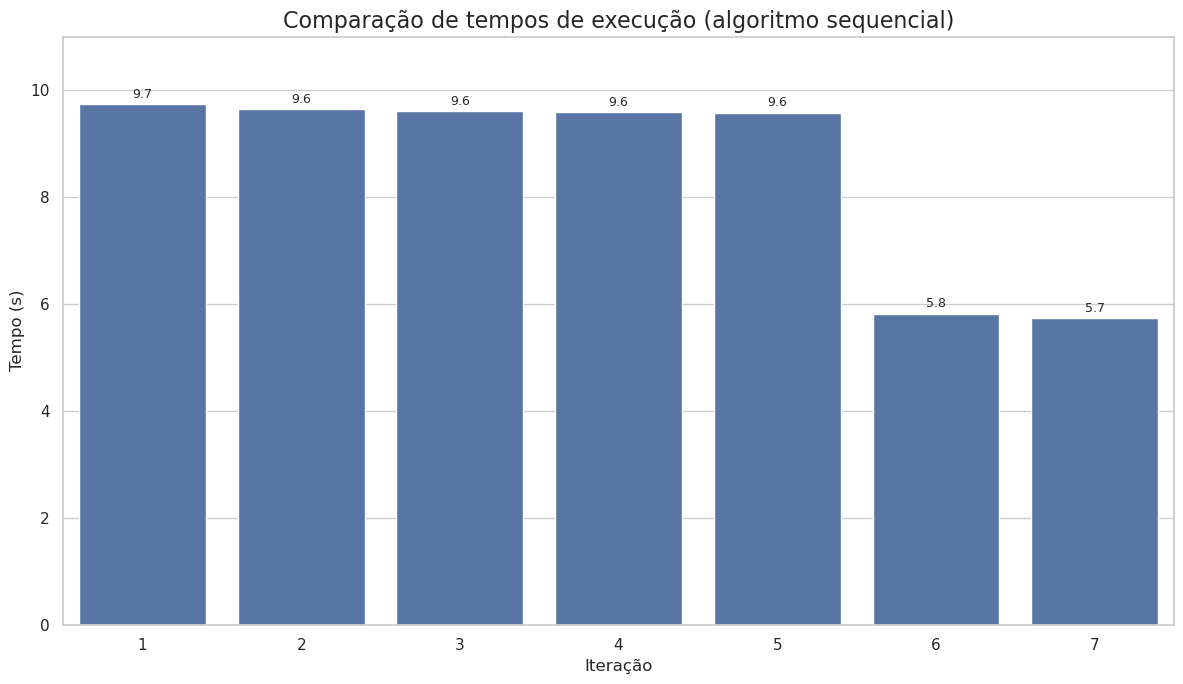

In [14]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=sequencial_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo sequencial)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.ylim(0, 11)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Static

Nesse subcapítulo serão visualizados os dados da implementação paralela com `schedule` **static**.

No caso abaixo, os valores `0` na coluna `valor_modo` significa que nenhum parâmetro extra foi utilizado em conjunto com `#pragma omp for schedule(static)`.

In [15]:
static_df: pd.DataFrame = results_df.query("nome_modo == 'static' and valor_modo == 0")
static_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
7,1,11.402553,0.5,static,0,0.014493,0.853846,0.213462
8,2,9.502563,0.5,static,0,0.014493,1.014877,0.253719
9,3,9.499928,0.5,static,0,0.014493,1.010948,0.252737
10,4,11.049248,0.5,static,0,0.014493,0.867671,0.216918
11,5,9.529516,0.5,static,0,0.014493,1.004922,0.251230
12,6,9.514660,0.5,static,0,0.014493,0.611696,0.152924
13,7,9.539857,0.5,static,0,0.014493,0.601009,0.150252


##### Tempo de execução

In [16]:
print("TEMPO")
print("Média:", static_df["tempo"].mean())
print("Desvio padrão:", static_df["tempo"].std())
print("Valor mínimo:", static_df["tempo"].min())
print("Valor máximo:", static_df["tempo"].max())

TEMPO
Média: 10.005476
Desvio padrão: 0.84004176
Valor mínimo: 9.499928
Valor máximo: 11.402553


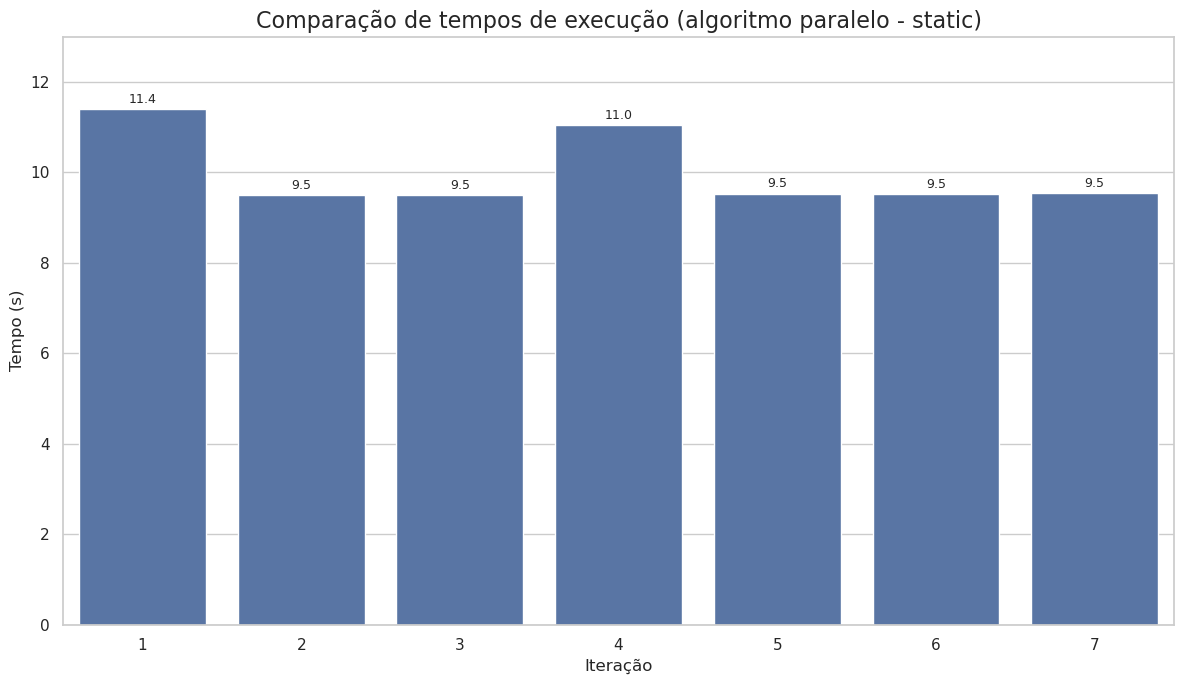

In [17]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - static)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.ylim(0, 13)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [18]:
print("Fab")
print("Média:", static_df["Fab"].mean())
print("Desvio padrão:", static_df["Fab"].std())
print("Valor mínimo:", static_df["Fab"].min())
print("Valor máximo:", static_df["Fab"].max())

Fab
Média: 0.01449275
Desvio padrão: 0.0
Valor mínimo: 0.01449275
Valor máximo: 0.01449275


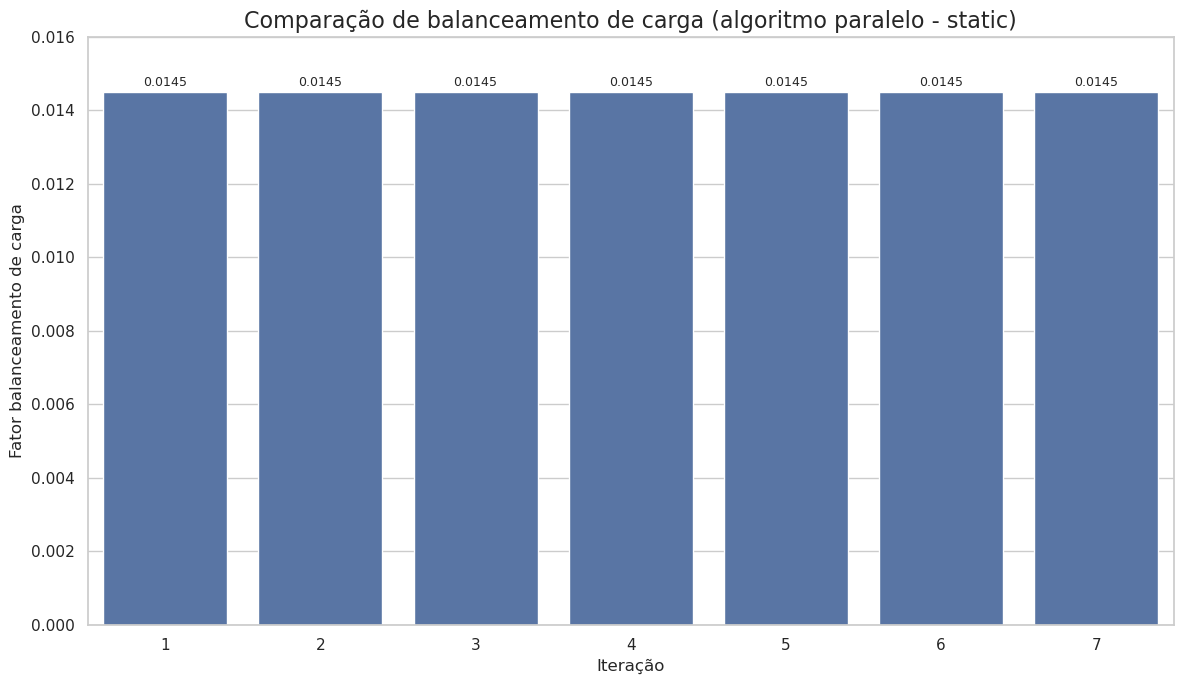

In [19]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - static)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.016)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [20]:
print("Speed-up")
print("Média:", static_df["speed_up"].mean())
print("Desvio padrão:", static_df["speed_up"].std())
print("Valor mínimo:", static_df["speed_up"].min())
print("Valor máximo:", static_df["speed_up"].max())

Speed-up
Média: 0.85213846
Desvio padrão: 0.18081768
Valor mínimo: 0.6010086
Valor máximo: 1.0148772


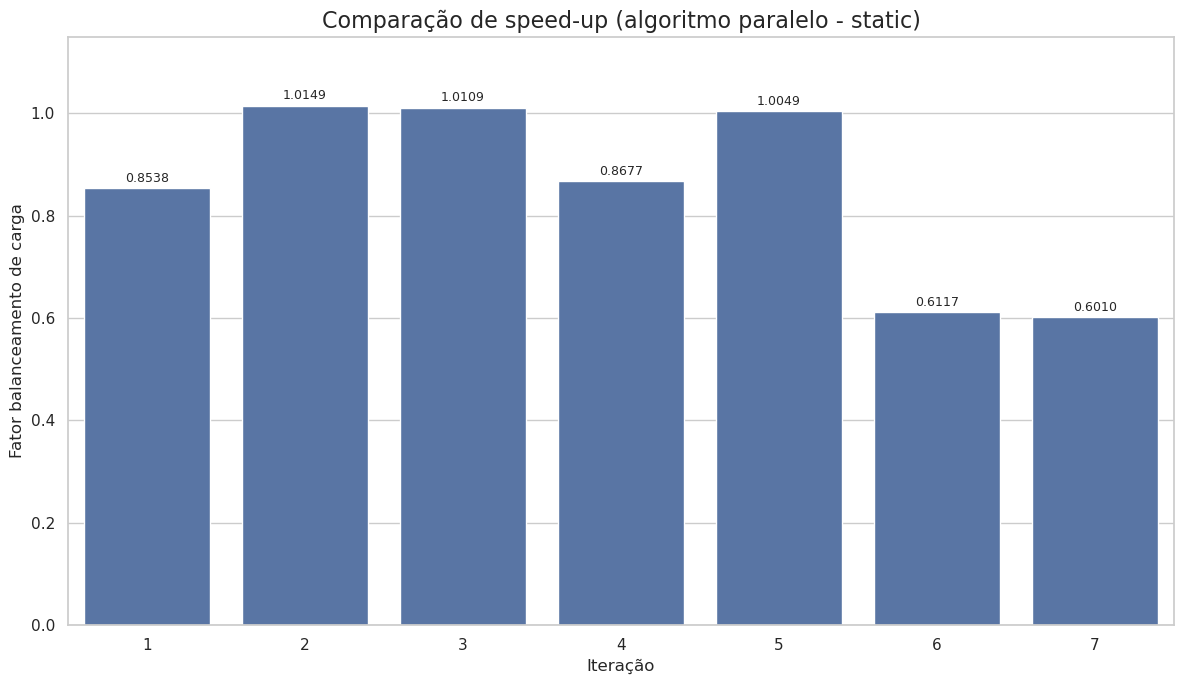

In [21]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - static)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.15)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [22]:
print("Eficiência")
print("Média:", static_df["eficiencia"].mean())
print("Desvio padrão:", static_df["eficiencia"].std())
print("Valor mínimo:", static_df["eficiencia"].min())
print("Valor máximo:", static_df["eficiencia"].max())

Eficiência
Média: 0.21303461
Desvio padrão: 0.04520442
Valor mínimo: 0.15025215
Valor máximo: 0.2537193


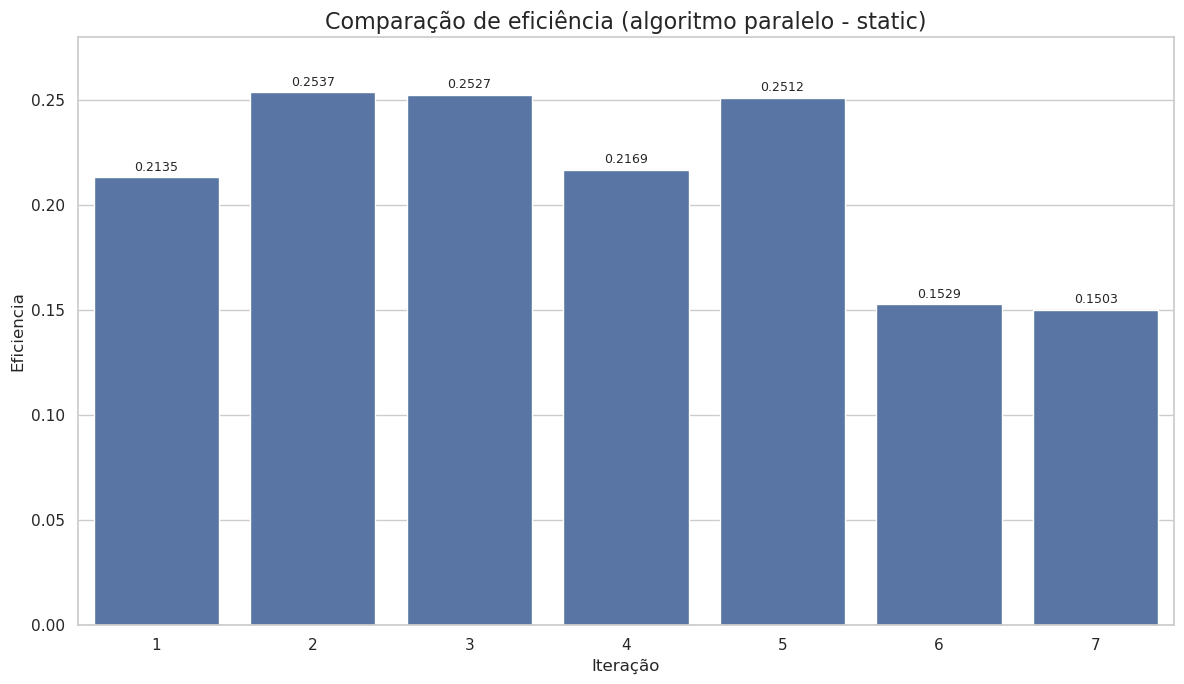

In [23]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - static)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.28)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Static, 1

In [24]:
static_df: pd.DataFrame = results_df.query("nome_modo == 'static' and valor_modo == 1")
static_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
14,1,9.588651,0.5,static,1,0.014493,1.015370,0.253843
15,2,9.406636,0.5,static,1,0.014493,1.025227,0.256307
16,3,10.894795,0.5,static,1,0.014493,0.881516,0.220379
17,4,9.402572,0.5,static,1,0.014493,1.019627,0.254907
18,5,9.542489,0.5,static,1,0.014493,1.003555,0.250889
19,6,9.461038,0.5,static,1,0.014493,0.615163,0.153791
20,7,10.023134,0.5,static,1,0.014493,0.572030,0.143008


##### Tempo de execução

In [25]:
print("TEMPO")
print("Média:", static_df["tempo"].mean())
print("Desvio padrão:", static_df["tempo"].std())
print("Valor mínimo:", static_df["tempo"].min())
print("Valor máximo:", static_df["tempo"].max())

TEMPO
Média: 9.759902
Desvio padrão: 0.54400843
Valor mínimo: 9.402572
Valor máximo: 10.894795


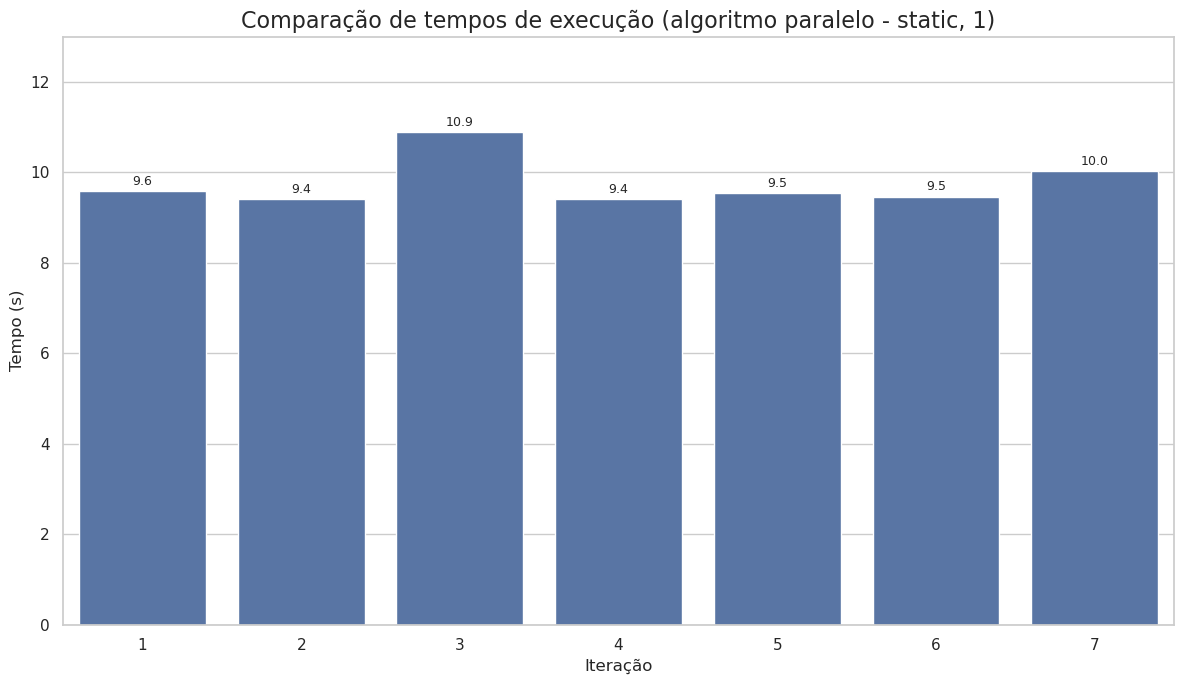

In [26]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - static, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.ylim(0, 13)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [27]:
print("Fab")
print("Média:", static_df["Fab"].mean())
print("Desvio padrão:", static_df["Fab"].std())
print("Valor mínimo:", static_df["Fab"].min())
print("Valor máximo:", static_df["Fab"].max())

Fab
Média: 0.01449275
Desvio padrão: 0.0
Valor mínimo: 0.01449275
Valor máximo: 0.01449275


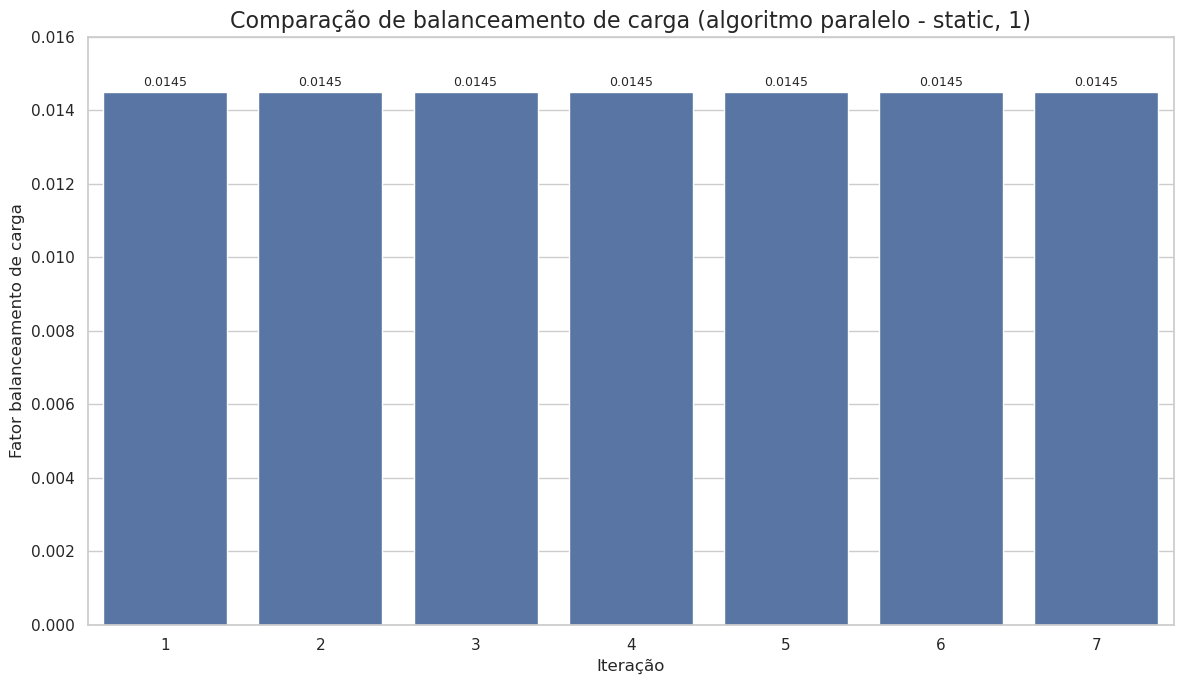

In [28]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - static, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.016)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [29]:
print("Speed-up")
print("Média:", static_df["speed_up"].mean())
print("Desvio padrão:", static_df["speed_up"].std())
print("Valor mínimo:", static_df["speed_up"].min())
print("Valor máximo:", static_df["speed_up"].max())

Speed-up
Média: 0.87606966
Desvio padrão: 0.19960614
Valor mínimo: 0.57203025
Valor máximo: 1.0252267


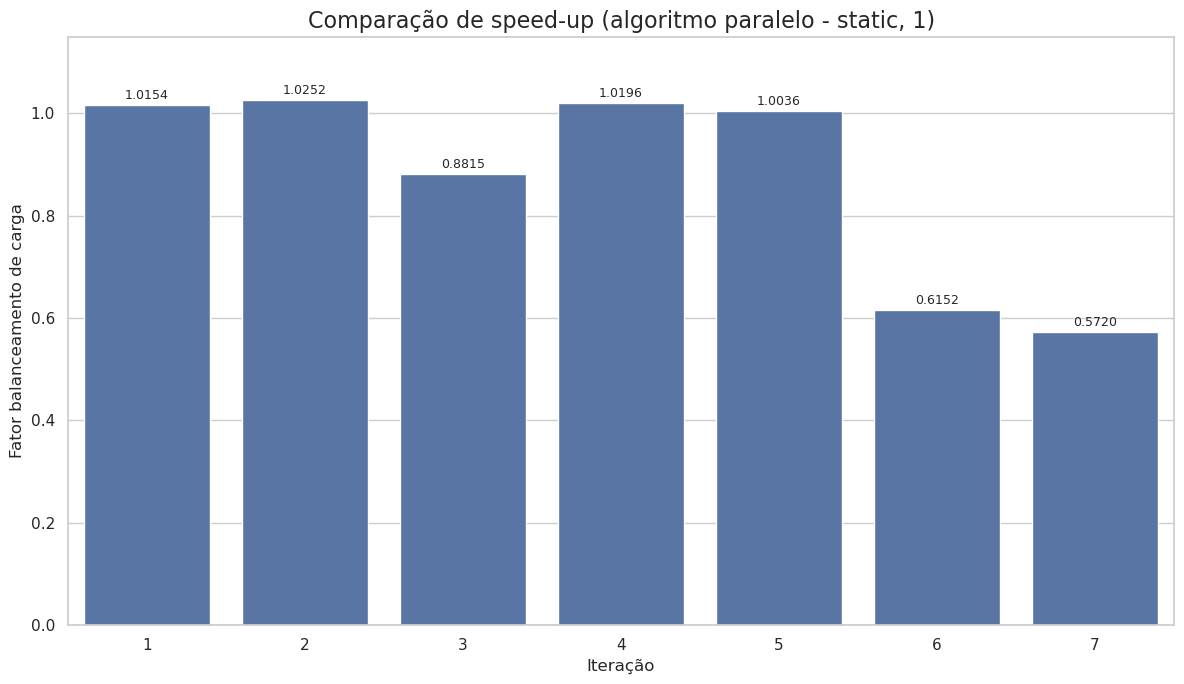

In [30]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - static, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.15)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [31]:
print("Eficiência")
print("Média:", static_df["eficiencia"].mean())
print("Desvio padrão:", static_df["eficiencia"].std())
print("Valor mínimo:", static_df["eficiencia"].min())
print("Valor máximo:", static_df["eficiencia"].max())

Eficiência
Média: 0.21901742
Desvio padrão: 0.049901534
Valor mínimo: 0.14300756
Valor máximo: 0.25630668


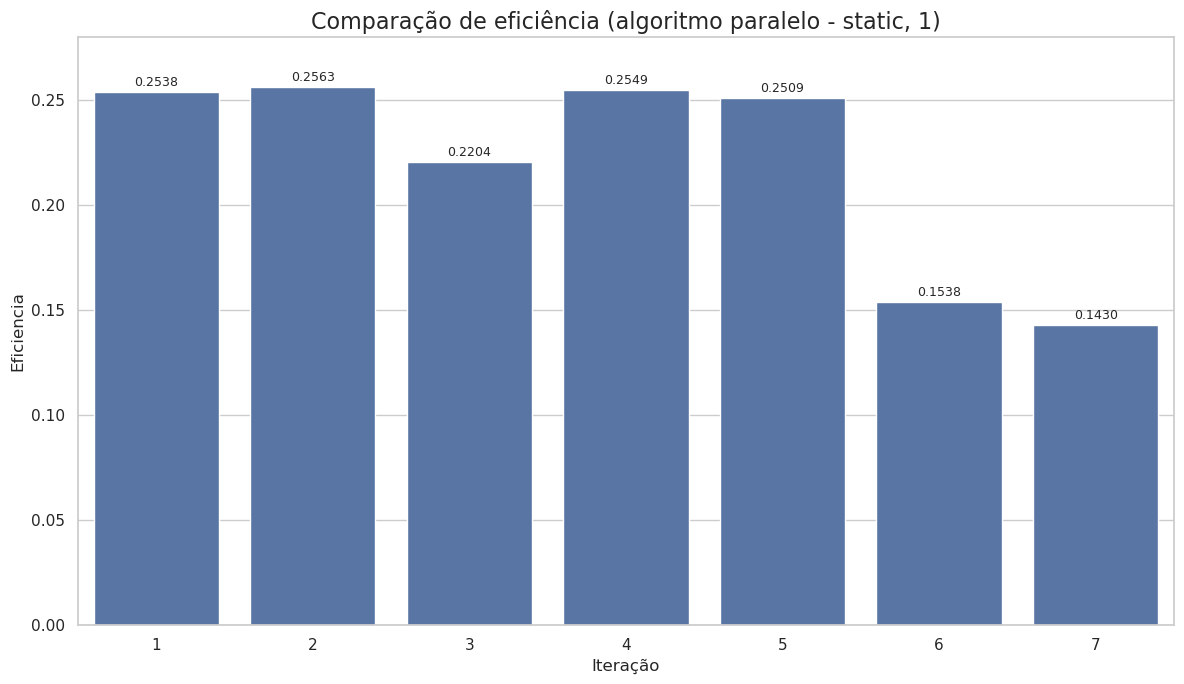

In [32]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - static, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.28)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Static, 2

In [33]:
static_df: pd.DataFrame = results_df.query("nome_modo == 'static' and valor_modo == 2")
static_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
21,1,5.575633,0.5,static,2,0.028571,1.746175,0.436544
22,2,5.594479,0.5,static,2,0.028571,1.723831,0.430958
23,3,5.543972,0.5,static,2,0.028571,1.732321,0.433080
24,4,5.559714,0.5,static,2,0.028571,1.724390,0.431097
25,5,6.524377,0.5,static,2,0.028571,1.467790,0.366948
26,6,5.578726,0.5,static,2,0.028571,1.043263,0.260816
27,7,5.564609,0.5,static,2,0.028571,1.030357,0.257589


##### Tempo de execução

In [34]:
print("TEMPO")
print("Média:", static_df["tempo"].mean())
print("Desvio padrão:", static_df["tempo"].std())
print("Valor mínimo:", static_df["tempo"].min())
print("Valor máximo:", static_df["tempo"].max())

TEMPO
Média: 5.7059298
Desvio padrão: 0.3612515
Valor mínimo: 5.543972
Valor máximo: 6.524377


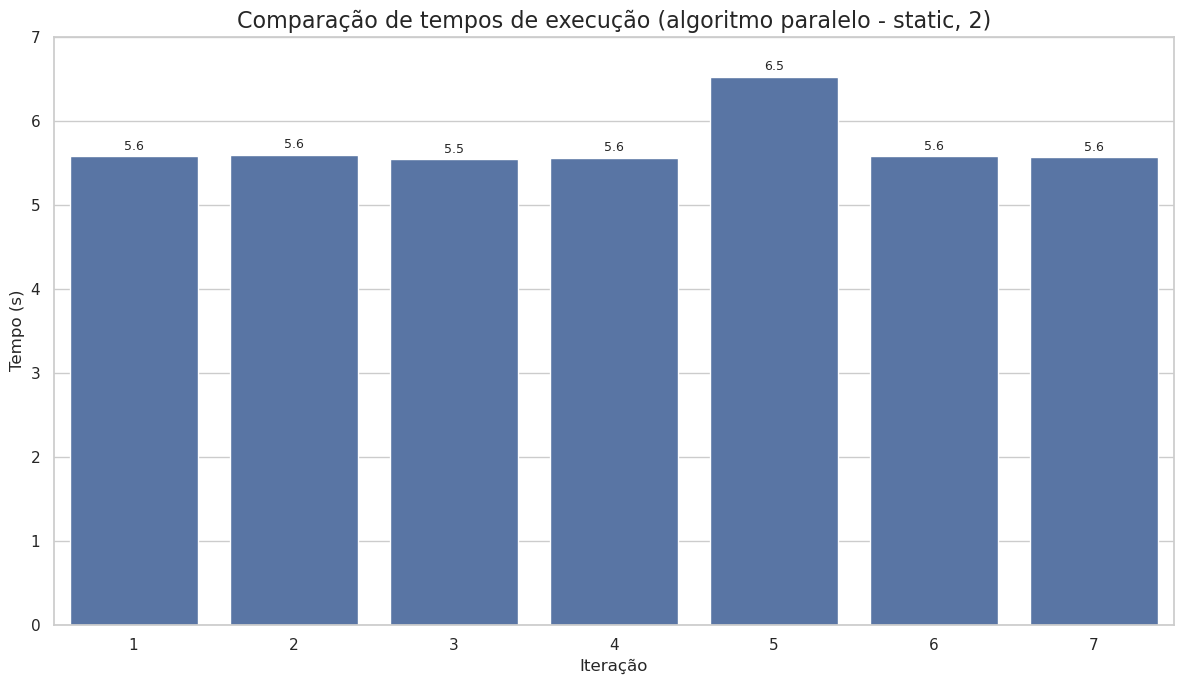

In [35]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - static, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.ylim(0.0, 7.0)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [36]:
print("Fab")
print("Média:", static_df["Fab"].mean())
print("Desvio padrão:", static_df["Fab"].std())
print("Valor mínimo:", static_df["Fab"].min())
print("Valor máximo:", static_df["Fab"].max())

Fab
Média: 0.028571430000000002
Desvio padrão: 3.7474310104154816e-18
Valor mínimo: 0.02857143
Valor máximo: 0.02857143


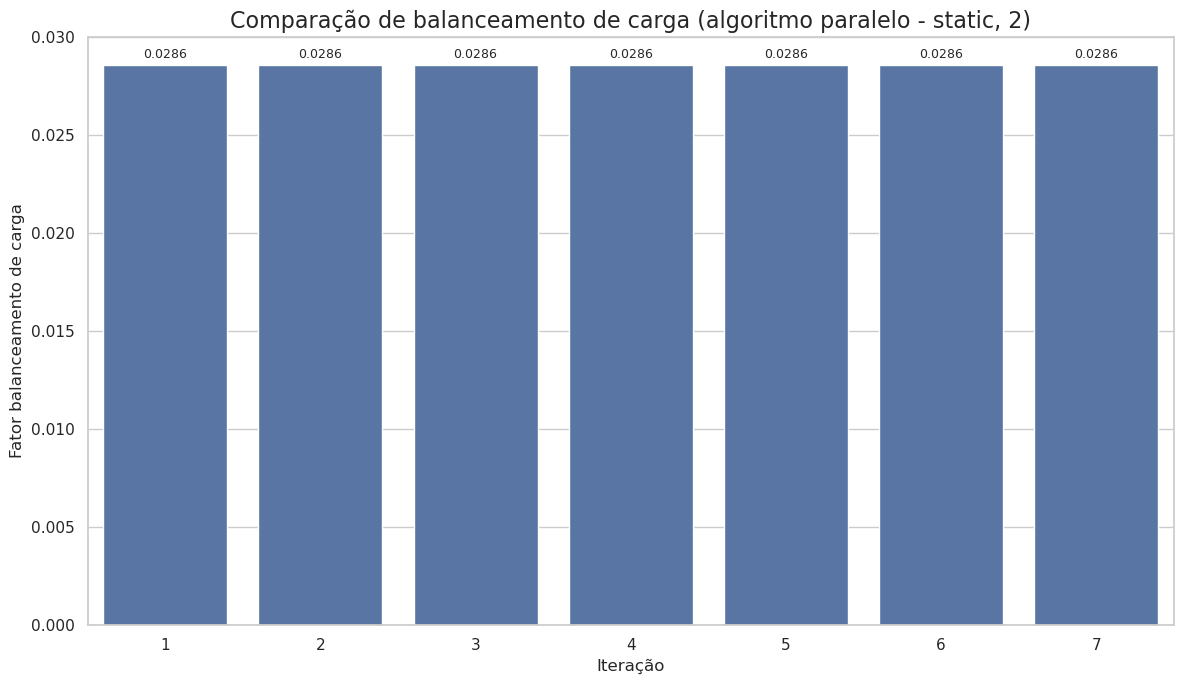

In [37]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - static, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.03)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [38]:
print("Speed-up")
print("Média:", static_df["speed_up"].mean())
print("Desvio padrão:", static_df["speed_up"].std())
print("Valor mínimo:", static_df["speed_up"].min())
print("Valor máximo:", static_df["speed_up"].max())

Speed-up
Média: 1.4954468
Desvio padrão: 0.32789505
Valor mínimo: 1.0303574
Valor máximo: 1.7461747


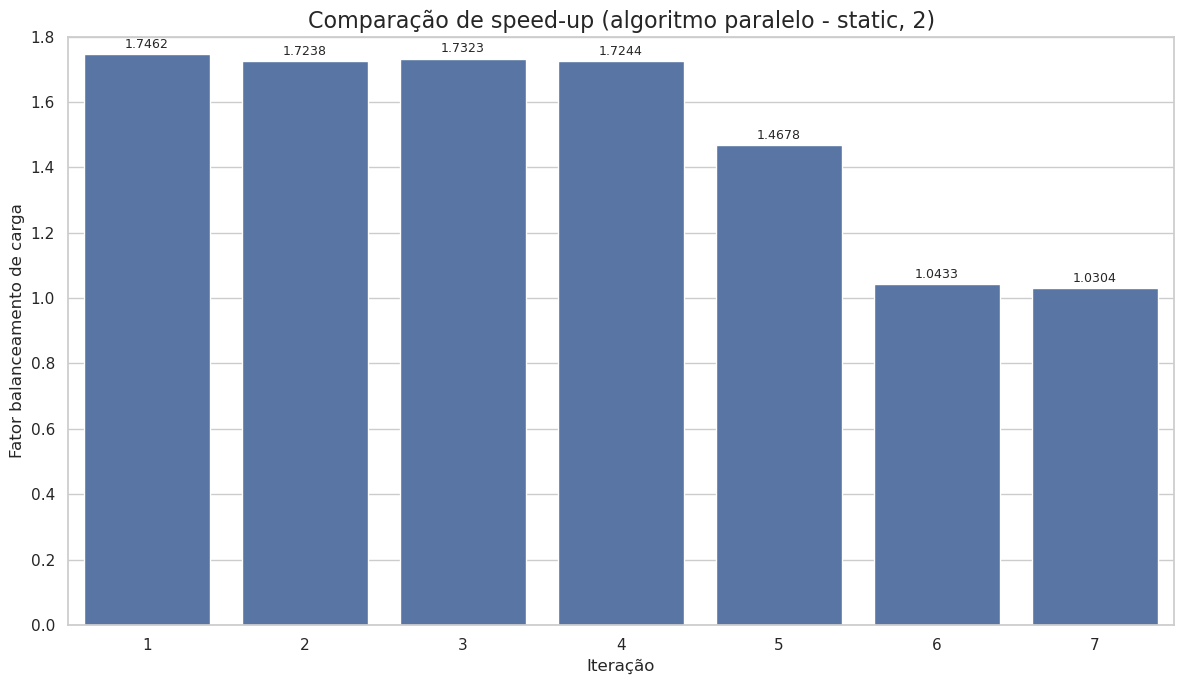

In [39]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - static, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.8)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [40]:
print("Eficiência")
print("Média:", static_df["eficiencia"].mean())
print("Desvio padrão:", static_df["eficiencia"].std())
print("Valor mínimo:", static_df["eficiencia"].min())
print("Valor máximo:", static_df["eficiencia"].max())

Eficiência
Média: 0.3738617
Desvio padrão: 0.08197376
Valor mínimo: 0.25758934
Valor máximo: 0.43654367


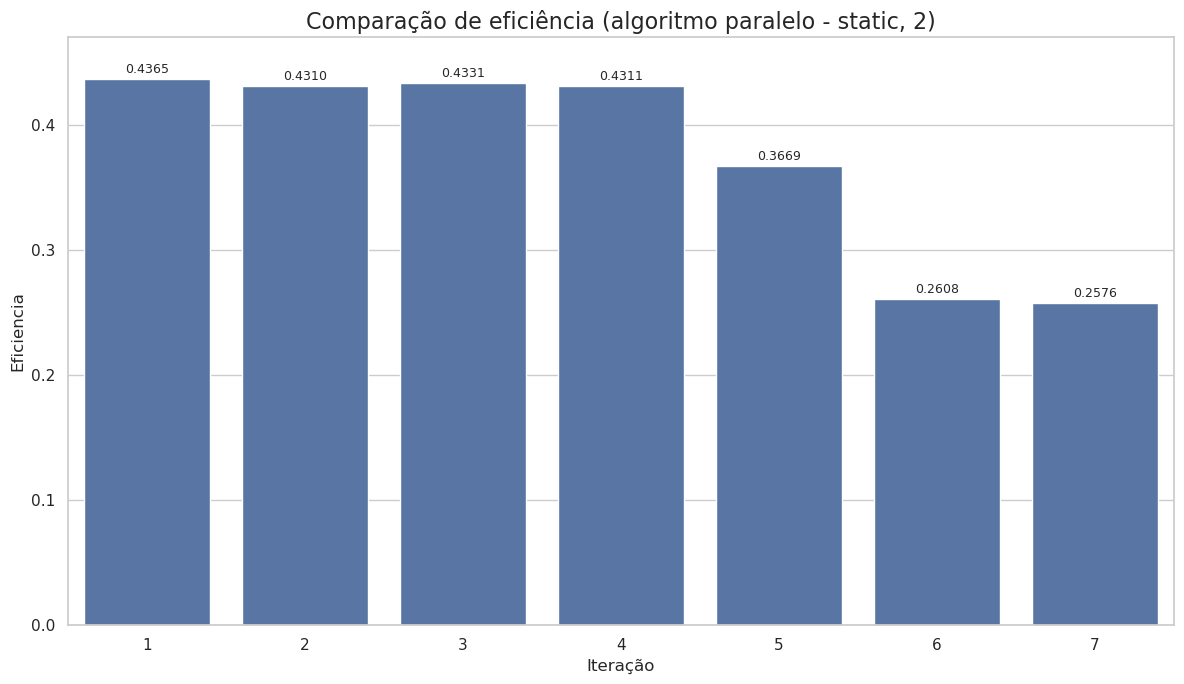

In [41]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - static, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.47)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Static, 4

In [42]:
static_df: pd.DataFrame = results_df.query("nome_modo == 'static' and valor_modo == 4")
static_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
28,1,9.357284,0.5,static,4,0.042254,1.040476,0.260119
29,2,9.478352,0.5,static,4,0.042254,1.017470,0.254367
30,3,9.431457,0.5,static,4,0.042254,1.018288,0.254572
31,4,9.374154,0.5,static,4,0.042254,1.022718,0.255679
32,5,9.431161,0.5,static,4,0.042254,1.015402,0.253850
33,6,5.567645,0.5,static,4,0.042254,1.045339,0.261335
34,7,5.603625,0.5,static,4,0.042254,1.023183,0.255796


##### Tempo de execução

In [43]:
print("TEMPO")
print("Média:", static_df["tempo"].mean())
print("Desvio padrão:", static_df["tempo"].std())
print("Valor mínimo:", static_df["tempo"].min())
print("Valor máximo:", static_df["tempo"].max())

TEMPO
Média: 8.320525
Desvio padrão: 1.8687402
Valor mínimo: 5.567645
Valor máximo: 9.478352


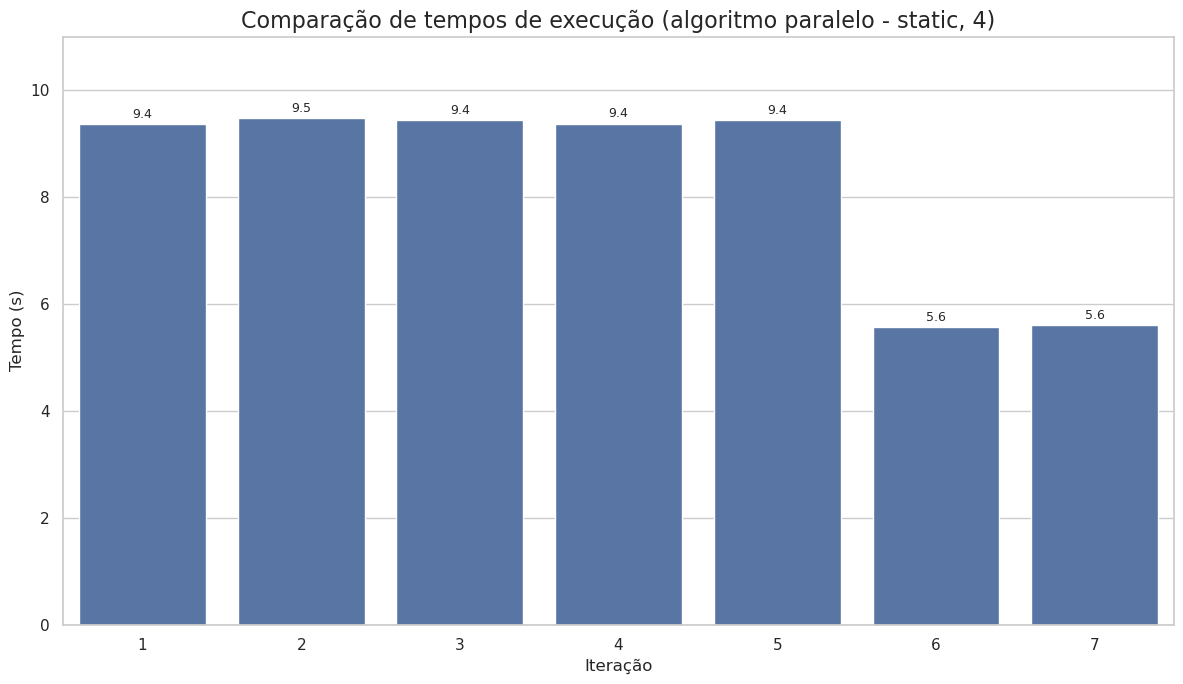

In [44]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - static, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.ylim(0, 11)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [45]:
print("Fab")
print("Média:", static_df["Fab"].mean())
print("Desvio padrão:", static_df["Fab"].std())
print("Valor mínimo:", static_df["Fab"].min())
print("Valor máximo:", static_df["Fab"].max())

Fab
Média: 0.042253519999999996
Desvio padrão: 7.494862020830963e-18
Valor mínimo: 0.04225352
Valor máximo: 0.04225352


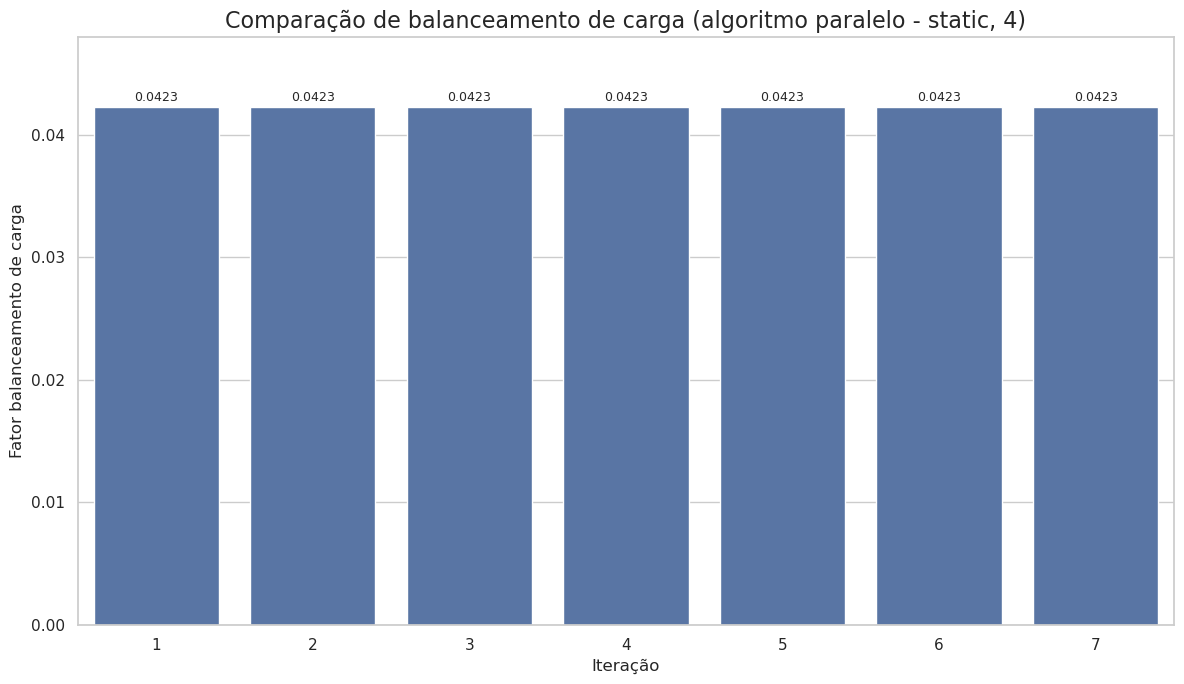

In [46]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - static, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.048)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [47]:
print("Speed-up")
print("Média:", static_df["speed_up"].mean())
print("Desvio padrão:", static_df["speed_up"].std())
print("Valor mínimo:", static_df["speed_up"].min())
print("Valor máximo:", static_df["speed_up"].max())

Speed-up
Média: 1.0261251
Desvio padrão: 0.011879527
Valor mínimo: 1.0154017
Valor máximo: 1.0453395


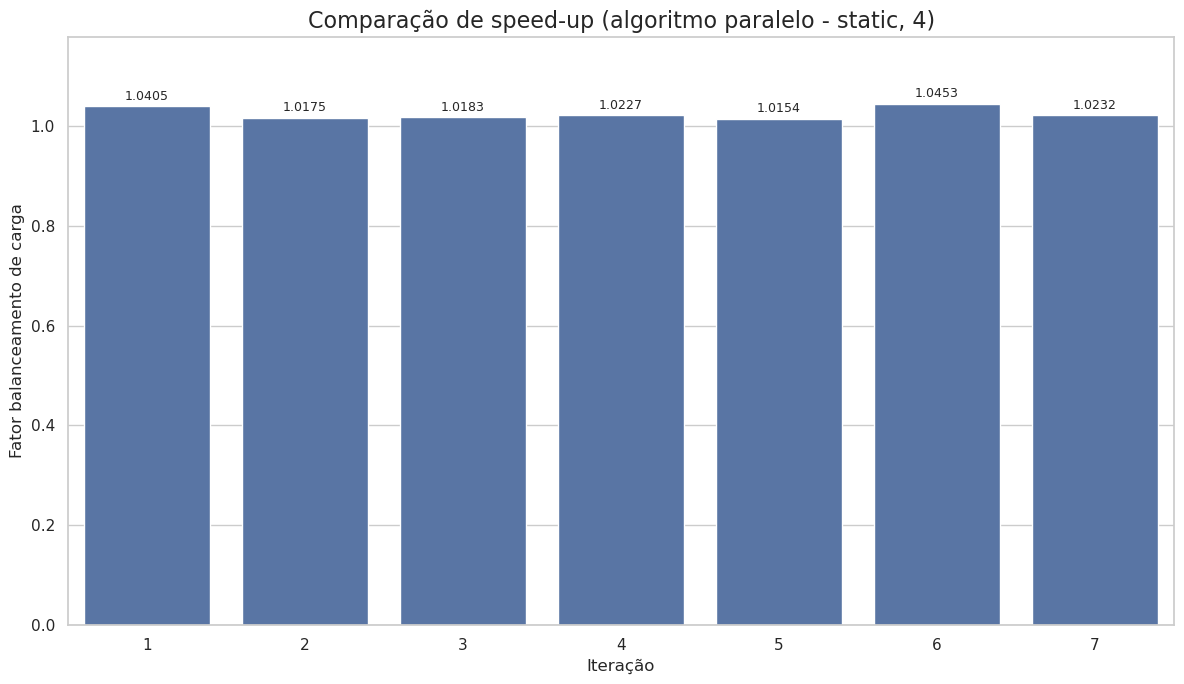

In [48]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - static, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.18)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [49]:
print("Eficiência")
print("Média:", static_df["eficiencia"].mean())
print("Desvio padrão:", static_df["eficiencia"].std())
print("Valor mínimo:", static_df["eficiencia"].min())
print("Valor máximo:", static_df["eficiencia"].max())

Eficiência
Média: 0.25653127
Desvio padrão: 0.0029698818
Valor mínimo: 0.25385043
Valor máximo: 0.26133487


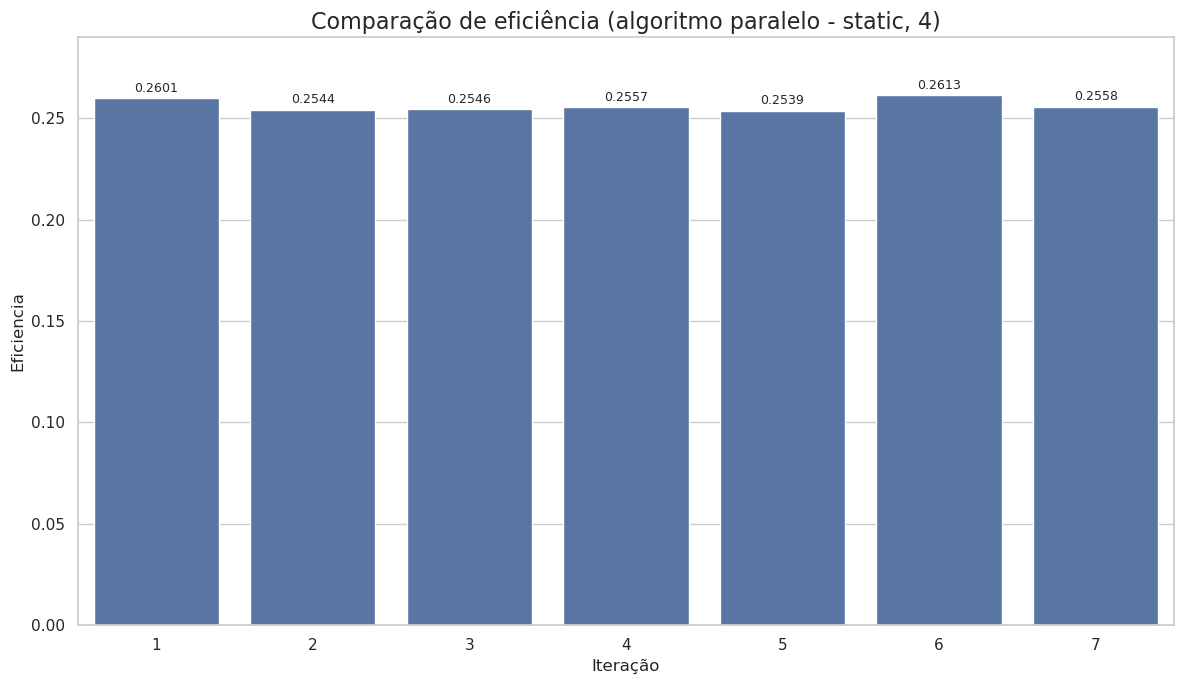

In [50]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - static, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.29)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Static, 8

In [51]:
static_df: pd.DataFrame = results_df.query("nome_modo == 'static' and valor_modo == 8")
static_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
35,1,5.616897,0.5,static,8,0.111111,1.733347,0.433337
36,2,5.608164,0.5,static,8,0.111111,1.719624,0.429906
37,3,5.613281,0.5,static,8,0.111111,1.710931,0.427733
38,4,6.166797,0.5,static,8,0.111111,1.554634,0.388658
39,5,5.585134,0.5,static,8,0.111111,1.714626,0.428657
40,6,5.579253,0.5,static,8,0.111111,1.043164,0.260791
41,7,5.709627,0.5,static,8,0.111111,1.004187,0.251047


##### Tempo de execução

In [52]:
print("TEMPO")
print("Média:", static_df["tempo"].mean())
print("Desvio padrão:", static_df["tempo"].std())
print("Valor mínimo:", static_df["tempo"].min())
print("Valor máximo:", static_df["tempo"].max())

TEMPO
Média: 5.6970224
Desvio padrão: 0.21156731
Valor mínimo: 5.579253
Valor máximo: 6.166797


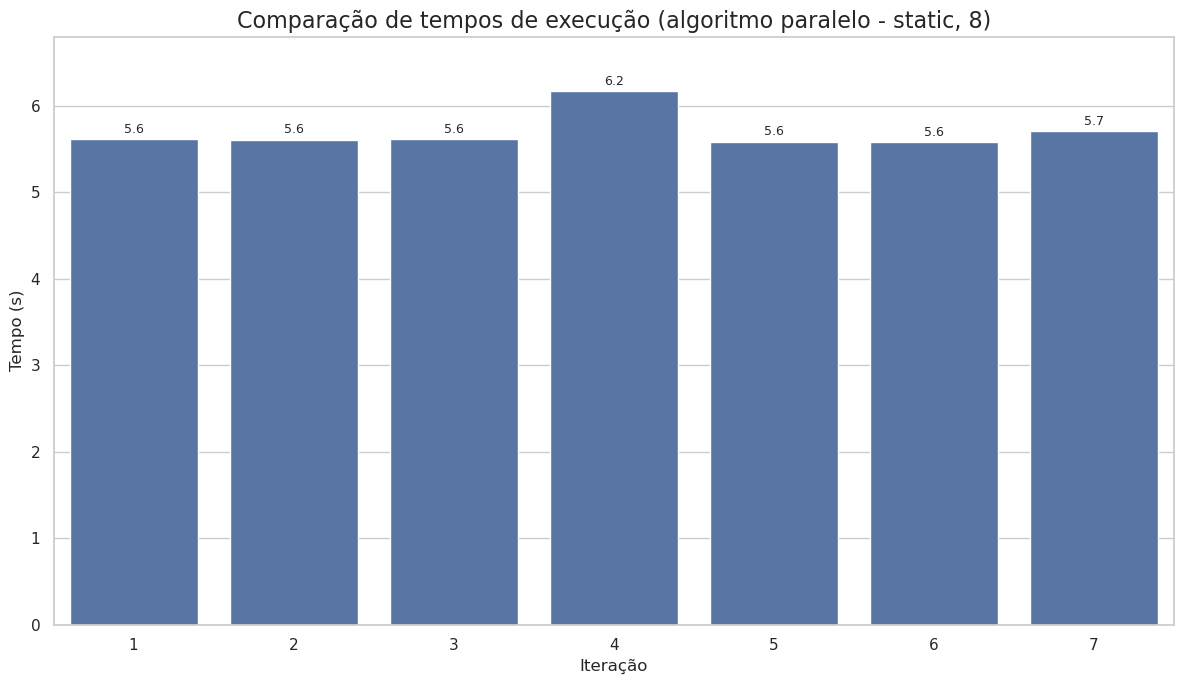

In [53]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - static, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.ylim(0.0, 6.8)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [54]:
print("Fab")
print("Média:", static_df["Fab"].mean())
print("Desvio padrão:", static_df["Fab"].std())
print("Valor mínimo:", static_df["Fab"].min())
print("Valor máximo:", static_df["Fab"].max())

Fab
Média: 0.11111110999999999
Desvio padrão: 1.4989724041661926e-17
Valor mínimo: 0.11111111
Valor máximo: 0.11111111


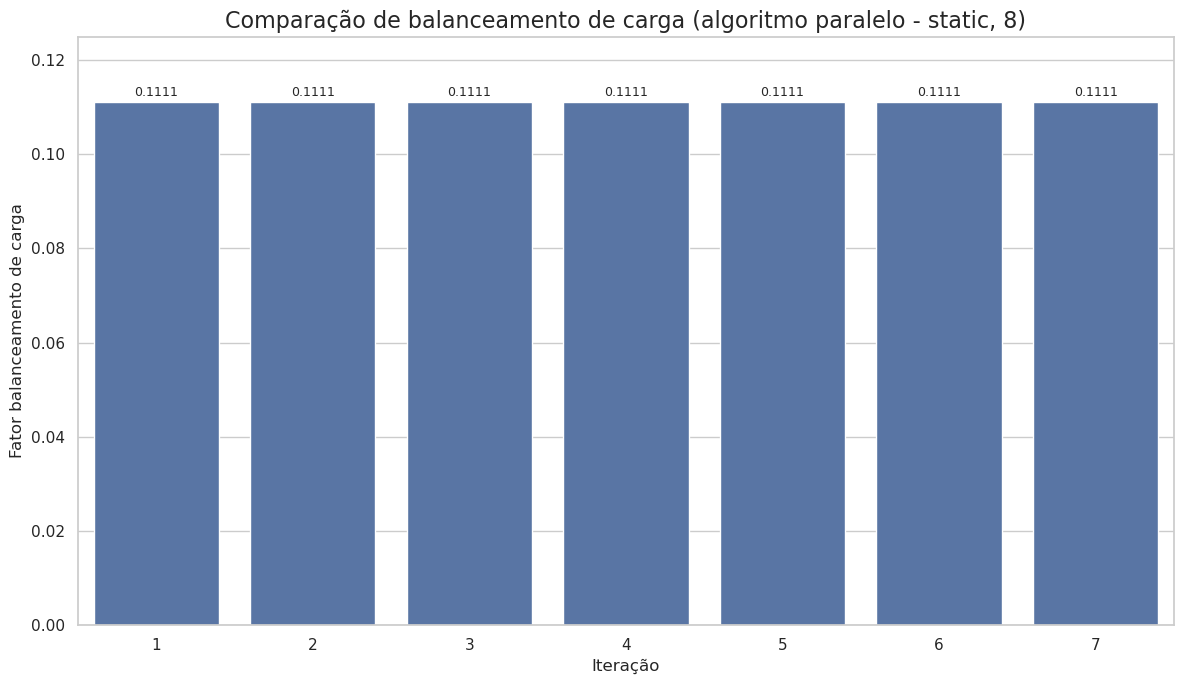

In [55]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - static, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.125)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [56]:
print("Speed-up")
print("Média:", static_df["speed_up"].mean())
print("Desvio padrão:", static_df["speed_up"].std())
print("Valor mínimo:", static_df["speed_up"].min())
print("Valor máximo:", static_df["speed_up"].max())

Speed-up
Média: 1.4972163
Desvio padrão: 0.32931778
Valor mínimo: 1.0041875
Valor máximo: 1.7333466


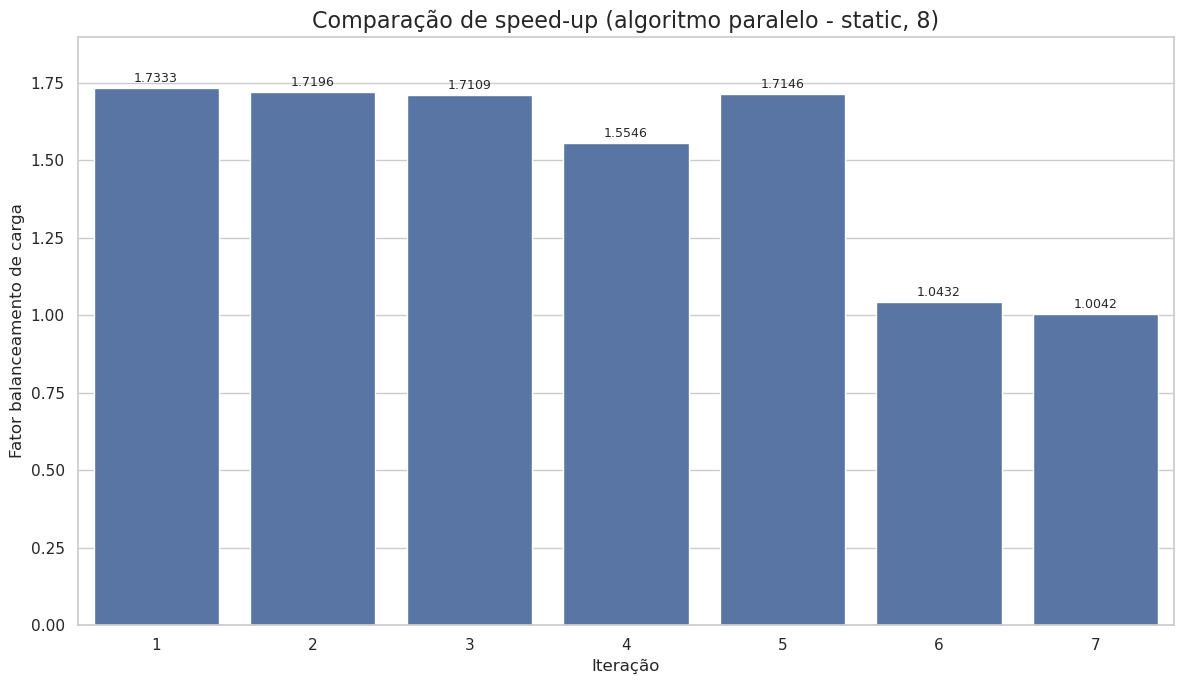

In [57]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - static, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.9)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [58]:
print("Eficiência")
print("Média:", static_df["eficiencia"].mean())
print("Desvio padrão:", static_df["eficiencia"].std())
print("Valor mínimo:", static_df["eficiencia"].min())
print("Valor máximo:", static_df["eficiencia"].max())

Eficiência
Média: 0.3743041
Desvio padrão: 0.082329445
Valor mínimo: 0.25104687
Valor máximo: 0.43333665


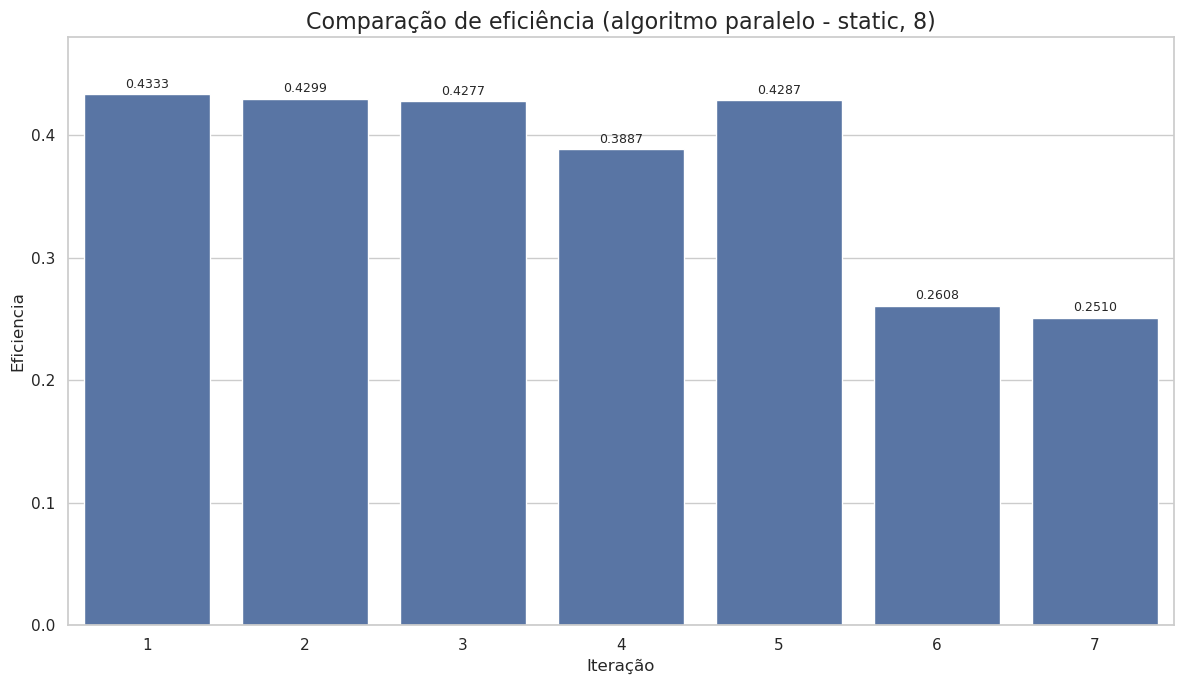

In [59]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - static, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.48)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Static, 16

In [60]:
static_df: pd.DataFrame = results_df.query("nome_modo == 'static' and valor_modo == 16")
static_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
42,1,5.621770,0.5,static,16,0.2,1.731844,0.432961
43,2,5.625606,0.5,static,16,0.2,1.714293,0.428573
44,3,6.502947,0.5,static,16,0.2,1.476859,0.369215
45,4,5.645408,0.5,static,16,0.2,1.698214,0.424554
46,5,5.624359,0.5,static,16,0.2,1.702668,0.425667
47,6,5.645139,0.5,static,16,0.2,1.030989,0.257747
48,7,6.461827,0.5,static,16,0.2,0.887293,0.221823


##### Tempo de execução

In [61]:
print("TEMPO")
print("Média:", static_df["tempo"].mean())
print("Desvio padrão:", static_df["tempo"].std())
print("Valor mínimo:", static_df["tempo"].min())
print("Valor máximo:", static_df["tempo"].max())

TEMPO
Média: 5.8752937
Desvio padrão: 0.4150049
Valor mínimo: 5.62177
Valor máximo: 6.502947


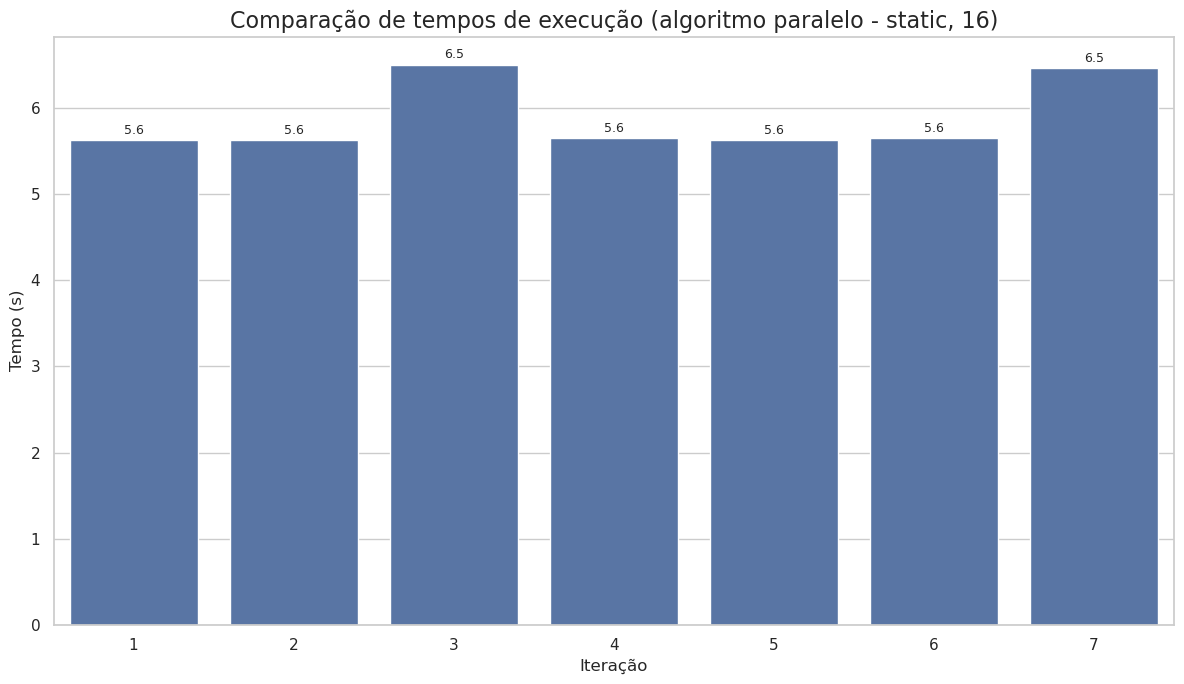

In [62]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - static, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [63]:
print("Fab")
print("Média:", static_df["Fab"].mean())
print("Desvio padrão:", static_df["Fab"].std())
print("Valor mínimo:", static_df["Fab"].min())
print("Valor máximo:", static_df["Fab"].max())

Fab
Média: 0.19999999999999998
Desvio padrão: 2.997944808332385e-17
Valor mínimo: 0.2
Valor máximo: 0.2


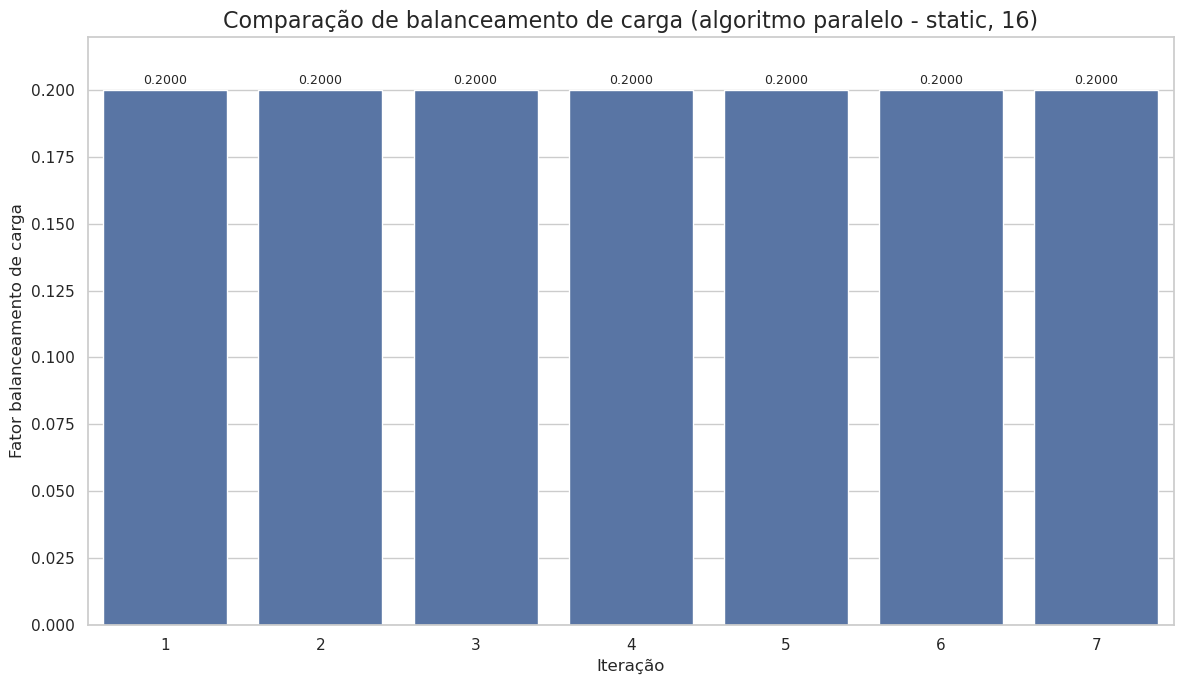

In [64]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - static, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.22)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [65]:
print("Speed-up")
print("Média:", static_df["speed_up"].mean())
print("Desvio padrão:", static_df["speed_up"].std())
print("Valor mínimo:", static_df["speed_up"].min())
print("Valor máximo:", static_df["speed_up"].max())

Speed-up
Média: 1.4631659
Desvio padrão: 0.35741082
Valor mínimo: 0.88729334
Valor máximo: 1.7318442


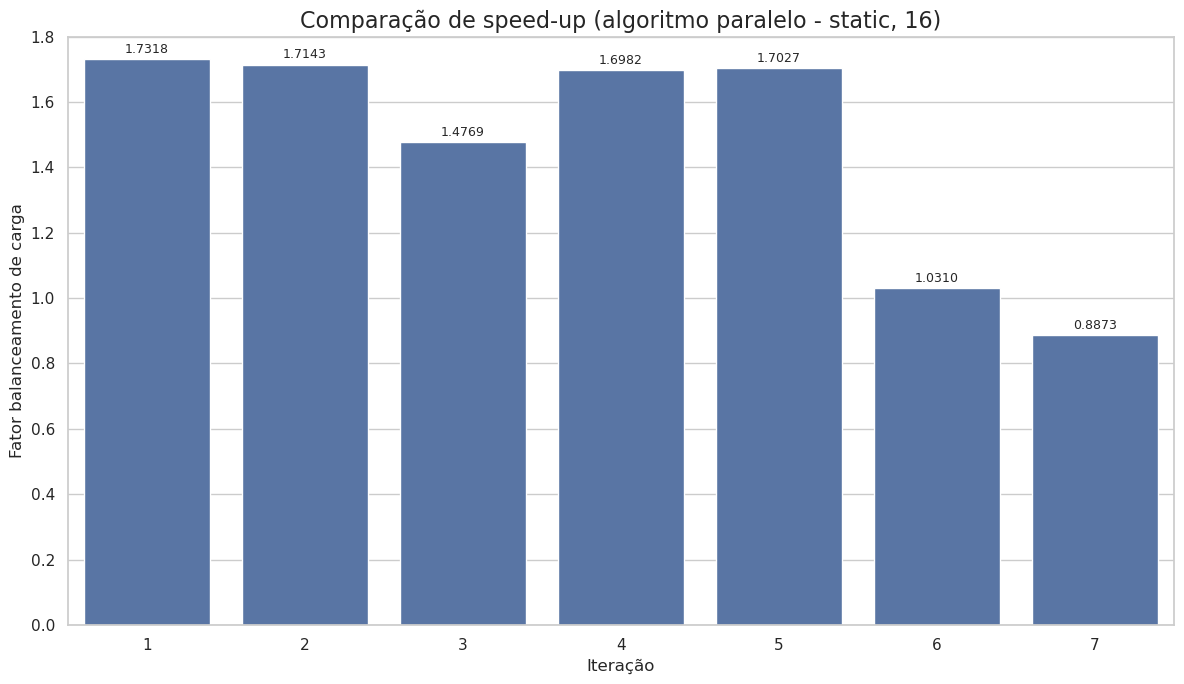

In [66]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - static, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.8)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [67]:
print("Eficiência")
print("Média:", static_df["eficiencia"].mean())
print("Desvio padrão:", static_df["eficiencia"].std())
print("Valor mínimo:", static_df["eficiencia"].min())
print("Valor máximo:", static_df["eficiencia"].max())

Eficiência
Média: 0.36579147
Desvio padrão: 0.089352705
Valor mínimo: 0.22182333
Valor máximo: 0.43296105


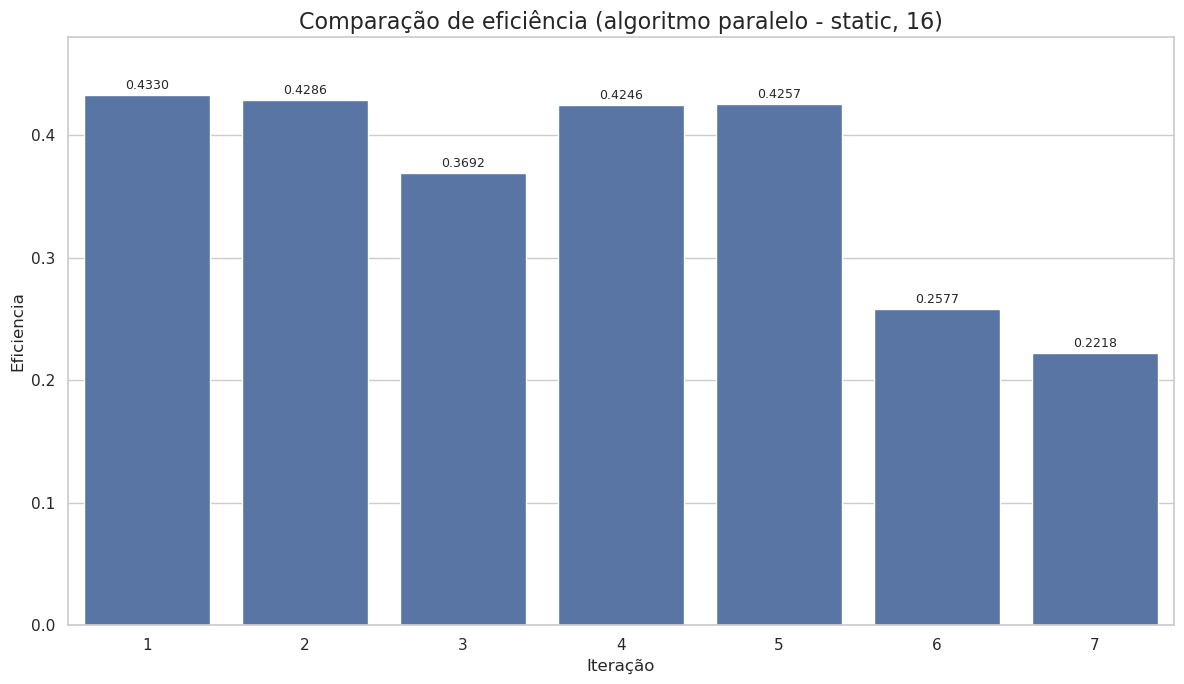

In [68]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=static_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - static, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.48)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Static, todos juntos

In [69]:
static_df: pd.DataFrame = results_df[results_df["nome_modo"] == "static"]
static_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
7,1,11.402553,0.5,static,0,0.014493,0.853846,0.213462
8,2,9.502563,0.5,static,0,0.014493,1.014877,0.253719
9,3,9.499928,0.5,static,0,0.014493,1.010948,0.252737
10,4,11.049248,0.5,static,0,0.014493,0.867671,0.216918
11,5,9.529516,0.5,static,0,0.014493,1.004922,0.251230
12,6,9.514660,0.5,static,0,0.014493,0.611696,0.152924
13,7,9.539857,0.5,static,0,0.014493,0.601009,0.150252
14,1,9.588651,0.5,static,1,0.014493,1.015370,0.253843
15,2,9.406636,0.5,static,1,0.014493,1.025227,0.256307
16,3,10.894795,0.5,static,1,0.014493,0.881516,0.220379


##### Tempo de execução

In [70]:
print("TEMPO")
print("Média:", static_df["tempo"].mean())
print("Desvio padrão:", static_df["tempo"].std())
print("Valor mínimo:", static_df["tempo"].min())
print("Valor máximo:", static_df["tempo"].max())

TEMPO
Média: 7.5606914
Desvio padrão: 2.0781176
Valor mínimo: 5.543972
Valor máximo: 11.402553


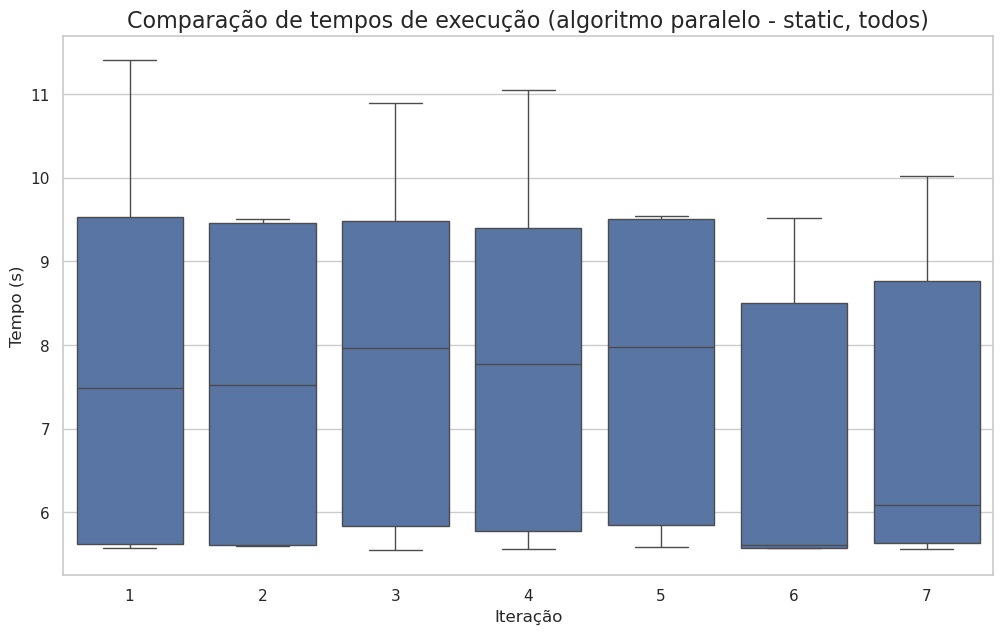

In [71]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=static_df, x="interacao", y="tempo")

plt.title("Comparação de tempos de execução (algoritmo paralelo - static, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.show()

##### Fator de balanceamento de carga (Fab)

In [72]:
print("Fab")
print("Média:", static_df["Fab"].mean())
print("Desvio padrão:", static_df["Fab"].std())
print("Valor mínimo:", static_df["Fab"].min())
print("Valor máximo:", static_df["Fab"].max())

Fab
Média: 0.06848692666666667
Desvio padrão: 0.06817710640141082
Valor mínimo: 0.01449275
Valor máximo: 0.2


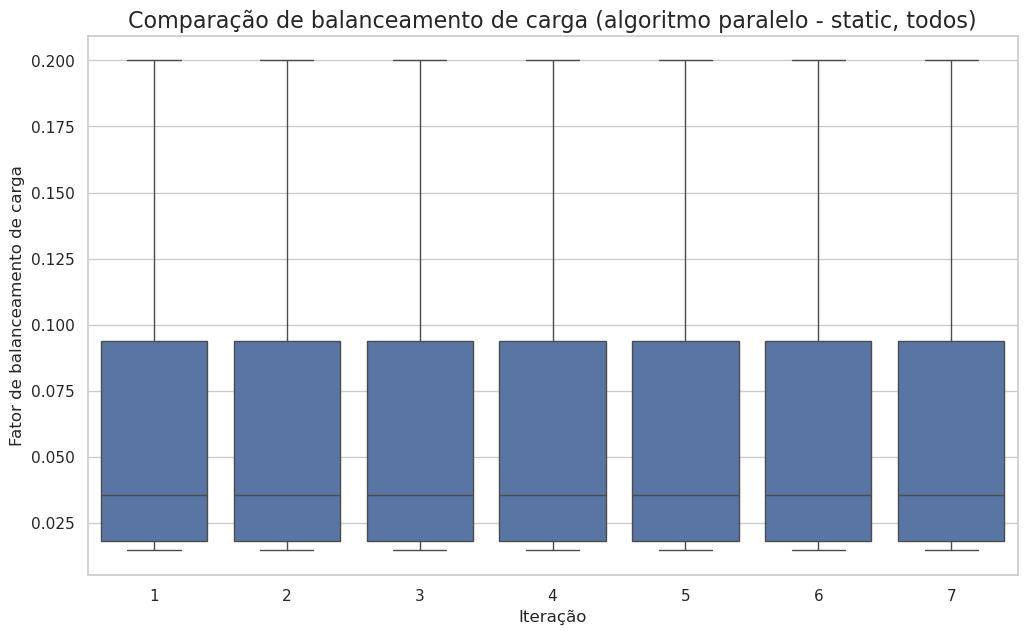

In [73]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=static_df, x="interacao", y="Fab")

plt.title("Comparação de balanceamento de carga (algoritmo paralelo - static, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de balanceamento de carga", fontsize=12)
plt.show()

##### *Speed-up*

In [74]:
print("Speed-up")
print("Média:", static_df["speed_up"].mean())
print("Desvio padrão:", static_df["speed_up"].std())
print("Valor mínimo:", static_df["speed_up"].min())
print("Valor máximo:", static_df["speed_up"].max())

Speed-up
Média: 1.2016938
Desvio padrão: 0.38272366
Valor mínimo: 0.57203025
Valor máximo: 1.7461747


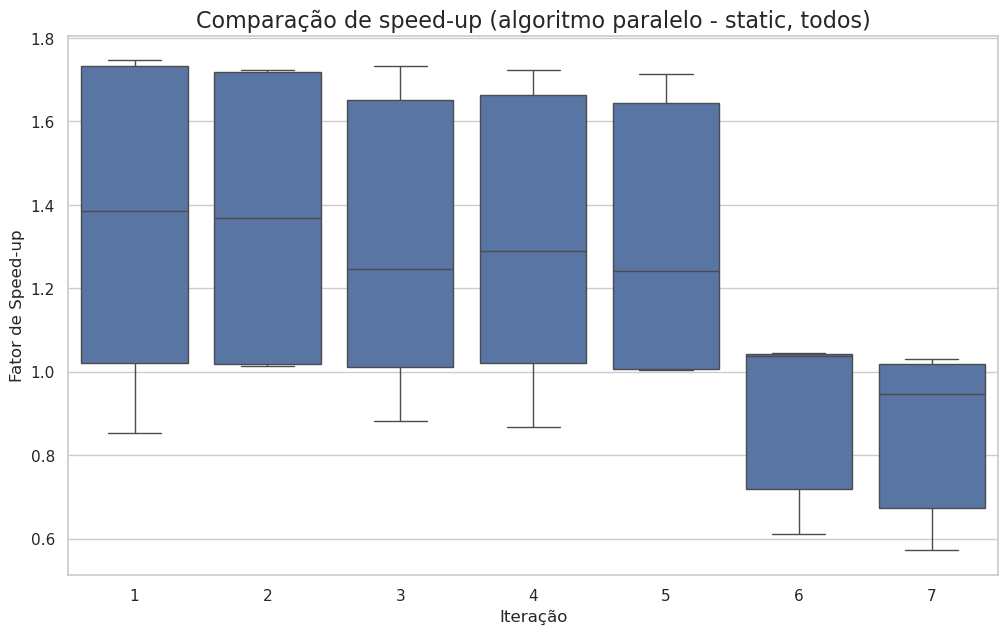

In [75]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=static_df, x="interacao", y="speed_up")

plt.title("Comparação de speed-up (algoritmo paralelo - static, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de Speed-up", fontsize=12)
plt.show()

##### Eficiência

In [76]:
print("Eficiência")
print("Média:", static_df["eficiencia"].mean())
print("Desvio padrão:", static_df["eficiencia"].std())
print("Valor mínimo:", static_df["eficiencia"].min())
print("Valor máximo:", static_df["eficiencia"].max())

Eficiência
Média: 0.30042344
Desvio padrão: 0.095680915
Valor mínimo: 0.14300756
Valor máximo: 0.43654367


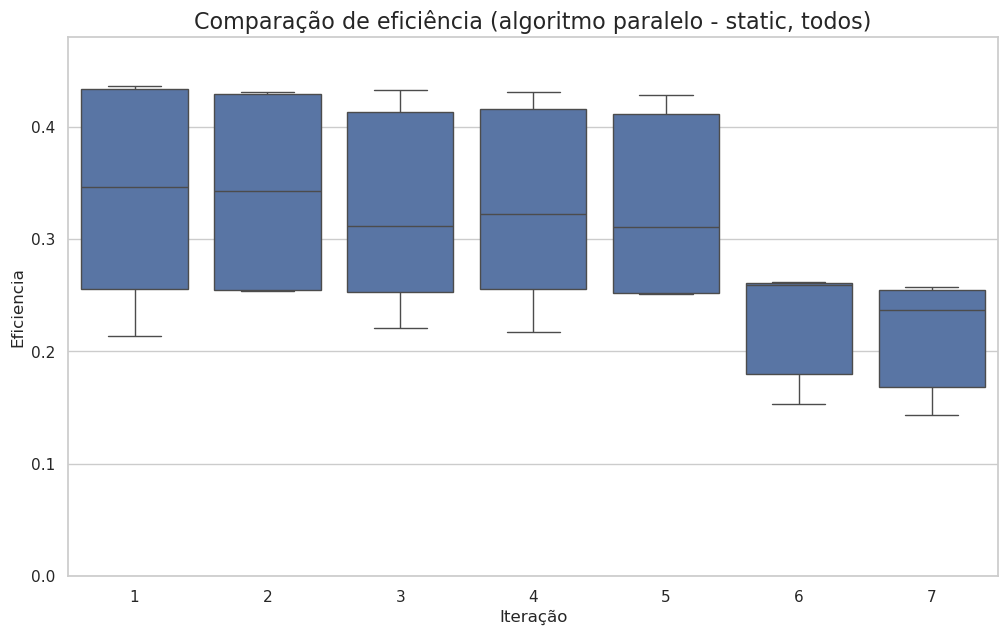

In [77]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=static_df, x="interacao", y="eficiencia")

plt.title("Comparação de eficiência (algoritmo paralelo - static, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.48)
plt.show()

#### Dynamic

Nesse subcapítulo serão visualizados os dados da implementação paralela com `schedule` **dynamic**.

#### Dynamic, 1

In [78]:
dynamic_df: pd.DataFrame = results_df.query("nome_modo == 'dynamic' and valor_modo == 1")
dynamic_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
49,1,9.415752,0.5,dynamic,1,0.291139,1.034015,0.258504
50,2,9.431909,0.5,dynamic,1,0.494624,1.022480,0.255620
51,3,9.429630,0.5,dynamic,1,0.269737,1.018485,0.254621
52,4,9.442116,0.5,dynamic,1,0.414365,1.015356,0.253839
53,5,9.369778,0.5,dynamic,1,0.470930,1.022054,0.255513
54,6,9.449298,0.5,dynamic,1,0.416667,0.615927,0.153982
55,7,9.420634,0.5,dynamic,1,0.471910,0.608615,0.152154


##### Tempo de execução

In [79]:
print("TEMPO")
print("Média:", dynamic_df["tempo"].mean())
print("Desvio padrão:", dynamic_df["tempo"].std())
print("Valor mínimo:", dynamic_df["tempo"].min())
print("Valor máximo:", dynamic_df["tempo"].max())

TEMPO
Média: 9.42273
Desvio padrão: 0.026046593
Valor mínimo: 9.369778
Valor máximo: 9.449298


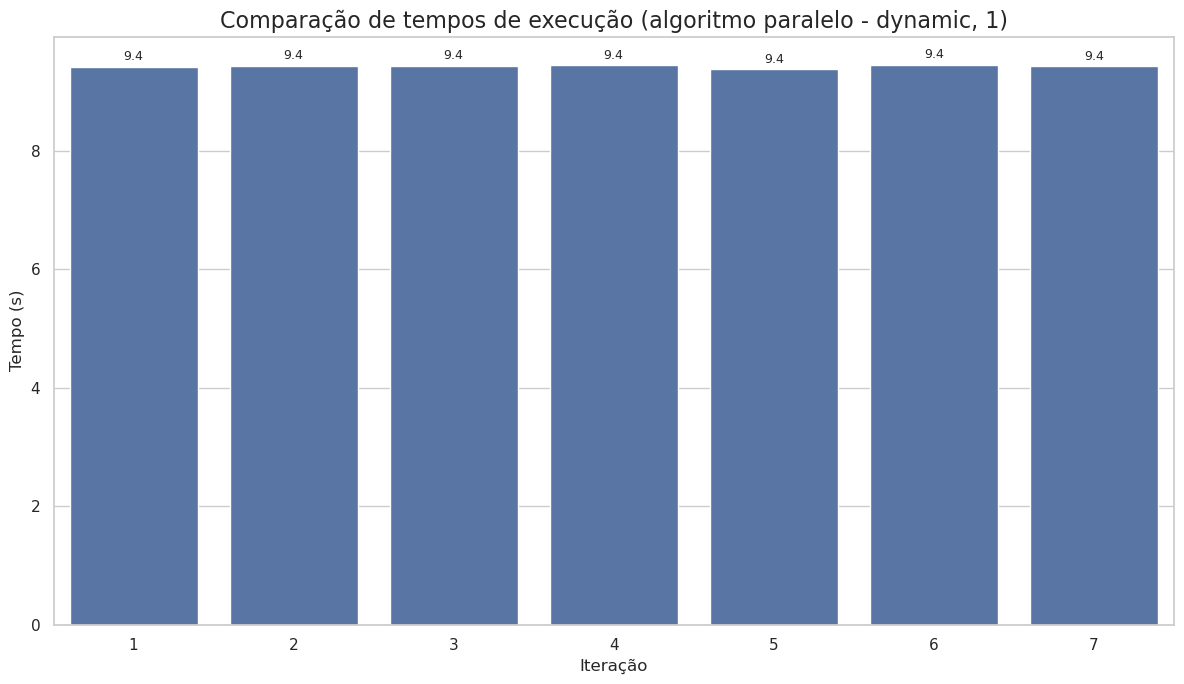

In [80]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - dynamic, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [81]:
print("Fab")
print("Média:", dynamic_df["Fab"].mean())
print("Desvio padrão:", dynamic_df["Fab"].std())
print("Valor mínimo:", dynamic_df["Fab"].min())
print("Valor máximo:", dynamic_df["Fab"].max())

Fab
Média: 0.4041959128571429
Desvio padrão: 0.08975506984669367
Valor mínimo: 0.26973684
Valor máximo: 0.49462366


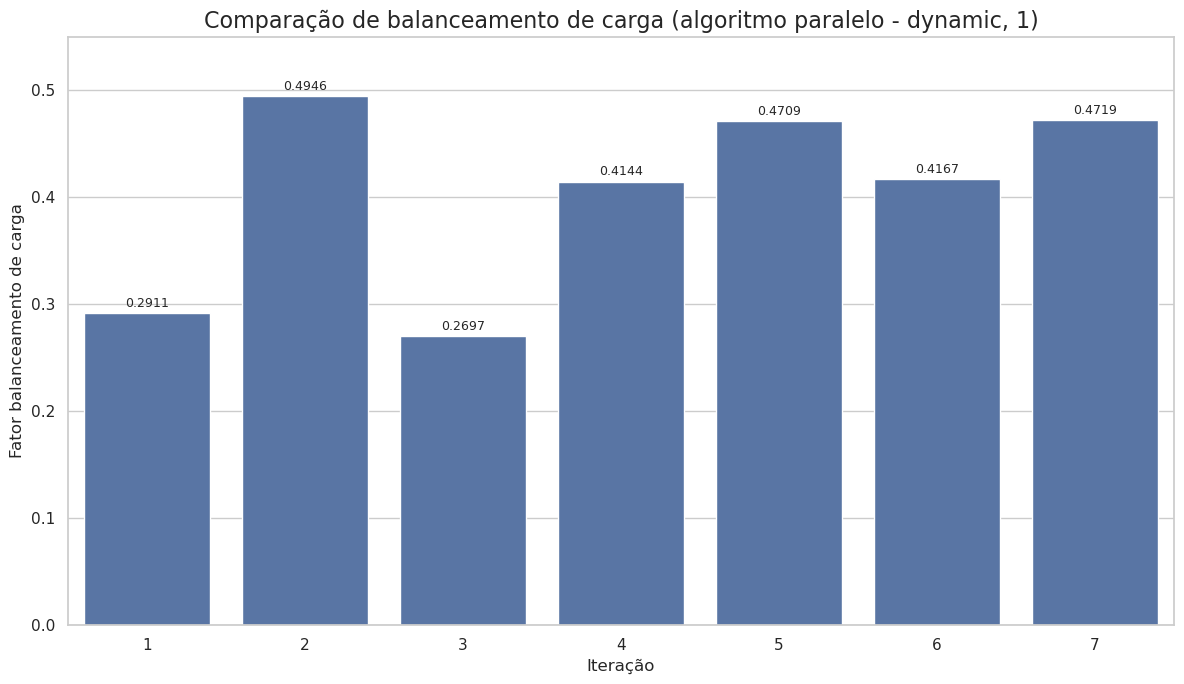

In [82]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - dynamic, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.55)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [83]:
print("Speed-up")
print("Média:", dynamic_df["speed_up"].mean())
print("Desvio padrão:", dynamic_df["speed_up"].std())
print("Valor mínimo:", dynamic_df["speed_up"].min())
print("Valor máximo:", dynamic_df["speed_up"].max())

Speed-up
Média: 0.90527594
Desvio padrão: 0.20025495
Valor mínimo: 0.6086146
Valor máximo: 1.034015


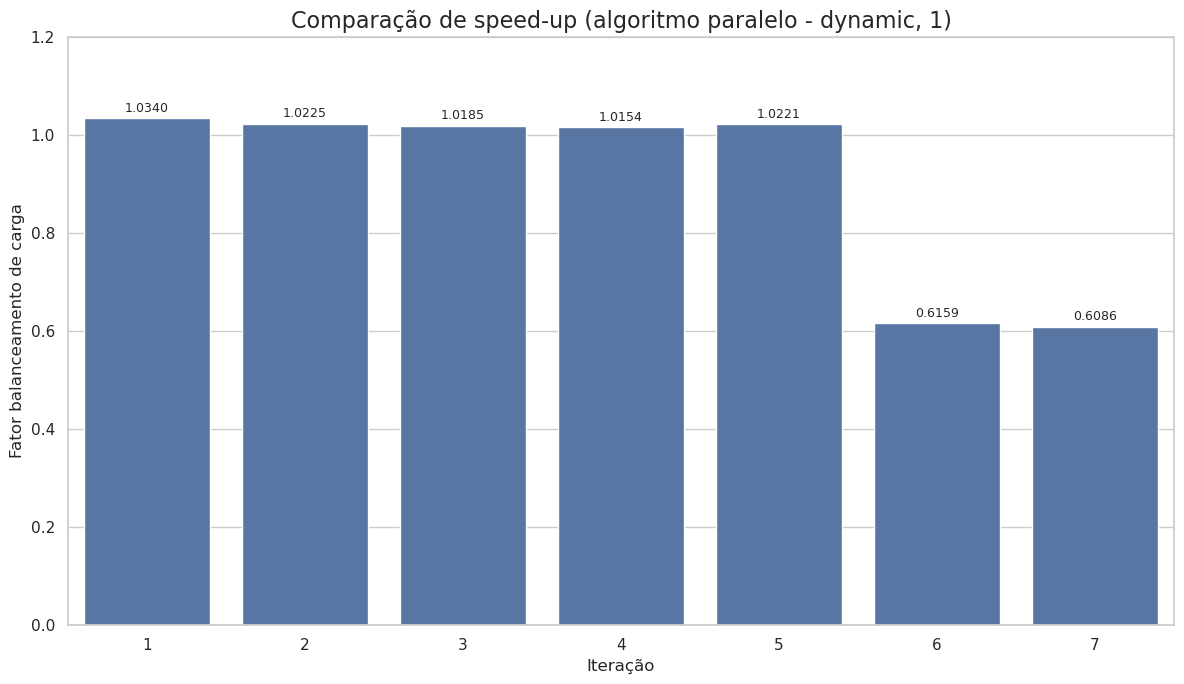

In [84]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - dynamic, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.2)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [85]:
print("Eficiência")
print("Média:", dynamic_df["eficiencia"].mean())
print("Desvio padrão:", dynamic_df["eficiencia"].std())
print("Valor mínimo:", dynamic_df["eficiencia"].min())
print("Valor máximo:", dynamic_df["eficiencia"].max())

Eficiência
Média: 0.22631899
Desvio padrão: 0.050063737
Valor mínimo: 0.15215366
Valor máximo: 0.25850376


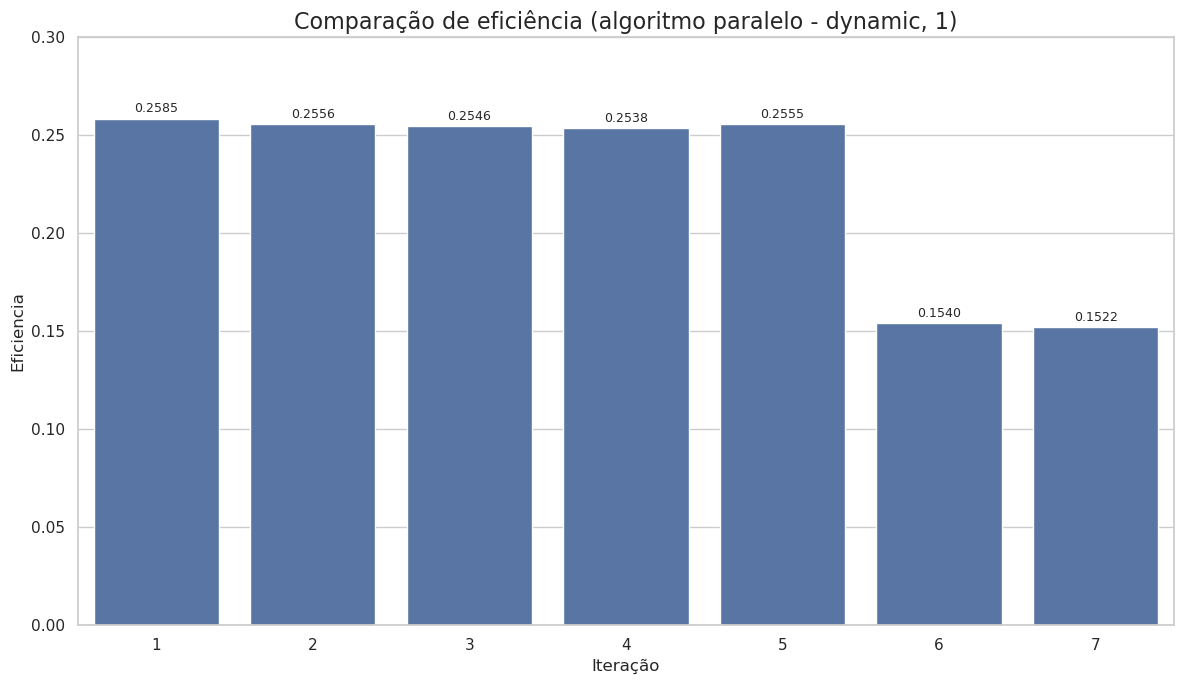

In [86]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - dynamic, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.3)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Dynamic, 2

In [87]:
dynamic_df: pd.DataFrame = results_df.query("nome_modo == 'dynamic' and valor_modo == 2")
dynamic_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
56,1,5.496648,0.5,dynamic,2,0.441860,1.771267,0.442817
57,2,5.505139,0.5,dynamic,2,0.516854,1.751806,0.437952
58,3,5.485201,0.5,dynamic,2,0.370370,1.750882,0.437720
59,4,5.510289,0.5,dynamic,2,0.495049,1.739856,0.434964
60,5,5.508034,0.5,dynamic,2,0.510417,1.738627,0.434657
61,6,5.511183,0.5,dynamic,2,0.106061,1.056049,0.264012
62,7,5.550842,0.5,dynamic,2,0.439024,1.032913,0.258228


##### Tempo de execução

In [88]:
print("TEMPO")
print("Média:", dynamic_df["tempo"].mean())
print("Desvio padrão:", dynamic_df["tempo"].std())
print("Valor mínimo:", dynamic_df["tempo"].min())
print("Valor máximo:", dynamic_df["tempo"].max())

TEMPO
Média: 5.5096197
Desvio padrão: 0.020368658
Valor mínimo: 5.485201
Valor máximo: 5.550842


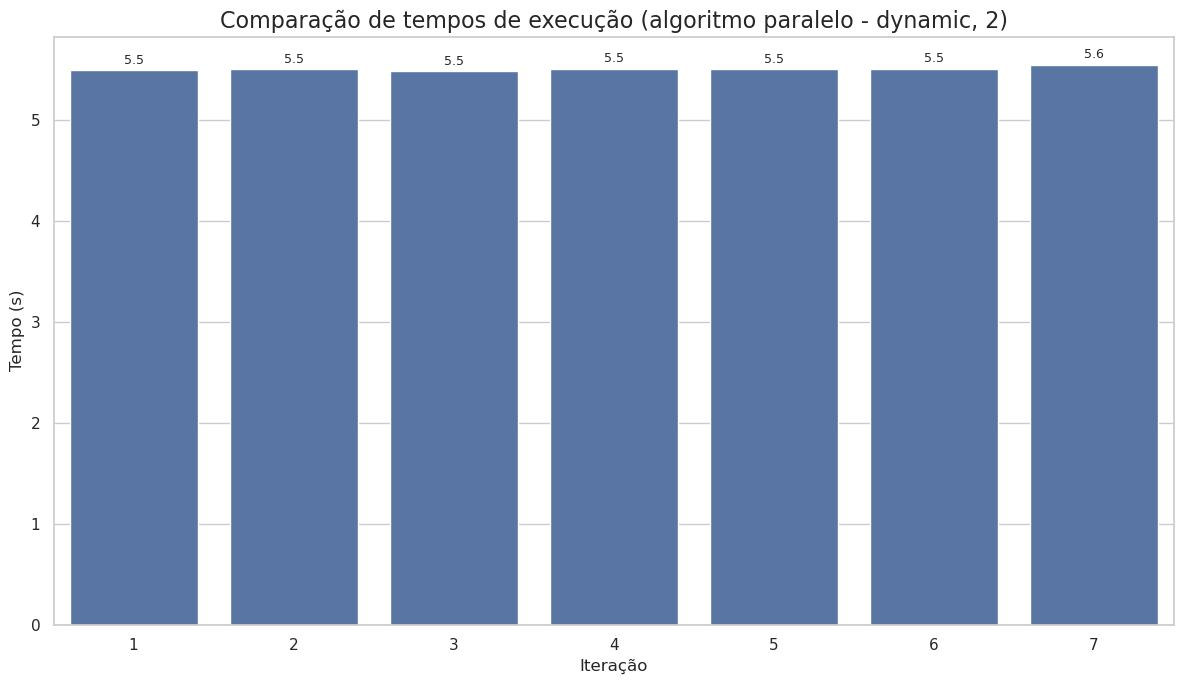

In [89]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - dynamic, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [90]:
print("Fab")
print("Média:", dynamic_df["Fab"].mean())
print("Desvio padrão:", dynamic_df["Fab"].std())
print("Valor mínimo:", dynamic_df["Fab"].min())
print("Valor máximo:", dynamic_df["Fab"].max())

Fab
Média: 0.4113765628571429
Desvio padrão: 0.14406514040211588
Valor mínimo: 0.10606061
Valor máximo: 0.51685393


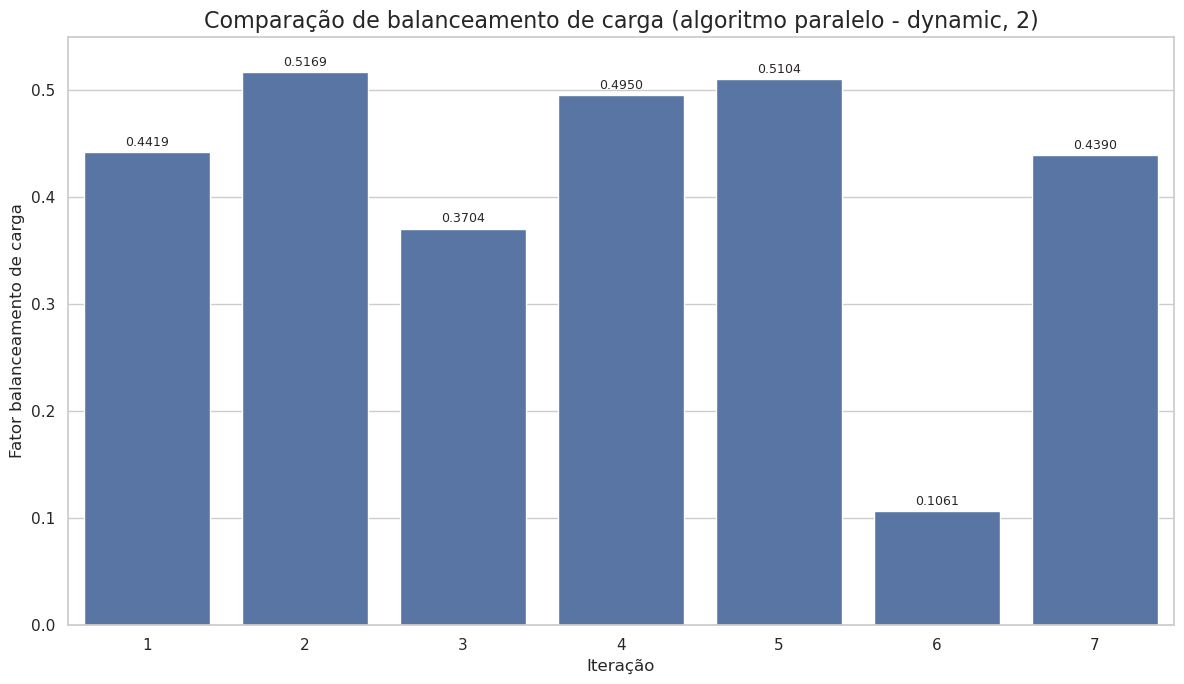

In [91]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - dynamic, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.55)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [92]:
print("Speed-up")
print("Média:", dynamic_df["speed_up"].mean())
print("Desvio padrão:", dynamic_df["speed_up"].std())
print("Valor mínimo:", dynamic_df["speed_up"].min())
print("Valor máximo:", dynamic_df["speed_up"].max())

Speed-up
Média: 1.5487715
Desvio padrão: 0.34472692
Valor mínimo: 1.0329129
Valor máximo: 1.7712668


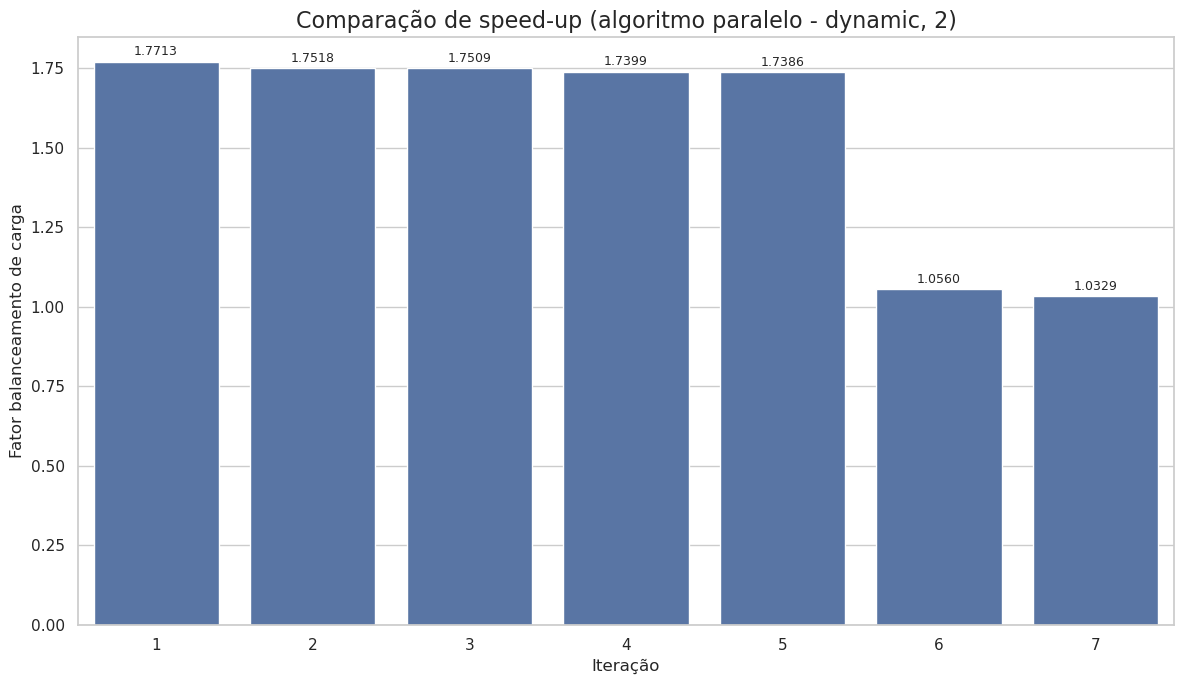

In [93]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - dynamic, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.85)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [94]:
print("Eficiência")
print("Média:", dynamic_df["eficiencia"].mean())
print("Desvio padrão:", dynamic_df["eficiencia"].std())
print("Valor mínimo:", dynamic_df["eficiencia"].min())
print("Valor máximo:", dynamic_df["eficiencia"].max())

Eficiência
Média: 0.38719288
Desvio padrão: 0.08618173
Valor mínimo: 0.2582282
Valor máximo: 0.4428167


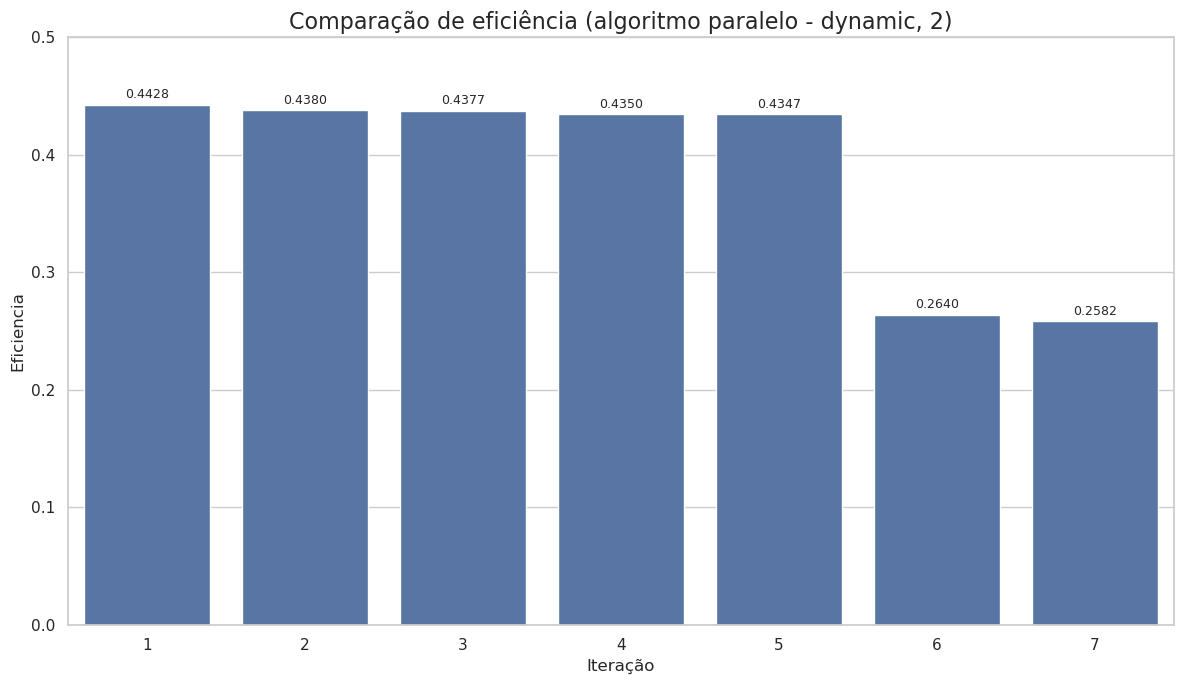

In [95]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - dynamic, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.5)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Dynamic, 4

In [96]:
dynamic_df: pd.DataFrame = results_df.query("nome_modo == 'dynamic' and valor_modo == 4")
dynamic_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
63,1,9.373476,0.5,dynamic,4,0.418605,1.038679,0.259670
64,2,9.425068,0.5,dynamic,4,0.458333,1.023222,0.255805
65,3,9.420016,0.5,dynamic,4,0.307692,1.019524,0.254881
66,4,9.474835,0.5,dynamic,4,0.512821,1.011850,0.252962
67,5,9.431231,0.5,dynamic,4,0.500000,1.015394,0.253849
68,6,5.512187,0.5,dynamic,4,0.441860,1.055857,0.263964
69,7,6.625755,0.5,dynamic,4,0.487805,0.865341,0.216335


##### Tempo de execução

In [97]:
print("TEMPO")
print("Média:", dynamic_df["tempo"].mean())
print("Desvio padrão:", dynamic_df["tempo"].std())
print("Valor mínimo:", dynamic_df["tempo"].min())
print("Valor máximo:", dynamic_df["tempo"].max())

TEMPO
Média: 8.466082
Desvio padrão: 1.6690518
Valor mínimo: 5.512187
Valor máximo: 9.474835


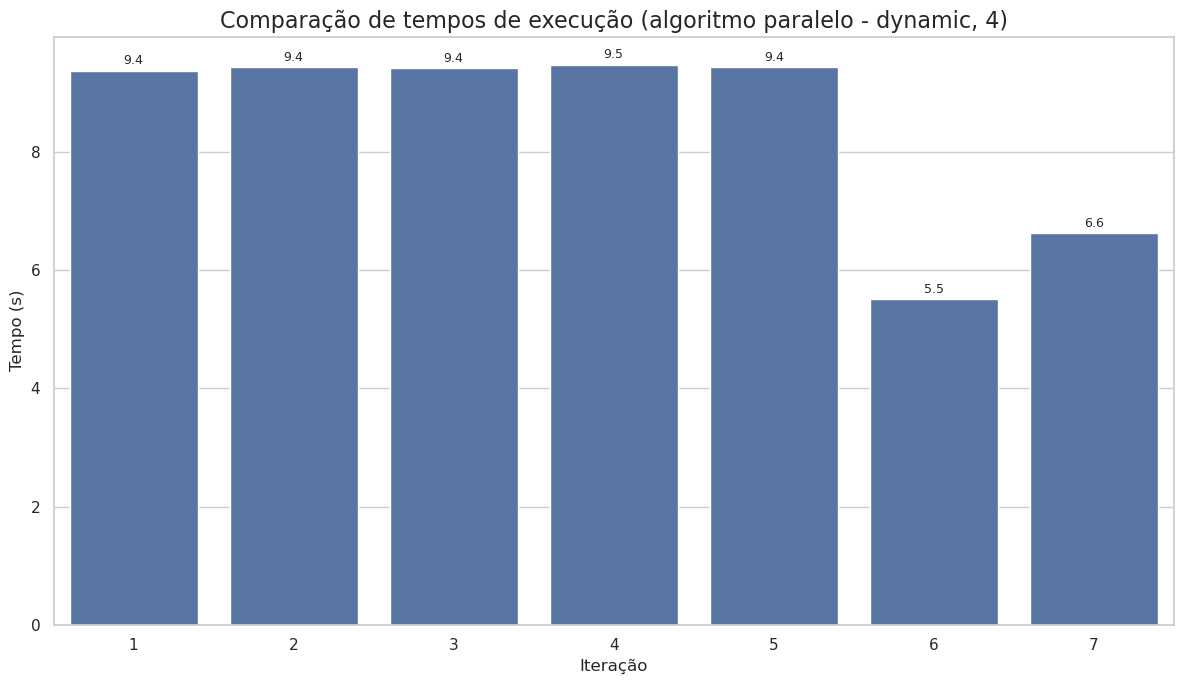

In [98]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - dynamic, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [99]:
print("Fab")
print("Média:", dynamic_df["Fab"].mean())
print("Desvio padrão:", dynamic_df["Fab"].std())
print("Valor mínimo:", dynamic_df["Fab"].min())
print("Valor máximo:", dynamic_df["Fab"].max())

Fab
Média: 0.44673087857142857
Desvio padrão: 0.0697300249968162
Valor mínimo: 0.30769231
Valor máximo: 0.51282051


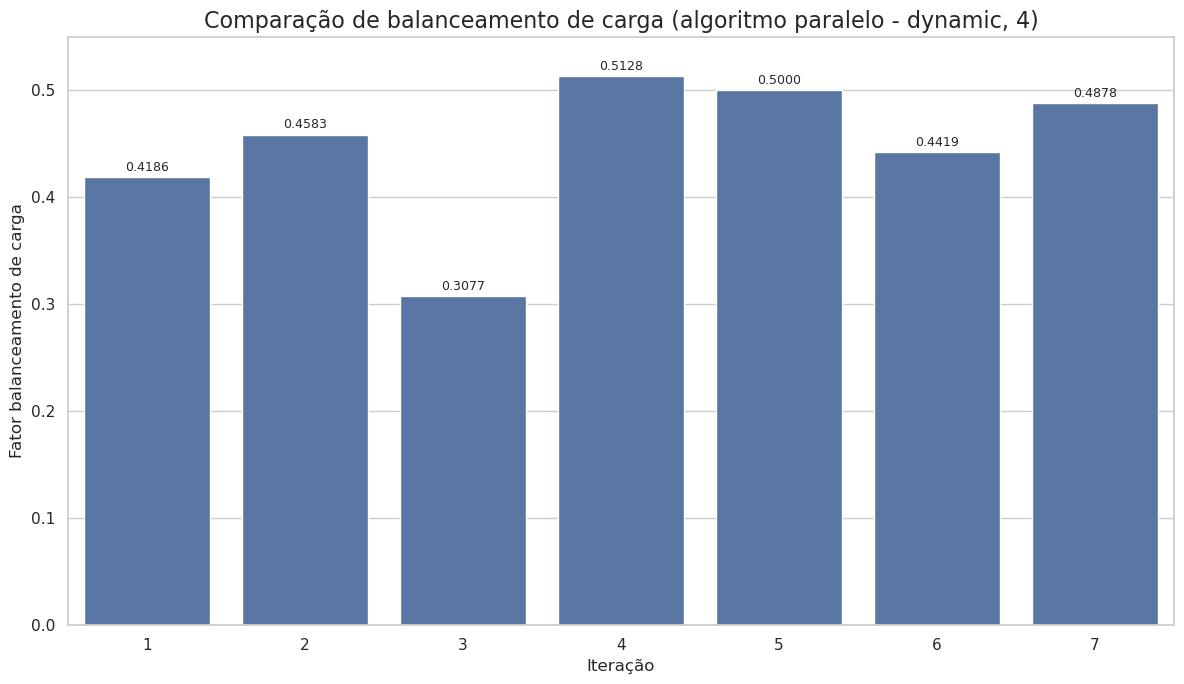

In [100]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - dynamic, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.55)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [101]:
print("Speed-up")
print("Média:", dynamic_df["speed_up"].mean())
print("Desvio padrão:", dynamic_df["speed_up"].std())
print("Valor mínimo:", dynamic_df["speed_up"].min())
print("Valor máximo:", dynamic_df["speed_up"].max())

Speed-up
Média: 1.0042666
Desvio padrão: 0.063139446
Valor mínimo: 0.86534077
Valor máximo: 1.0558566


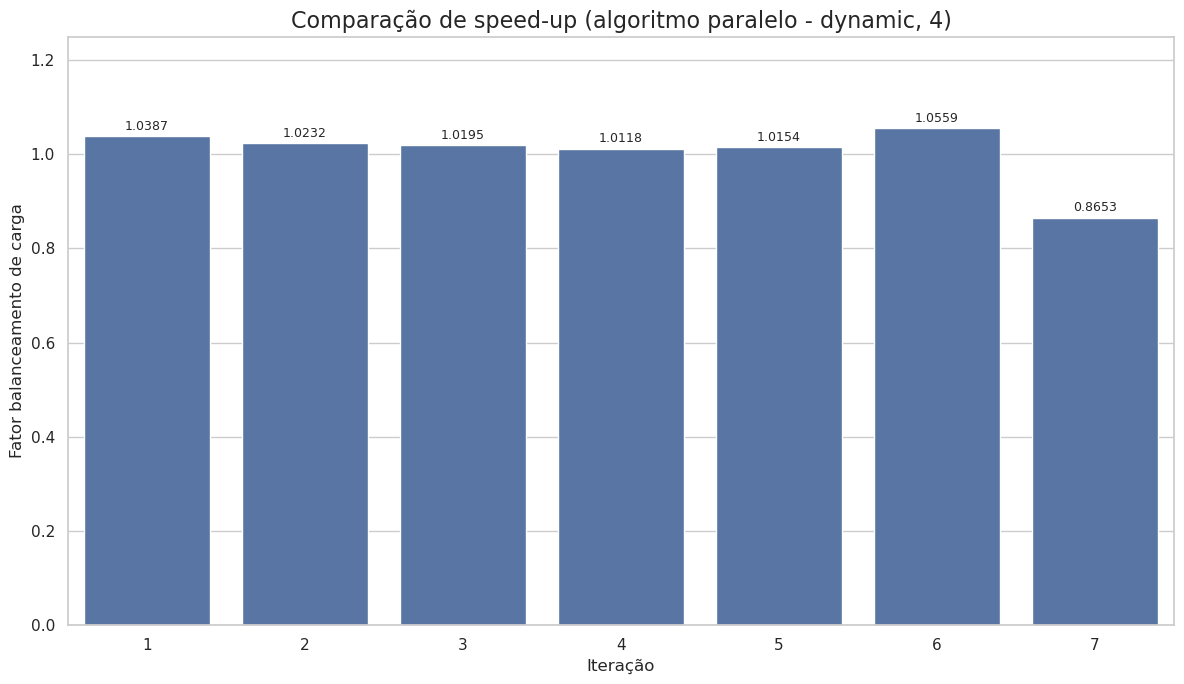

In [102]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - dynamic, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.25)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [103]:
print("Eficiência")
print("Média:", dynamic_df["eficiencia"].mean())
print("Desvio padrão:", dynamic_df["eficiencia"].std())
print("Valor mínimo:", dynamic_df["eficiencia"].min())
print("Valor máximo:", dynamic_df["eficiencia"].max())

Eficiência
Média: 0.25106665
Desvio padrão: 0.015784862
Valor mínimo: 0.21633519
Valor máximo: 0.26396415


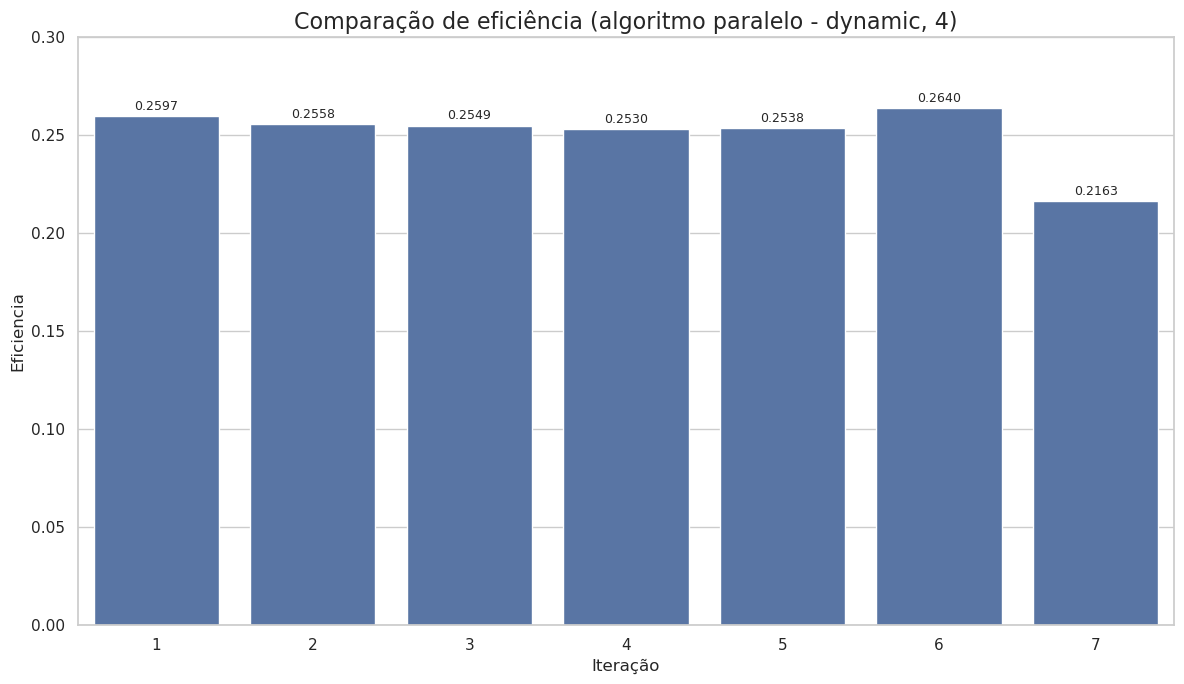

In [104]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - dynamic, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.3)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Dynamic, 8

In [105]:
dynamic_df: pd.DataFrame = results_df.query("nome_modo == 'dynamic' and valor_modo == 8")
dynamic_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
70,1,5.573108,0.5,dynamic,8,0.500000,1.746966,0.436741
71,2,5.605294,0.5,dynamic,8,0.521739,1.720505,0.430126
72,3,5.556590,0.5,dynamic,8,0.434783,1.728387,0.432097
73,4,5.586041,0.5,dynamic,8,0.222222,1.716262,0.429066
74,5,5.571325,0.5,dynamic,8,0.520000,1.718876,0.429719
75,6,5.557799,0.5,dynamic,8,0.428571,1.047191,0.261798
76,7,5.561795,0.5,dynamic,8,0.454545,1.030879,0.257720


##### Tempo de execução

In [106]:
print("TEMPO")
print("Média:", dynamic_df["tempo"].mean())
print("Desvio padrão:", dynamic_df["tempo"].std())
print("Valor mínimo:", dynamic_df["tempo"].min())
print("Valor máximo:", dynamic_df["tempo"].max())

TEMPO
Média: 5.573136
Desvio padrão: 0.017519414
Valor mínimo: 5.55659
Valor máximo: 5.605294


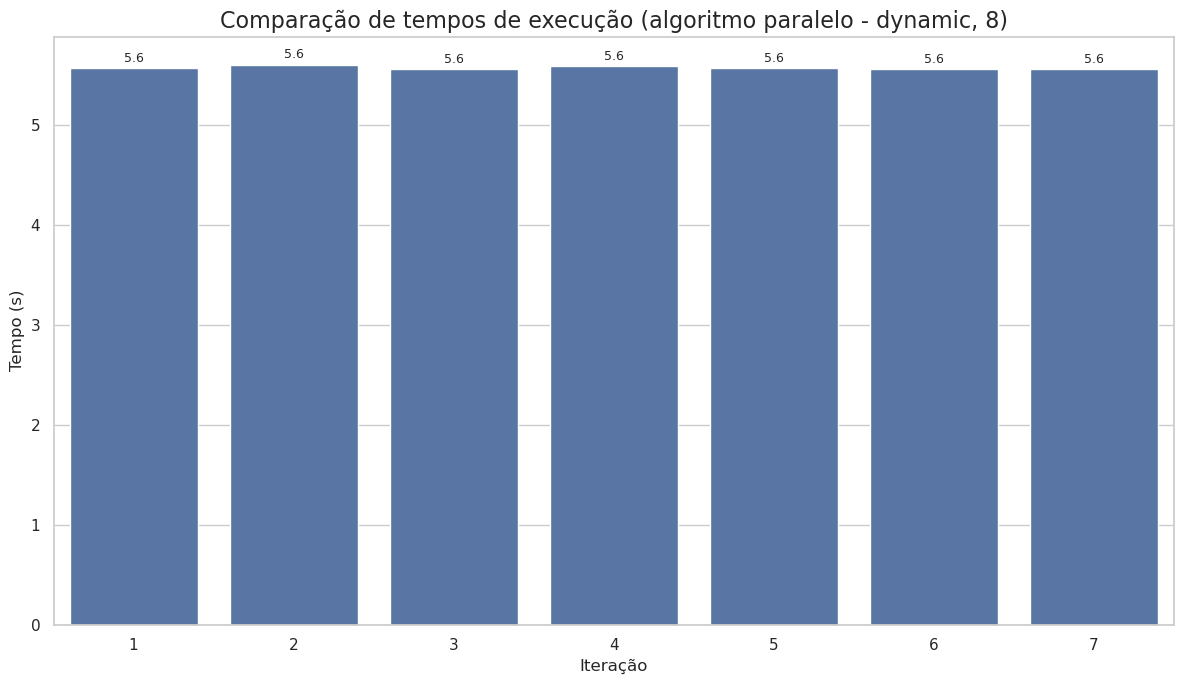

In [107]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - dynamic, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [108]:
print("Fab")
print("Média:", dynamic_df["Fab"].mean())
print("Desvio padrão:", dynamic_df["Fab"].std())
print("Valor mínimo:", dynamic_df["Fab"].min())
print("Valor máximo:", dynamic_df["Fab"].max())

Fab
Média: 0.44026583428571425
Desvio padrão: 0.10366400504046118
Valor mínimo: 0.22222222
Valor máximo: 0.52173913


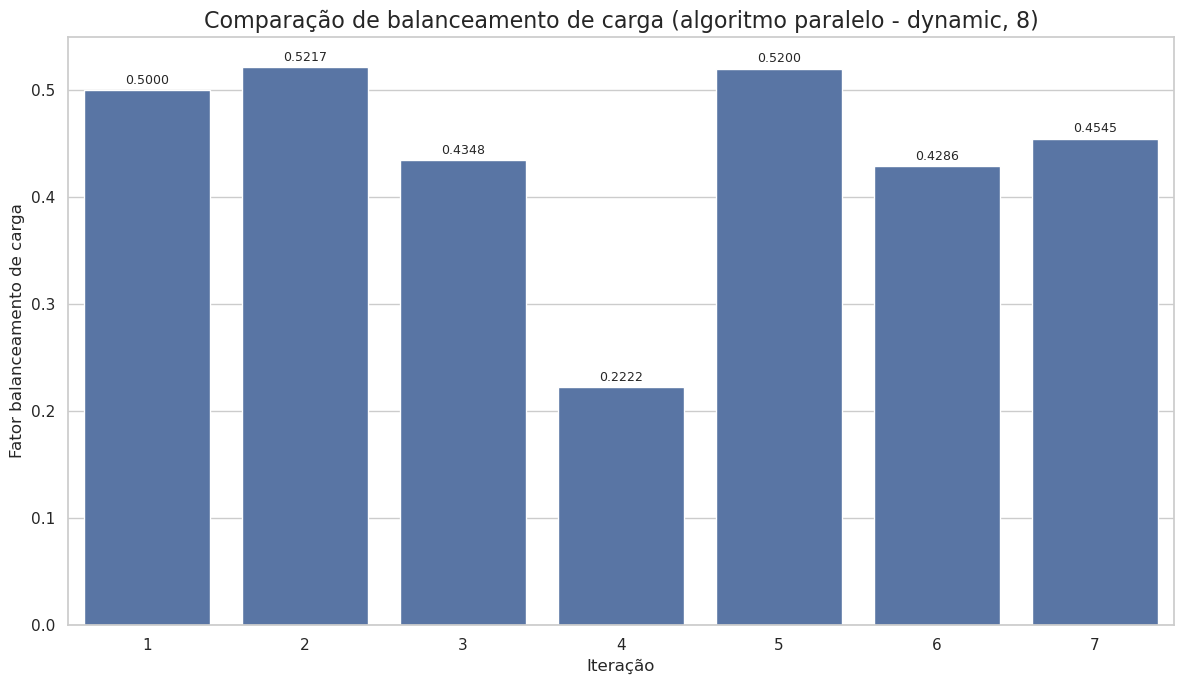

In [109]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - dynamic, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.55)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [110]:
print("Speed-up")
print("Média:", dynamic_df["speed_up"].mean())
print("Desvio padrão:", dynamic_df["speed_up"].std())
print("Valor mínimo:", dynamic_df["speed_up"].min())
print("Valor máximo:", dynamic_df["speed_up"].max())

Speed-up
Média: 1.5298666
Desvio padrão: 0.3354891
Valor mínimo: 1.0308787
Valor máximo: 1.7469659


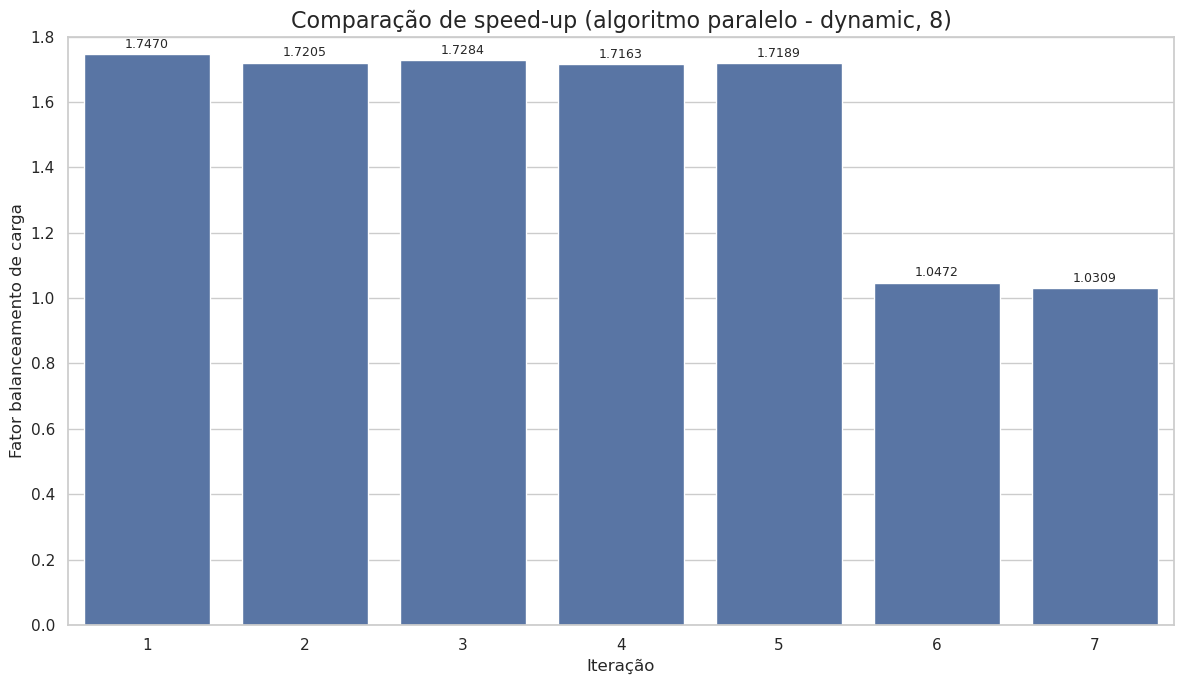

In [111]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - dynamic, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.8)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [112]:
print("Eficiência")
print("Média:", dynamic_df["eficiencia"].mean())
print("Desvio padrão:", dynamic_df["eficiencia"].std())
print("Valor mínimo:", dynamic_df["eficiencia"].min())
print("Valor máximo:", dynamic_df["eficiencia"].max())

Eficiência
Média: 0.38246664
Desvio padrão: 0.08387227
Valor mínimo: 0.25771967
Valor máximo: 0.43674147


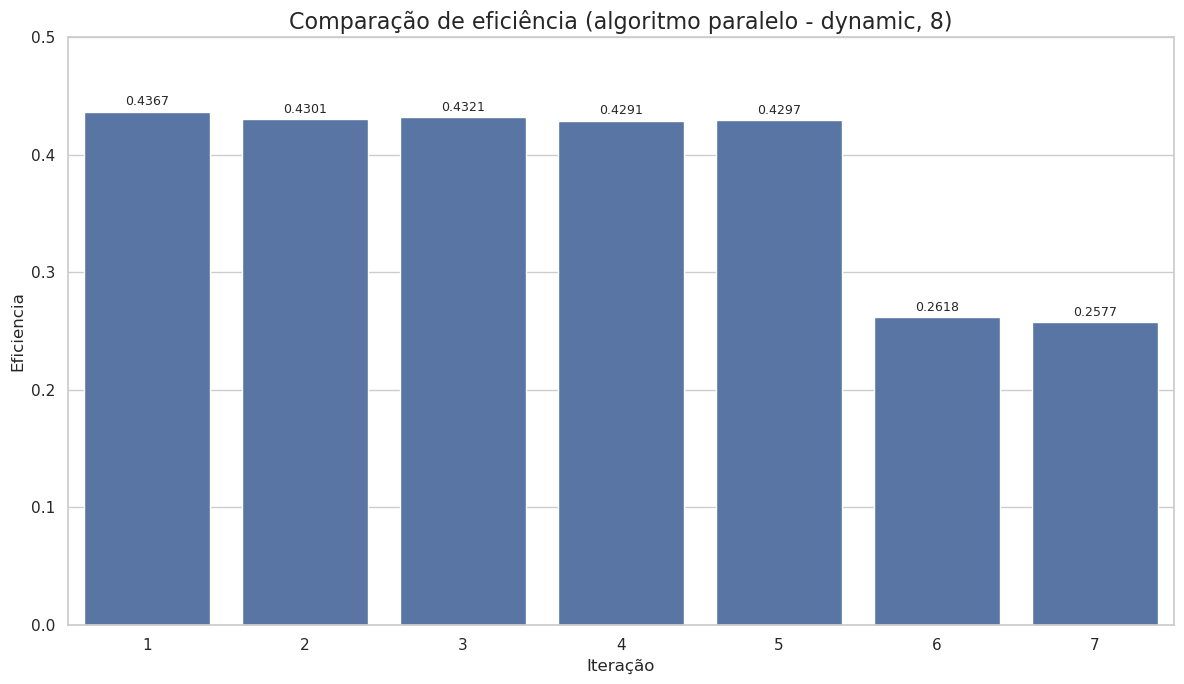

In [113]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - dynamic, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.5)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Dynamic, 16

In [114]:
dynamic_df: pd.DataFrame = results_df.query("nome_modo == 'dynamic' and valor_modo == 16")
dynamic_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
77,1,5.567066,0.5,dynamic,16,0.454545,1.748862,0.437215
78,2,5.576582,0.5,dynamic,16,0.400000,1.729363,0.432341
79,3,5.590791,0.5,dynamic,16,0.222222,1.717814,0.429453
80,4,5.528856,0.5,dynamic,16,0.300000,1.734014,0.433503
81,5,5.581992,0.5,dynamic,16,0.454545,1.715591,0.428898
82,6,5.558937,0.5,dynamic,16,0.400000,1.046977,0.261744
83,7,5.544265,0.5,dynamic,16,0.300000,1.034138,0.258535


##### Tempo de execução

In [115]:
print("TEMPO")
print("Média:", dynamic_df["tempo"].mean())
print("Desvio padrão:", dynamic_df["tempo"].std())
print("Valor mínimo:", dynamic_df["tempo"].min())
print("Valor máximo:", dynamic_df["tempo"].max())

TEMPO
Média: 5.56407
Desvio padrão: 0.021830356
Valor mínimo: 5.528856
Valor máximo: 5.590791


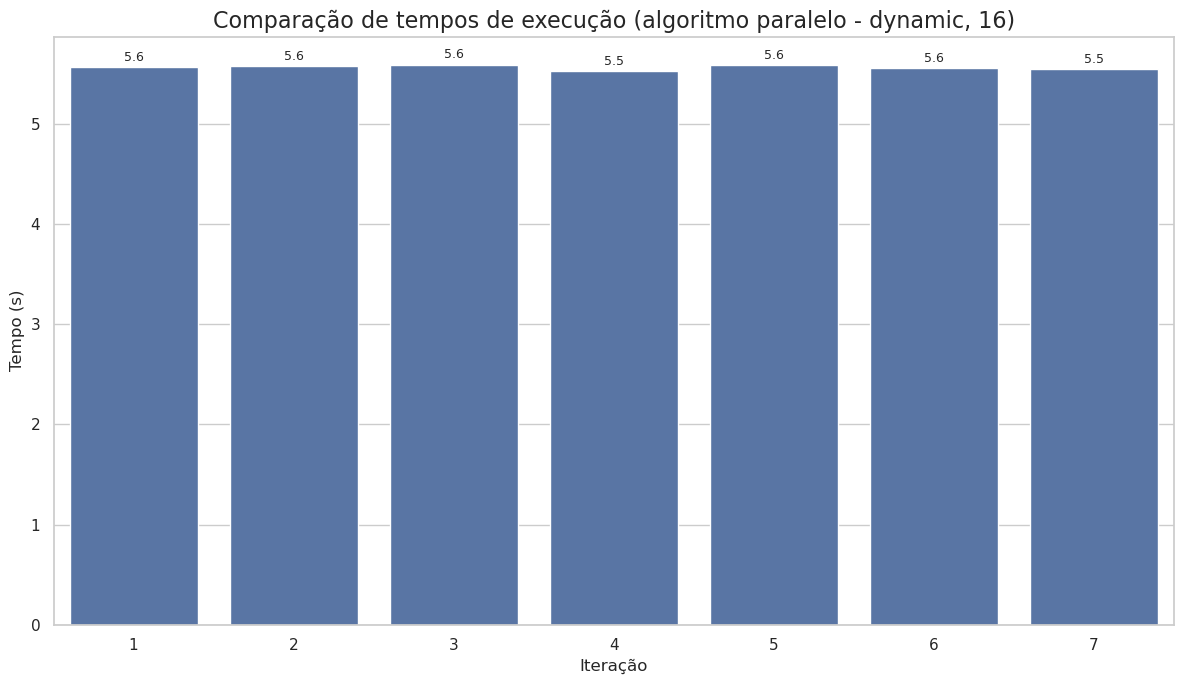

In [116]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - dynamic, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [117]:
print("Fab")
print("Média:", dynamic_df["Fab"].mean())
print("Desvio padrão:", dynamic_df["Fab"].std())
print("Valor mínimo:", dynamic_df["Fab"].min())
print("Valor máximo:", dynamic_df["Fab"].max())

Fab
Média: 0.36161615999999996
Desvio padrão: 0.08873379390167932
Valor mínimo: 0.22222222
Valor máximo: 0.45454545


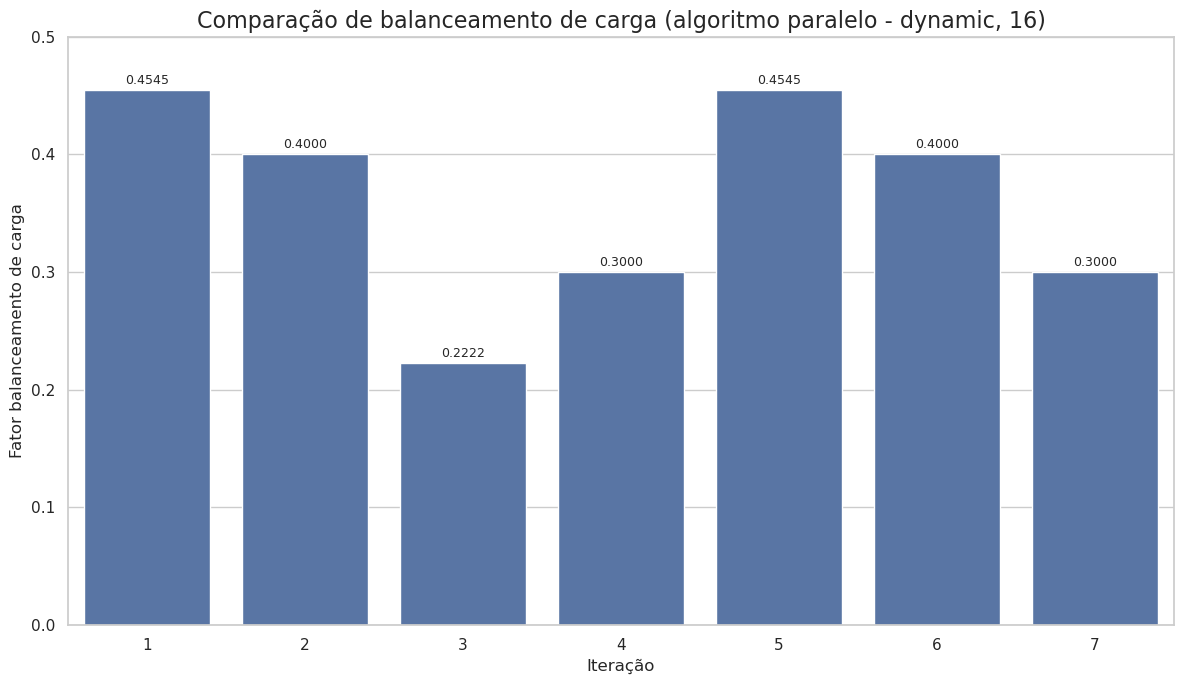

In [118]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - dynamic, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.5)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [119]:
print("Speed-up")
print("Média:", dynamic_df["speed_up"].mean())
print("Desvio padrão:", dynamic_df["speed_up"].std())
print("Valor mínimo:", dynamic_df["speed_up"].min())
print("Valor máximo:", dynamic_df["speed_up"].max())

Speed-up
Média: 1.5323942
Desvio padrão: 0.33618844
Valor mínimo: 1.0341382
Valor máximo: 1.7488618


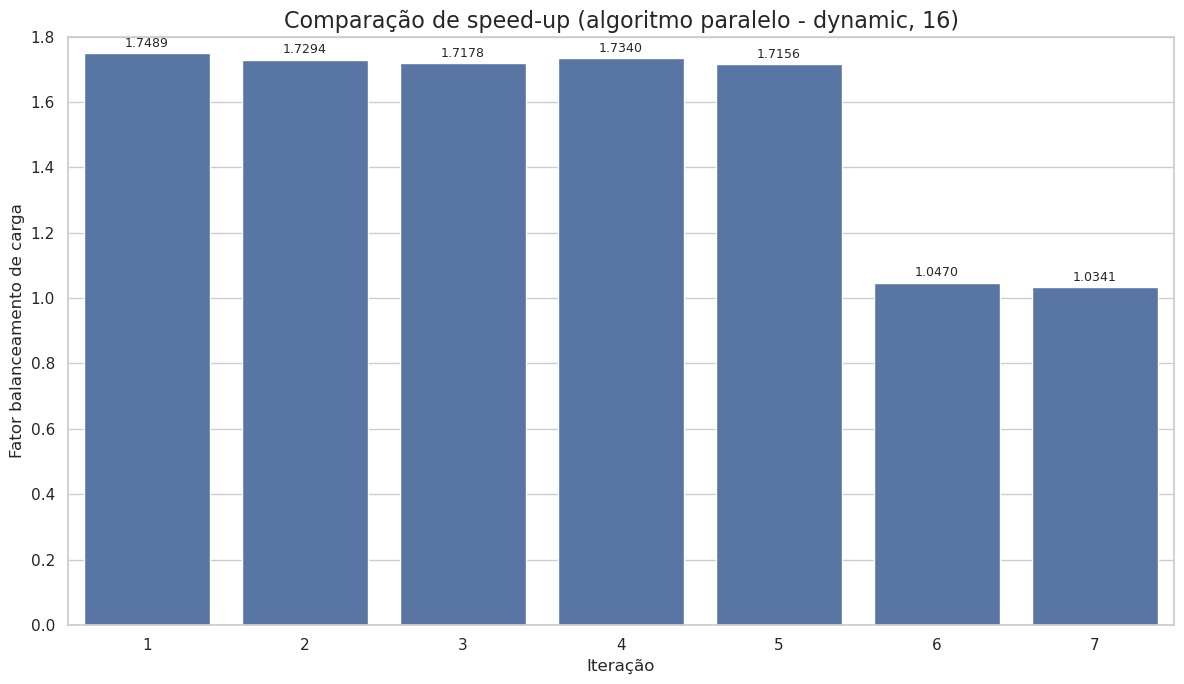

In [120]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - dynamic, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.8)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [121]:
print("Eficiência")
print("Média:", dynamic_df["eficiencia"].mean())
print("Desvio padrão:", dynamic_df["eficiencia"].std())
print("Valor mínimo:", dynamic_df["eficiencia"].min())
print("Valor máximo:", dynamic_df["eficiencia"].max())

Eficiência
Média: 0.38309854
Desvio padrão: 0.08404711
Valor mínimo: 0.25853455
Valor máximo: 0.43721545


Text(0.5, 1.0, 'Comparação de eficiência (algoritmo paralelo - dynamic, 16)')

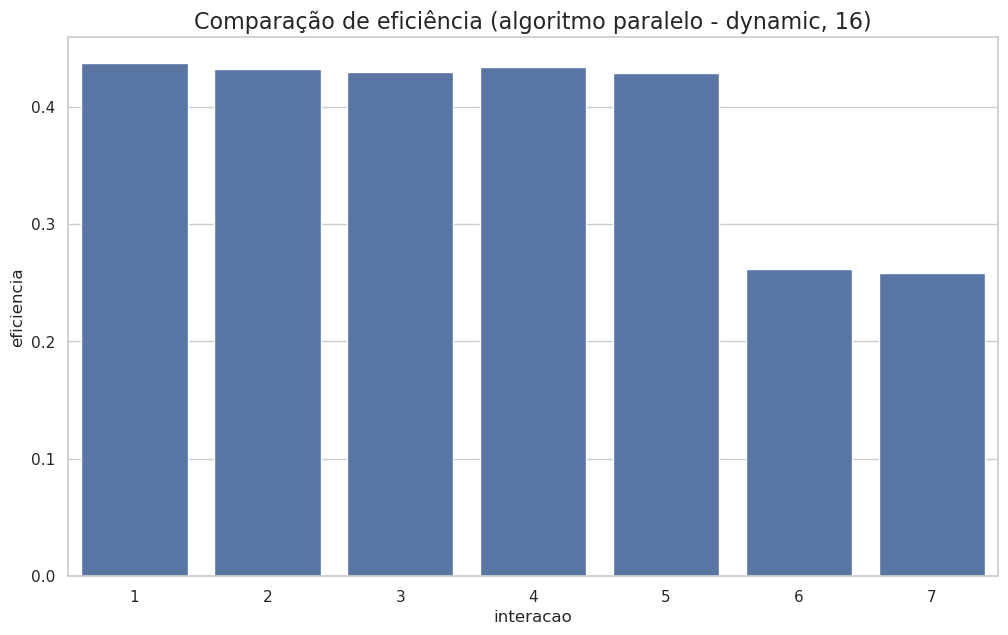

In [122]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=dynamic_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - dynamic, 16)", fontsize=16)


#### Static, todos juntos

In [123]:
dynamic_df: pd.DataFrame = results_df[results_df["nome_modo"] == "dynamic"]
dynamic_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
49,1,9.415752,0.5,dynamic,1,0.291139,1.034015,0.258504
50,2,9.431909,0.5,dynamic,1,0.494624,1.022480,0.255620
51,3,9.429630,0.5,dynamic,1,0.269737,1.018485,0.254621
52,4,9.442116,0.5,dynamic,1,0.414365,1.015356,0.253839
53,5,9.369778,0.5,dynamic,1,0.470930,1.022054,0.255513
54,6,9.449298,0.5,dynamic,1,0.416667,0.615927,0.153982
55,7,9.420634,0.5,dynamic,1,0.471910,0.608615,0.152154
56,1,5.496648,0.5,dynamic,2,0.441860,1.771267,0.442817
57,2,5.505139,0.5,dynamic,2,0.516854,1.751806,0.437952
58,3,5.485201,0.5,dynamic,2,0.370370,1.750882,0.437720


##### Tempo de execução

In [124]:
print("TEMPO")
print("Média:", dynamic_df["tempo"].mean())
print("Desvio padrão:", dynamic_df["tempo"].std())
print("Valor mínimo:", dynamic_df["tempo"].min())
print("Valor máximo:", dynamic_df["tempo"].max())

TEMPO
Média: 6.9071274
Desvio padrão: 1.8533785
Valor mínimo: 5.485201
Valor máximo: 9.474835


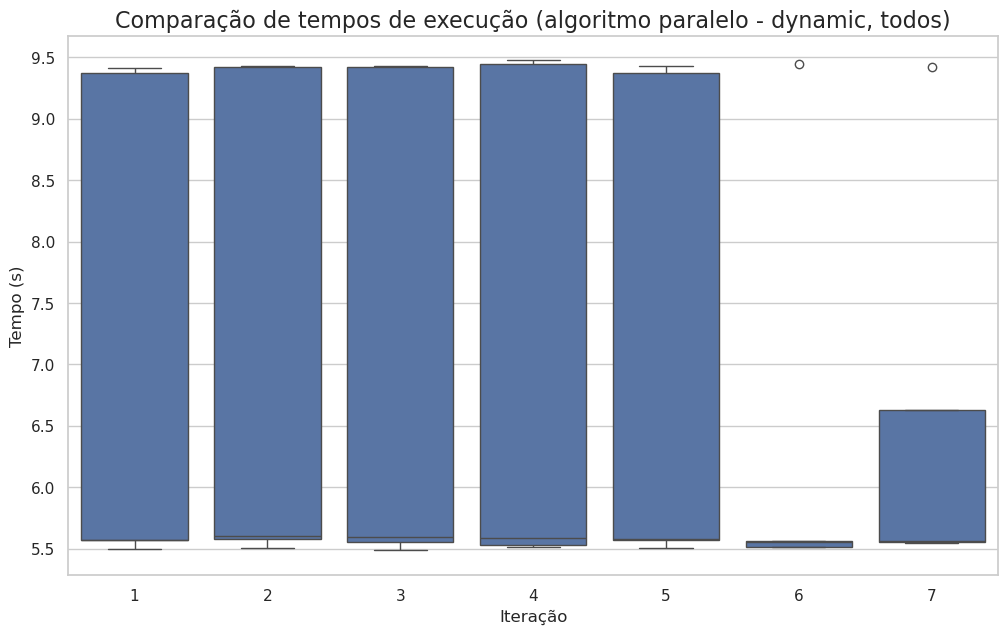

In [125]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=dynamic_df, x="interacao", y="tempo")

plt.title("Comparação de tempos de execução (algoritmo paralelo - dynamic, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.show()

##### Fator de balanceamento de carga (Fab)

In [126]:
print("Fab")
print("Média:", dynamic_df["Fab"].mean())
print("Desvio padrão:", dynamic_df["Fab"].std())
print("Valor mínimo:", dynamic_df["Fab"].min())
print("Valor máximo:", dynamic_df["Fab"].max())

Fab
Média: 0.4128370697142858
Desvio padrão: 0.10087384902456123
Valor mínimo: 0.10606061
Valor máximo: 0.52173913


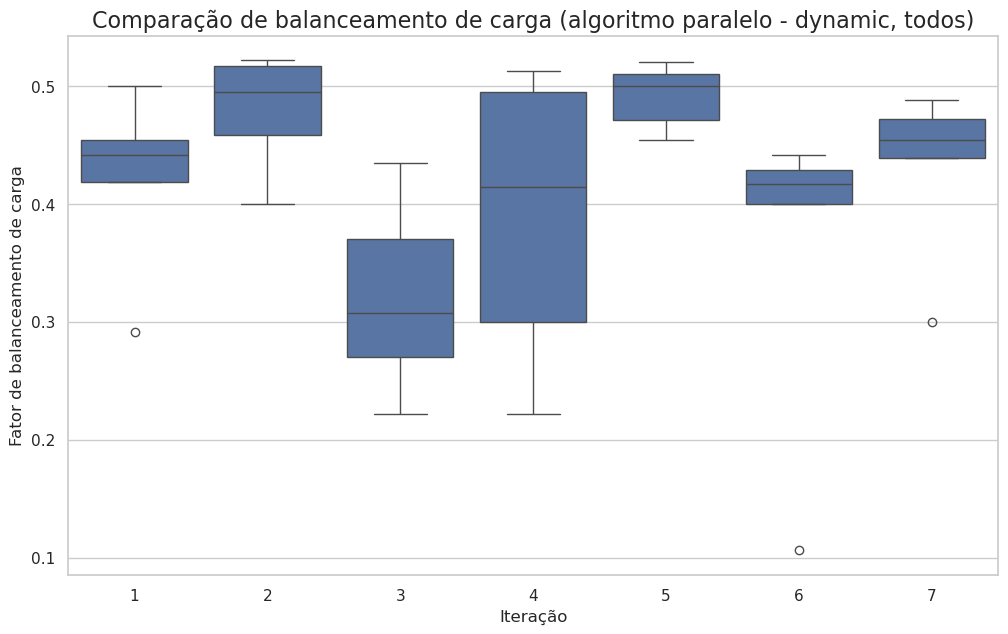

In [127]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=dynamic_df, x="interacao", y="Fab")

plt.title("Comparação de balanceamento de carga (algoritmo paralelo - dynamic, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de balanceamento de carga", fontsize=12)
plt.show()

##### *Speed-up*

In [128]:
print("Speed-up")
print("Média:", dynamic_df["speed_up"].mean())
print("Desvio padrão:", dynamic_df["speed_up"].std())
print("Valor mínimo:", dynamic_df["speed_up"].min())
print("Valor máximo:", dynamic_df["speed_up"].max())

Speed-up
Média: 1.3041149
Desvio padrão: 0.39161804
Valor mínimo: 0.6086146
Valor máximo: 1.7712668


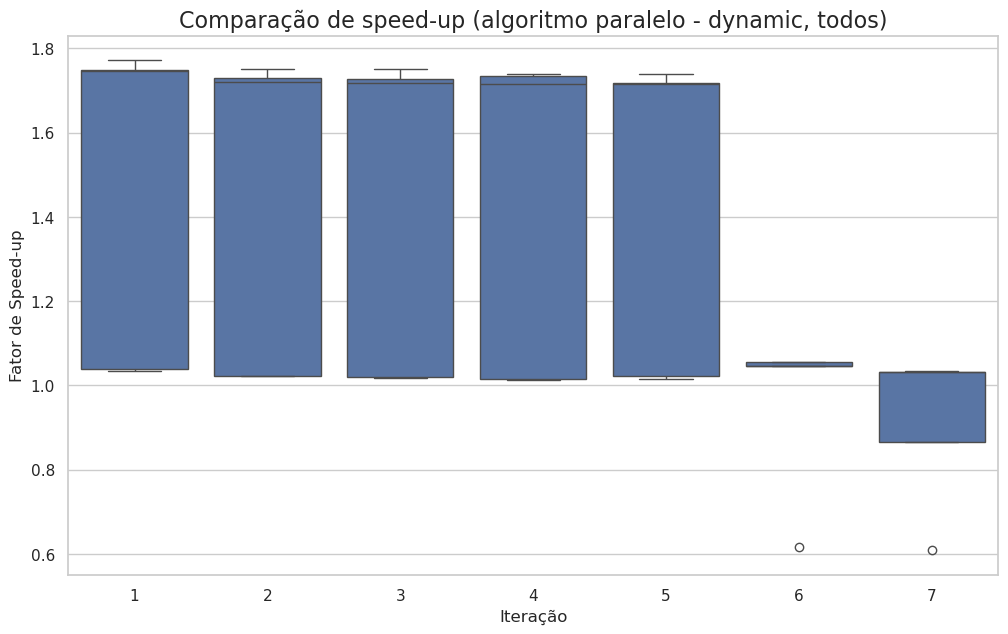

In [129]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=dynamic_df, x="interacao", y="speed_up")

plt.title("Comparação de speed-up (algoritmo paralelo - dynamic, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de Speed-up", fontsize=12)
plt.show()

##### Eficiência

In [130]:
print("Eficiência")
print("Média:", dynamic_df["eficiencia"].mean())
print("Desvio padrão:", dynamic_df["eficiencia"].std())
print("Valor mínimo:", dynamic_df["eficiencia"].min())
print("Valor máximo:", dynamic_df["eficiencia"].max())

Eficiência
Média: 0.32602873
Desvio padrão: 0.09790451
Valor mínimo: 0.15215366
Valor máximo: 0.4428167


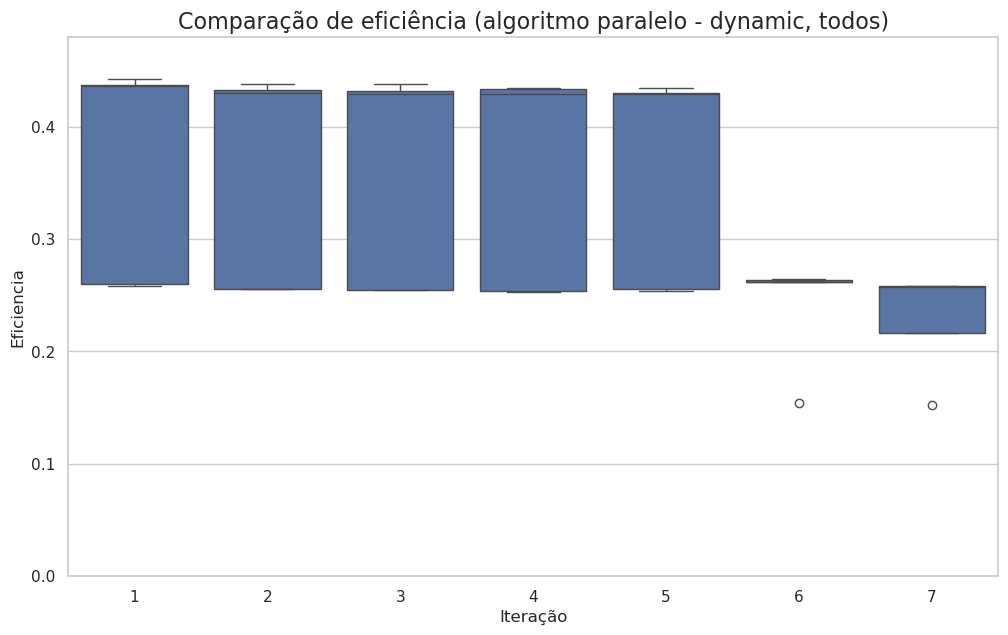

In [131]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=dynamic_df, x="interacao", y="eficiencia")

plt.title("Comparação de eficiência (algoritmo paralelo - dynamic, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.48)
plt.show()

#### Guided

Nesse subcapítulo serão visualizados os dados da implementação paralela com `schedule` **guided**.

#### Guided, 1

In [132]:
guided_df: pd.DataFrame = results_df.query("nome_modo == 'guided' and valor_modo == 1").copy()
guided_df.head()

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
84,1,9.396616,0.5,guided,1,0.060606,1.036121,0.259030
85,2,9.536132,0.5,guided,1,0.372781,1.011305,0.252826
86,3,9.445127,0.5,guided,1,0.409938,1.016814,0.254203
87,4,11.499469,0.5,guided,1,0.371257,0.833700,0.208425
88,5,9.469010,0.5,guided,1,0.491429,1.011343,0.252836


##### Tempo de execução

In [133]:
print("TEMPO")
print("Média:", guided_df["tempo"].mean())
print("Desvio padrão:", guided_df["tempo"].std())
print("Valor mínimo:", guided_df["tempo"].min())
print("Valor máximo:", guided_df["tempo"].max())

TEMPO
Média: 8.64106
Desvio padrão: 2.2260342
Valor mínimo: 5.55377
Valor máximo: 11.499469


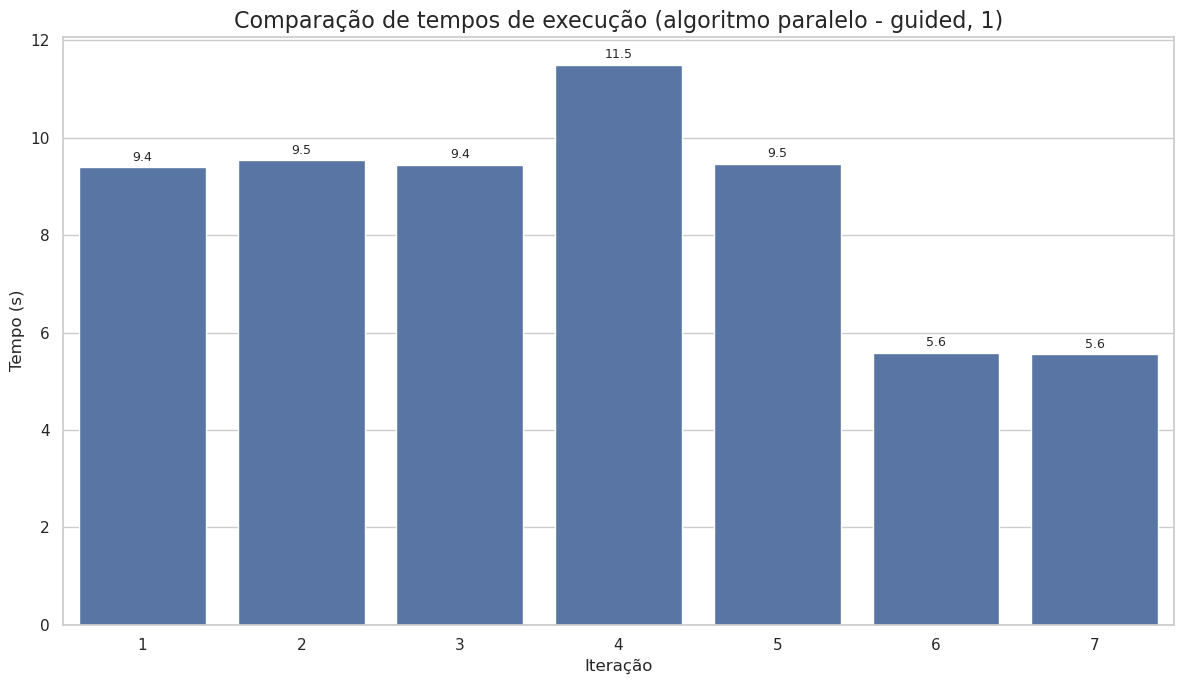

In [134]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - guided, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [135]:
print("Fab")
print("Média:", guided_df["Fab"].mean())
print("Desvio padrão:", guided_df["Fab"].std())
print("Valor mínimo:", guided_df["Fab"].min())
print("Valor máximo:", guided_df["Fab"].max())

Fab
Média: 0.3238496042857143
Desvio padrão: 0.15867698675556105
Valor mínimo: 0.06060606
Valor máximo: 0.49142857


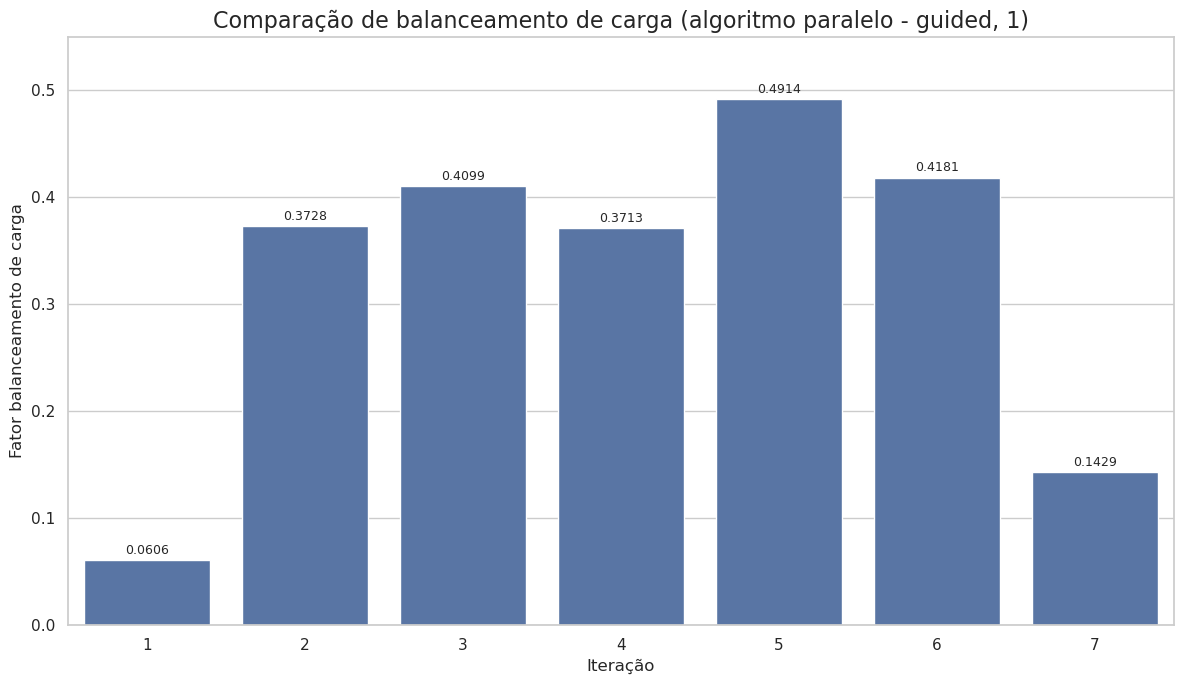

In [136]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - guided, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.55)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [137]:
print("Speed-up")
print("Média:", guided_df["speed_up"].mean())
print("Desvio padrão:", guided_df["speed_up"].std())
print("Valor mínimo:", guided_df["speed_up"].min())
print("Valor máximo:", guided_df["speed_up"].max())

Speed-up
Média: 0.9976163
Desvio padrão: 0.07330656
Valor mínimo: 0.8337005
Valor máximo: 1.0416626


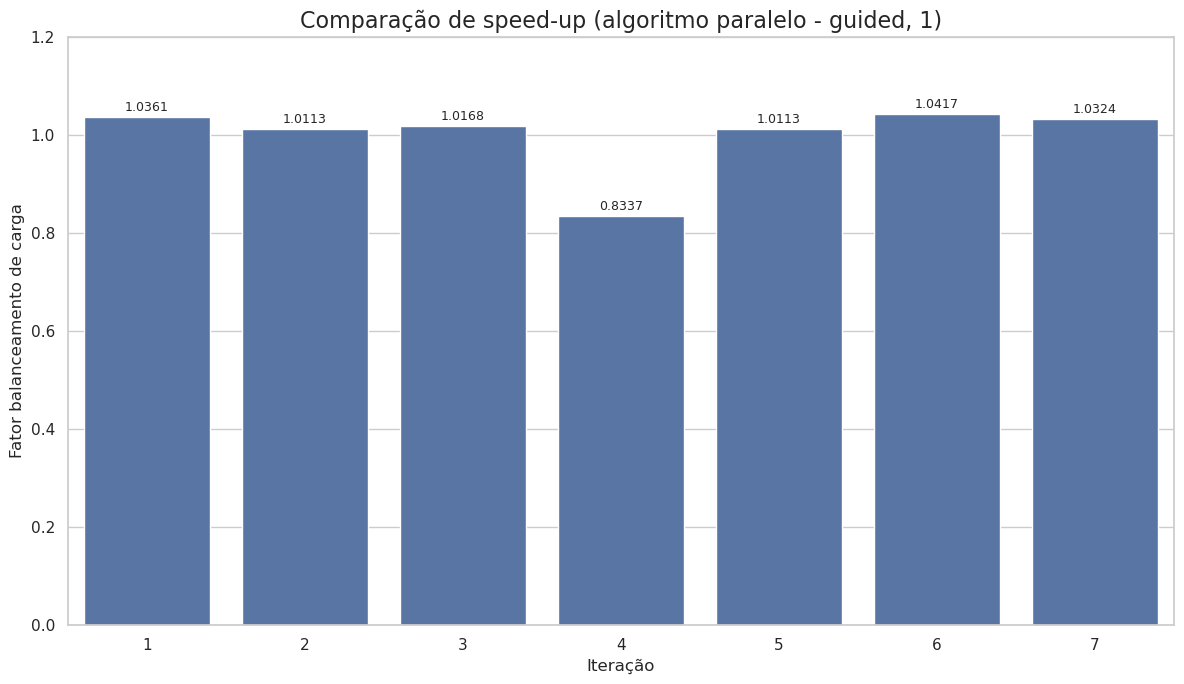

In [138]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - guided, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.2)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [139]:
print("Eficiência")
print("Média:", guided_df["eficiencia"].mean())
print("Desvio padrão:", guided_df["eficiencia"].std())
print("Valor mínimo:", guided_df["eficiencia"].min())
print("Valor máximo:", guided_df["eficiencia"].max())

Eficiência
Média: 0.24940407
Desvio padrão: 0.01832664
Valor mínimo: 0.20842512
Valor máximo: 0.26041564


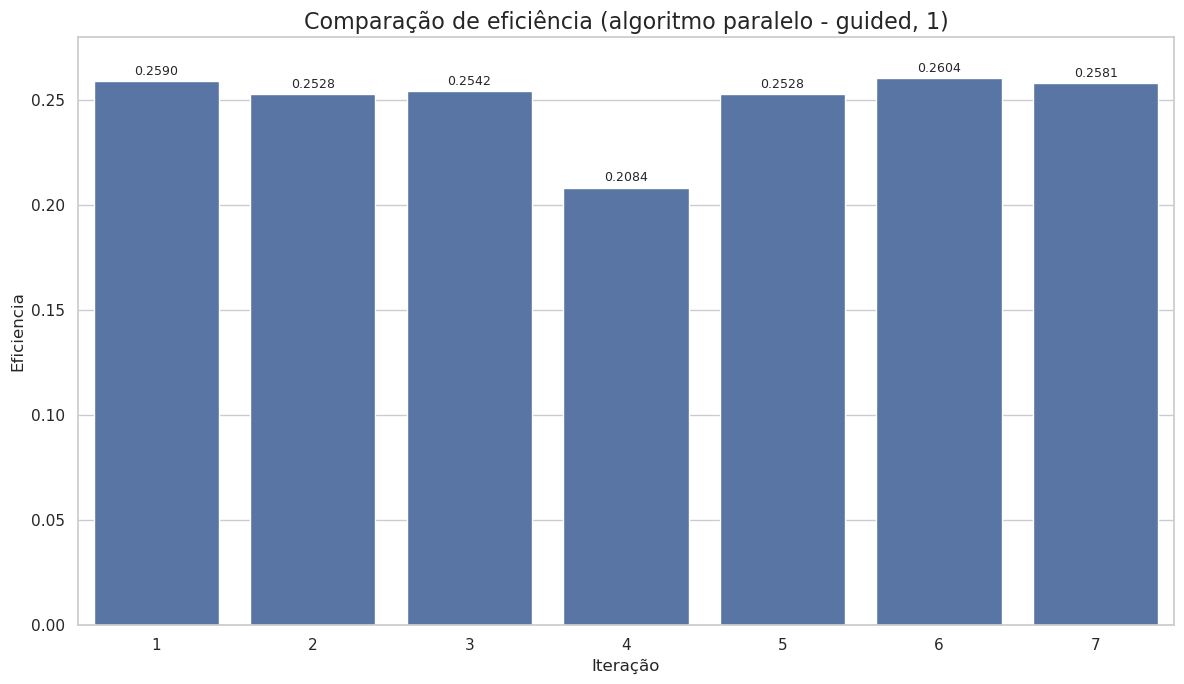

In [140]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - guided, 1)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.28)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Guided, 2

In [141]:
guided_df: pd.DataFrame = results_df.query("nome_modo == 'guided' and valor_modo == 2").copy()
guided_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
91,1,9.389120,0.5,guided,2,0.190141,1.036948,0.259237
92,2,9.451968,0.5,guided,2,0.417647,1.020310,0.255077
93,3,9.461125,0.5,guided,2,0.347561,1.015095,0.253774
94,4,9.496612,0.5,guided,2,0.497110,1.009530,0.252382
95,5,9.531858,0.5,guided,2,0.453488,1.004675,0.251169
96,6,5.556785,0.5,guided,2,0.500000,1.047382,0.261846
97,7,6.469254,0.5,guided,2,0.522222,0.886275,0.221569


##### Tempo de execução

In [142]:
print("TEMPO")
print("Média:", guided_df["tempo"].mean())
print("Desvio padrão:", guided_df["tempo"].std())
print("Valor mínimo:", guided_df["tempo"].min())
print("Valor máximo:", guided_df["tempo"].max())

TEMPO
Média: 8.479531
Desvio padrão: 1.7059708
Valor mínimo: 5.556785
Valor máximo: 9.531858


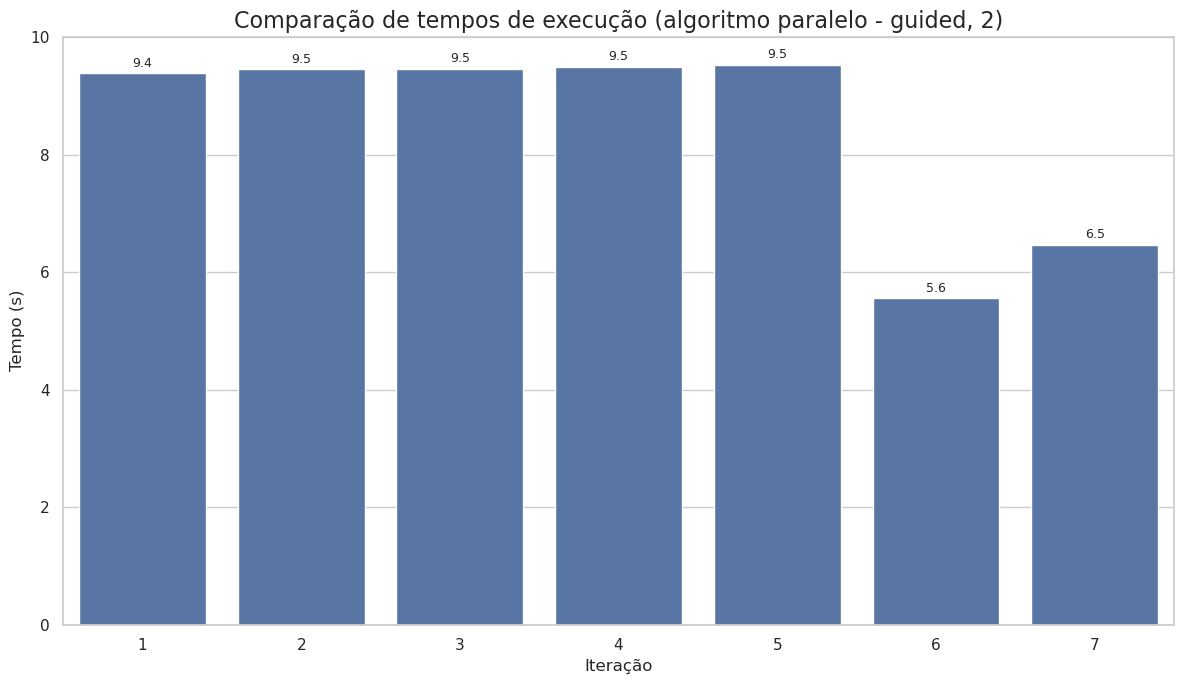

In [143]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - guided, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [144]:
print("Fab")
print("Média:", guided_df["Fab"].mean())
print("Desvio padrão:", guided_df["Fab"].std())
print("Valor mínimo:", guided_df["Fab"].min())
print("Valor máximo:", guided_df["Fab"].max())

Fab
Média: 0.4183099014285715
Desvio padrão: 0.11689379853901052
Valor mínimo: 0.19014085
Valor máximo: 0.52222222


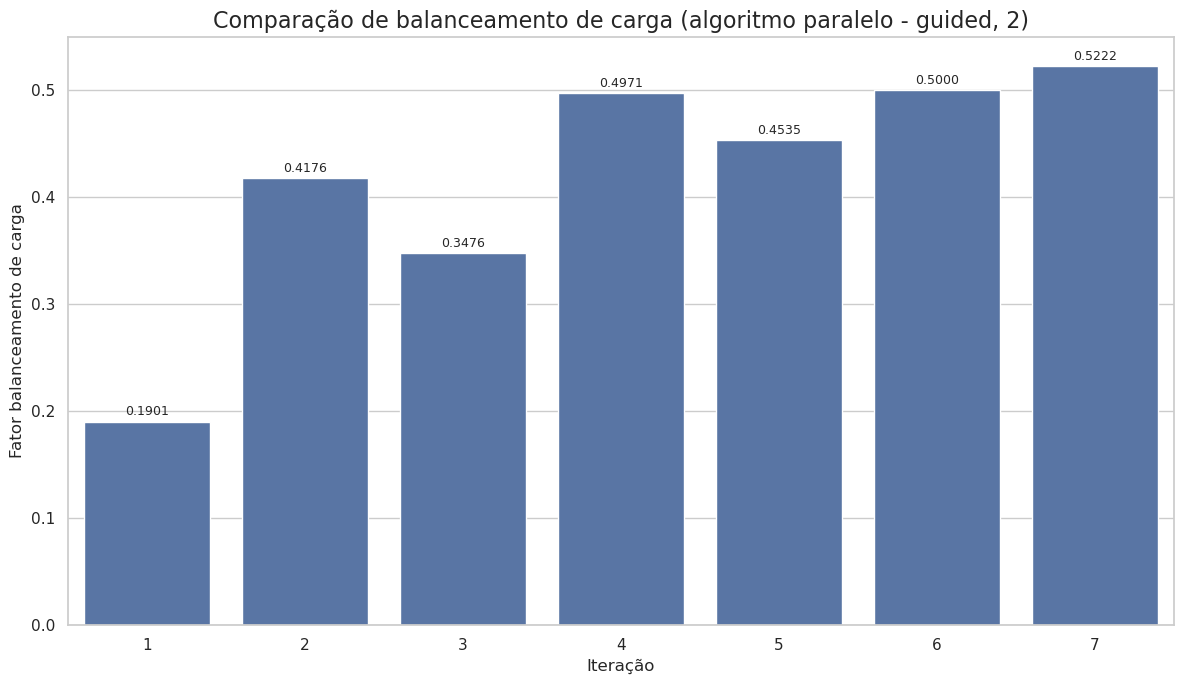

In [145]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - guided, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.55)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [146]:
print("Speed-up")
print("Média:", guided_df["speed_up"].mean())
print("Desvio padrão:", guided_df["speed_up"].std())
print("Valor mínimo:", guided_df["speed_up"].min())
print("Valor máximo:", guided_df["speed_up"].max())

Speed-up
Média: 1.0028878
Desvio padrão: 0.053600896
Valor mínimo: 0.88627464
Valor máximo: 1.0473824


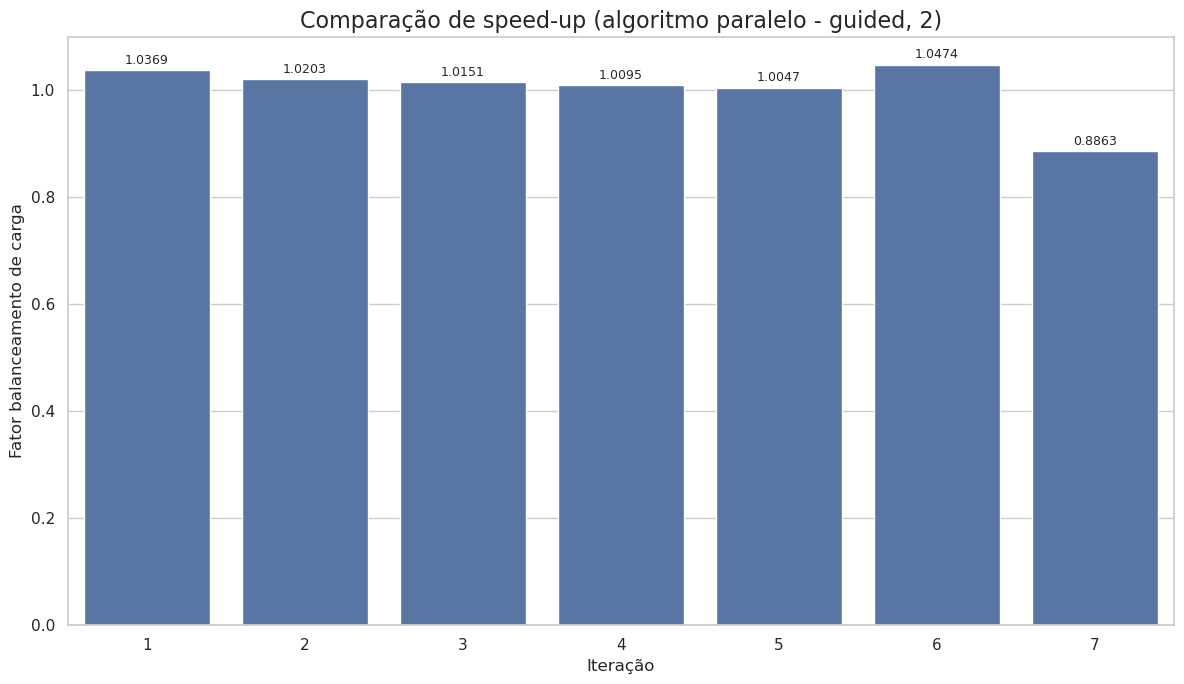

In [147]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - guided, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.1)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [148]:
print("Eficiência")
print("Média:", guided_df["eficiencia"].mean())
print("Desvio padrão:", guided_df["eficiencia"].std())
print("Valor mínimo:", guided_df["eficiencia"].min())
print("Valor máximo:", guided_df["eficiencia"].max())

Eficiência
Média: 0.25072196
Desvio padrão: 0.013400224
Valor mínimo: 0.22156866
Valor máximo: 0.2618456


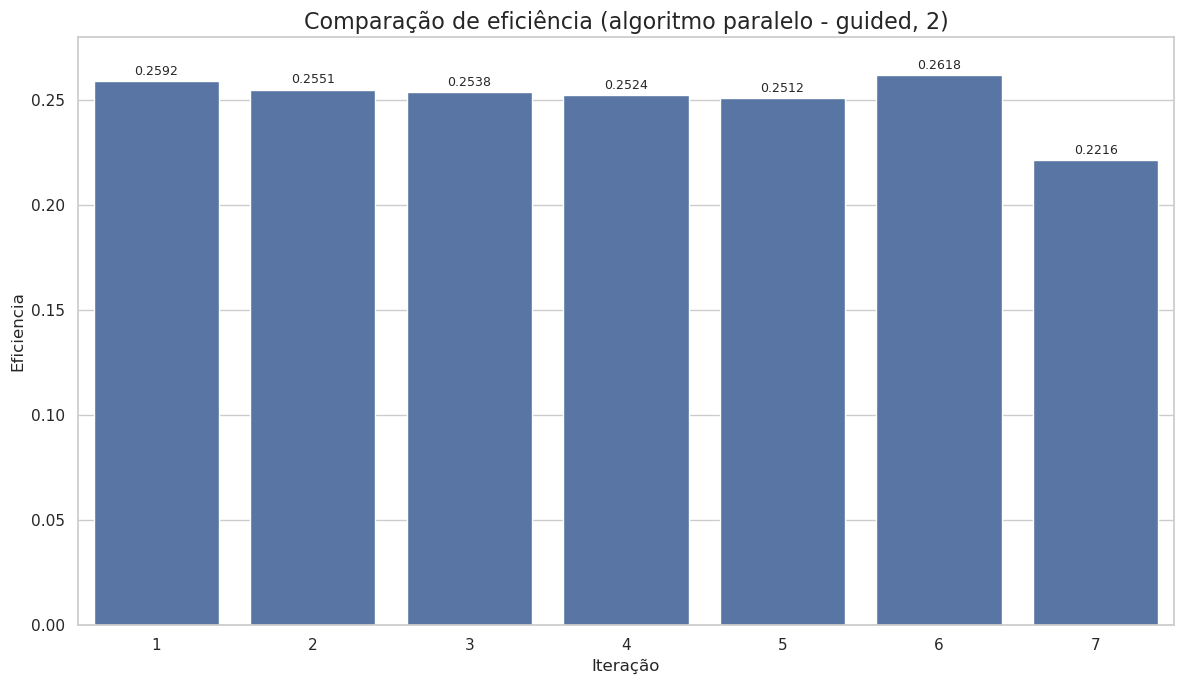

In [149]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - guided, 2)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.28)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Guided, 4

In [150]:
guided_df: pd.DataFrame = results_df.query("nome_modo == 'guided' and valor_modo == 4").copy()
guided_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
98,1,9.481663,0.5,guided,4,0.463415,1.026827,0.256707
99,2,9.484815,0.5,guided,4,0.341772,1.016776,0.254194
100,3,9.494643,0.5,guided,4,0.263889,1.011511,0.252878
101,4,9.530169,0.5,guided,4,0.263889,1.005975,0.251494
102,5,9.440854,0.5,guided,4,0.386667,1.014359,0.253590
103,6,5.547305,0.5,guided,4,0.342466,1.049172,0.262293
104,7,5.564983,0.5,guided,4,0.426966,1.030288,0.257572


##### Tempo de execução

In [151]:
print("TEMPO")
print("Média:", guided_df["tempo"].mean())
print("Desvio padrão:", guided_df["tempo"].std())
print("Valor mínimo:", guided_df["tempo"].min())
print("Valor máximo:", guided_df["tempo"].max())

TEMPO
Média: 8.36349
Desvio padrão: 1.9179667
Valor mínimo: 5.547305
Valor máximo: 9.530169


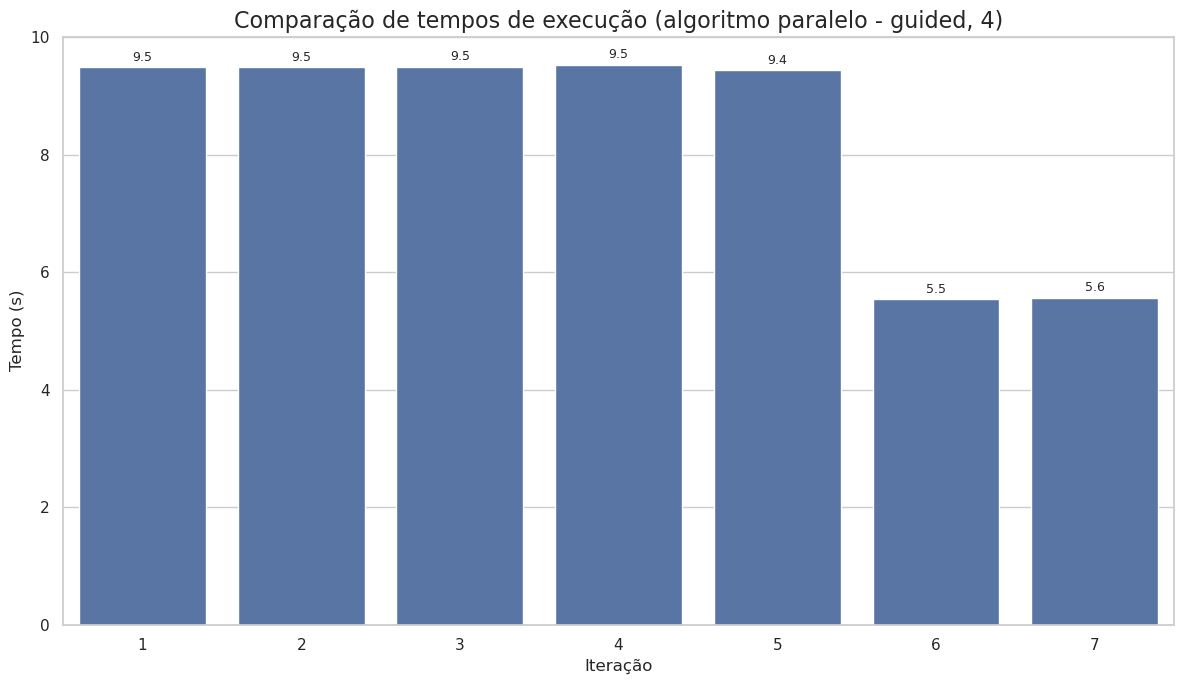

In [152]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - guided, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [153]:
print("Fab")
print("Média:", guided_df["Fab"].mean())
print("Desvio padrão:", guided_df["Fab"].std())
print("Valor mínimo:", guided_df["Fab"].min())
print("Valor máximo:", guided_df["Fab"].max())

Fab
Média: 0.3555804671428572
Desvio padrão: 0.07623193825218705
Valor mínimo: 0.26388889
Valor máximo: 0.46341463


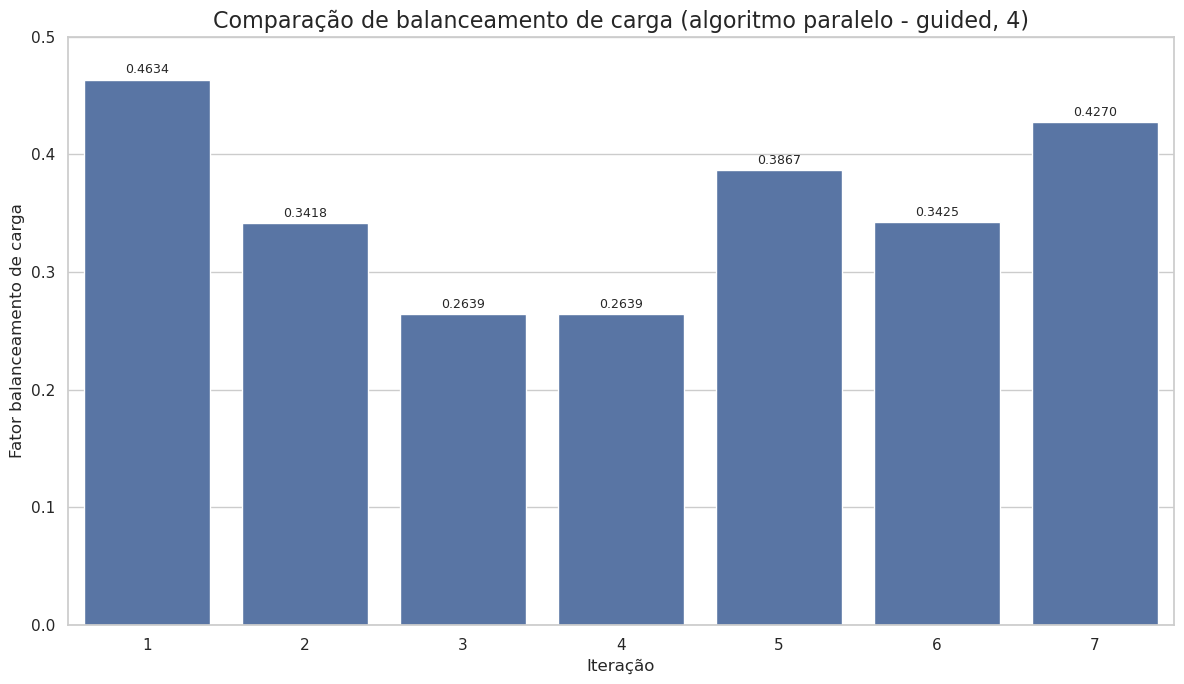

In [154]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - guided, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.5)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [155]:
print("Speed-up")
print("Média:", guided_df["speed_up"].mean())
print("Desvio padrão:", guided_df["speed_up"].std())
print("Valor mínimo:", guided_df["speed_up"].min())
print("Valor máximo:", guided_df["speed_up"].max())

Speed-up
Média: 1.0221299
Desvio padrão: 0.014621282
Valor mínimo: 1.0059751
Valor máximo: 1.0491723


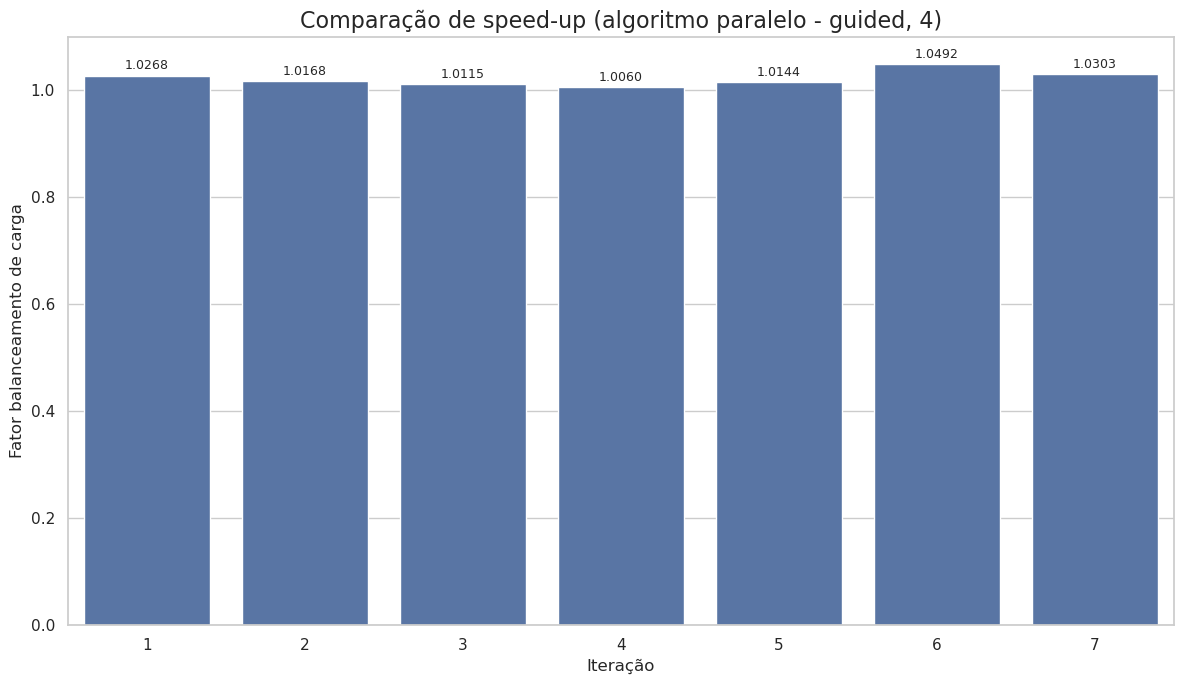

In [156]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - guided, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.1)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [157]:
print("Eficiência")
print("Média:", guided_df["eficiencia"].mean())
print("Desvio padrão:", guided_df["eficiencia"].std())
print("Valor mínimo:", guided_df["eficiencia"].min())
print("Valor máximo:", guided_df["eficiencia"].max())

Eficiência
Média: 0.25553247
Desvio padrão: 0.0036553205
Valor mínimo: 0.25149378
Valor máximo: 0.26229307


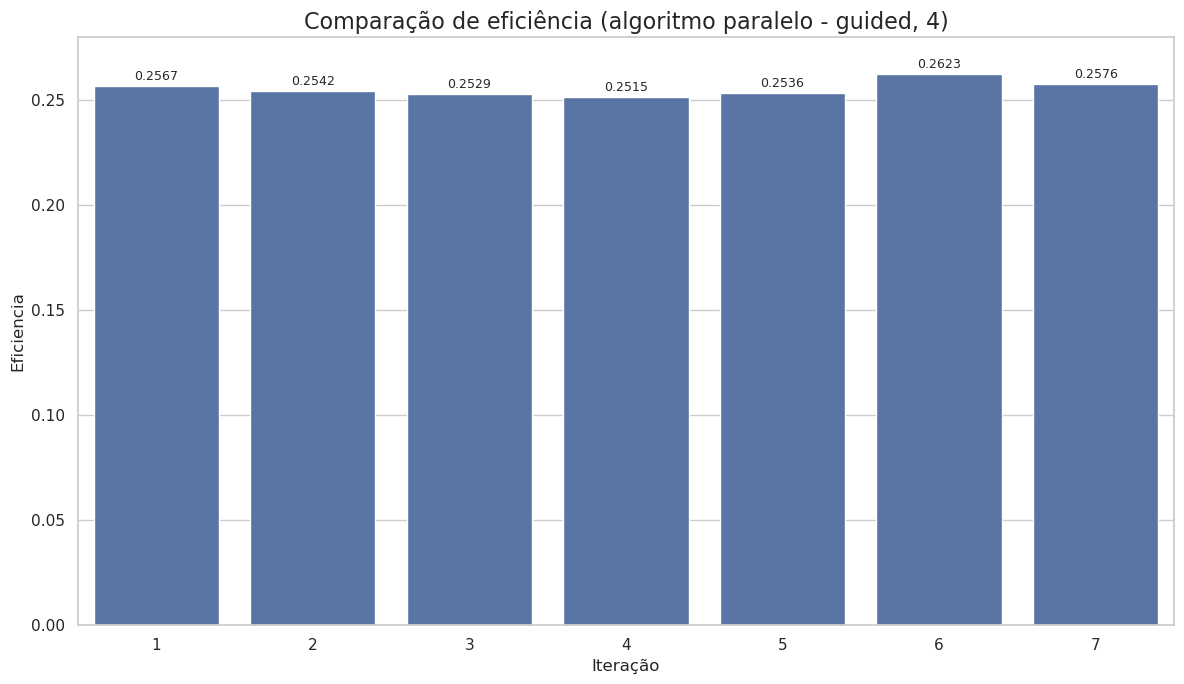

In [158]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - guided, 4)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.28)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Guided, 8

In [159]:
guided_df: pd.DataFrame = results_df.query("nome_modo == 'guided' and valor_modo == 8").copy()
guided_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
105,1,11.572992,0.5,guided,8,0.424242,0.841272,0.210318
106,2,9.555800,0.5,guided,8,0.490446,1.009223,0.252306
107,3,9.537188,0.5,guided,8,0.464481,1.006999,0.251750
108,4,9.504136,0.5,guided,8,0.215827,1.008731,0.252183
109,5,9.516364,0.5,guided,8,0.413580,1.006310,0.251578
110,6,5.588932,0.5,guided,8,0.385093,1.041358,0.260339
111,7,5.659814,0.5,guided,8,0.469945,1.013026,0.253256


##### Tempo de execução

In [160]:
print("TEMPO")
print("Média:", guided_df["tempo"].mean())
print("Desvio padrão:", guided_df["tempo"].std())
print("Valor mínimo:", guided_df["tempo"].min())
print("Valor máximo:", guided_df["tempo"].max())

TEMPO
Média: 8.705032
Desvio padrão: 2.2331498
Valor mínimo: 5.588932
Valor máximo: 11.572992


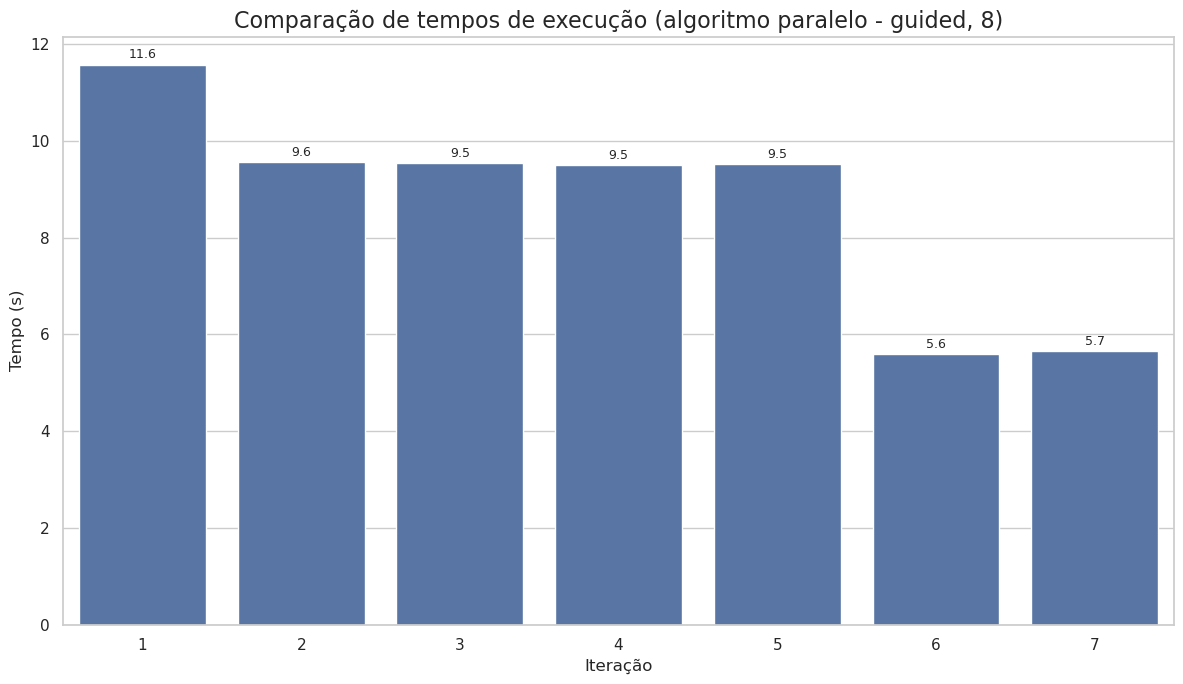

In [161]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - guided, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [162]:
print("Fab")
print("Média:", guided_df["Fab"].mean())
print("Desvio padrão:", guided_df["Fab"].std())
print("Valor mínimo:", guided_df["Fab"].min())
print("Valor máximo:", guided_df["Fab"].max())

Fab
Média: 0.4090878957142857
Desvio padrão: 0.09270595182499825
Valor mínimo: 0.21582734
Valor máximo: 0.49044586


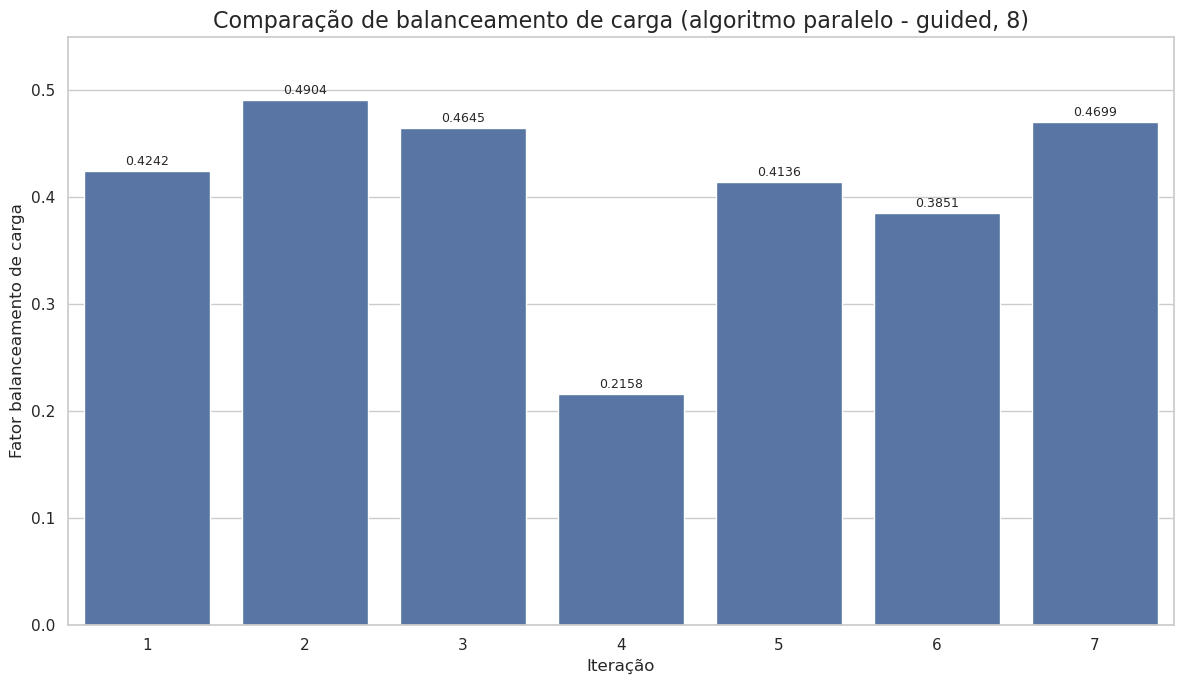

In [163]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - guided, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.55)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [164]:
print("Speed-up")
print("Média:", guided_df["speed_up"].mean())
print("Desvio padrão:", guided_df["speed_up"].std())
print("Valor mínimo:", guided_df["speed_up"].min())
print("Valor máximo:", guided_df["speed_up"].max())

Speed-up
Média: 0.9895597
Desvio padrão: 0.06653566
Valor mínimo: 0.8412716
Valor máximo: 1.041358


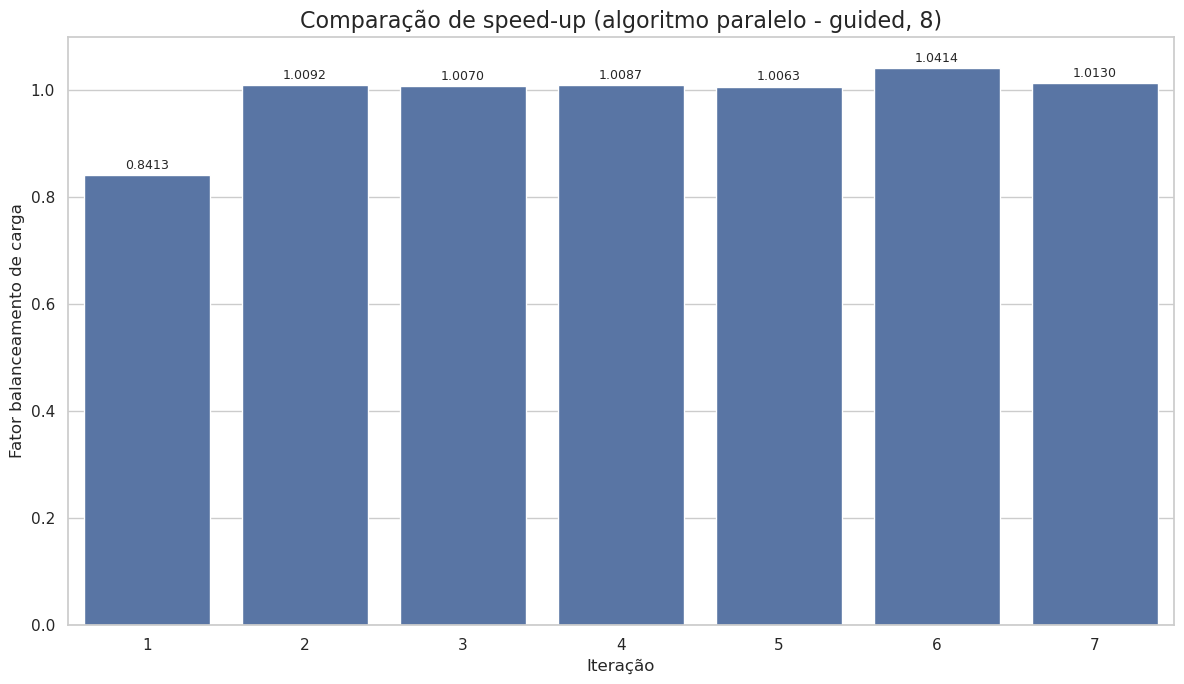

In [165]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - guided, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.1)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [166]:
print("Eficiência")
print("Média:", guided_df["eficiencia"].mean())
print("Desvio padrão:", guided_df["eficiencia"].std())
print("Valor mínimo:", guided_df["eficiencia"].min())
print("Valor máximo:", guided_df["eficiencia"].max())

Eficiência
Média: 0.24738993
Desvio padrão: 0.016633915
Valor mínimo: 0.2103179
Valor máximo: 0.2603395


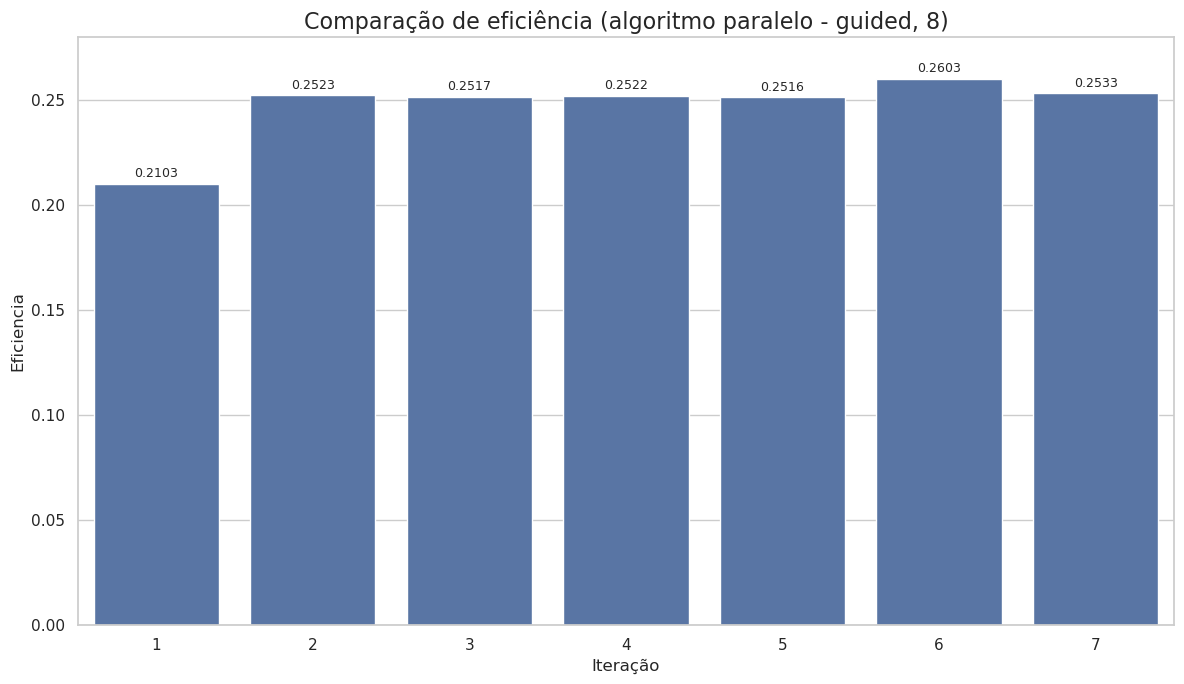

In [167]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - guided, 8)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.28)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Guided, 16

In [168]:
guided_df: pd.DataFrame = results_df.query("nome_modo == 'guided' and valor_modo == 16").copy()
guided_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
112,1,9.444173,0.5,guided,16,0.360000,1.030903,0.257726
113,2,9.515241,0.5,guided,16,0.204225,1.013525,0.253381
114,3,9.439447,0.5,guided,16,0.380952,1.017426,0.254356
115,4,9.461076,0.5,guided,16,0.250000,1.013322,0.253330
116,5,9.482745,0.5,guided,16,0.401361,1.009878,0.252470
117,6,6.765128,0.5,guided,16,0.269737,0.860306,0.215076
118,7,6.665881,0.5,guided,16,0.344156,0.860132,0.215033


##### Tempo de execução

In [169]:
print("TEMPO")
print("Média:", guided_df["tempo"].mean())
print("Desvio padrão:", guided_df["tempo"].std())
print("Valor mínimo:", guided_df["tempo"].min())
print("Valor máximo:", guided_df["tempo"].max())

TEMPO
Média: 8.681956
Desvio padrão: 1.3438879
Valor mínimo: 6.665881
Valor máximo: 9.515241


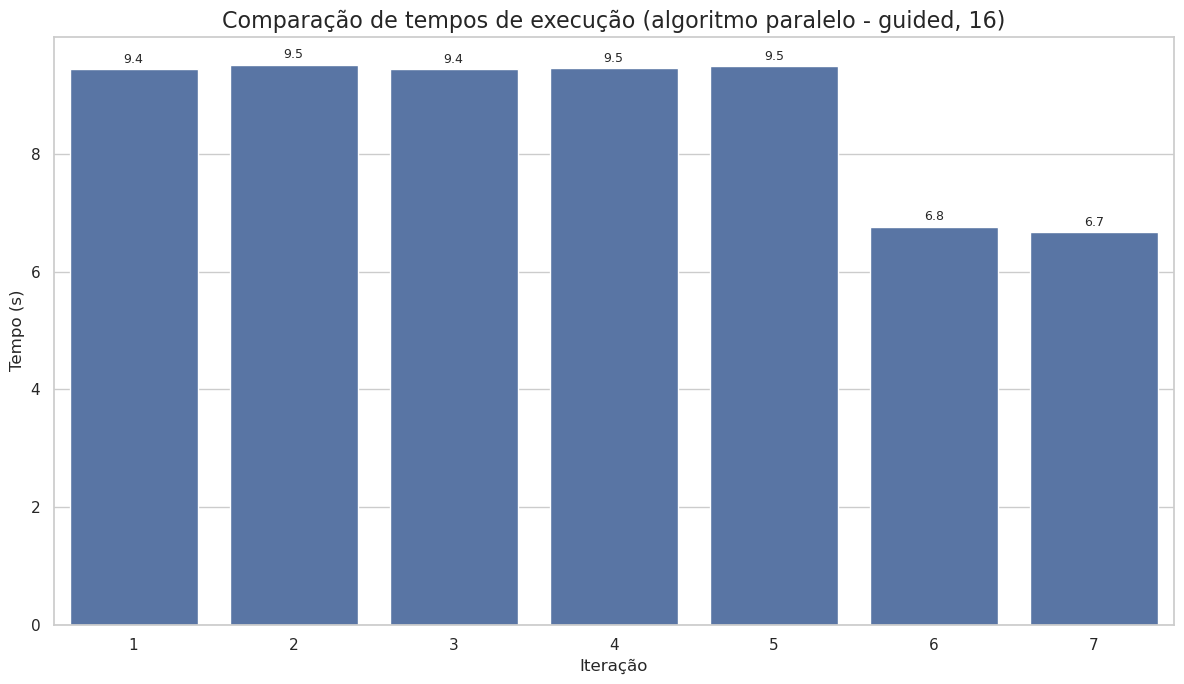

In [170]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo paralelo - guided, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Fator de balanceamento de carga (Fab)

In [171]:
print("Fab")
print("Média:", guided_df["Fab"].mean())
print("Desvio padrão:", guided_df["Fab"].std())
print("Valor mínimo:", guided_df["Fab"].min())
print("Valor máximo:", guided_df["Fab"].max())

Fab
Média: 0.31577585
Desvio padrão: 0.07441268421905882
Valor mínimo: 0.20422535
Valor máximo: 0.40136054


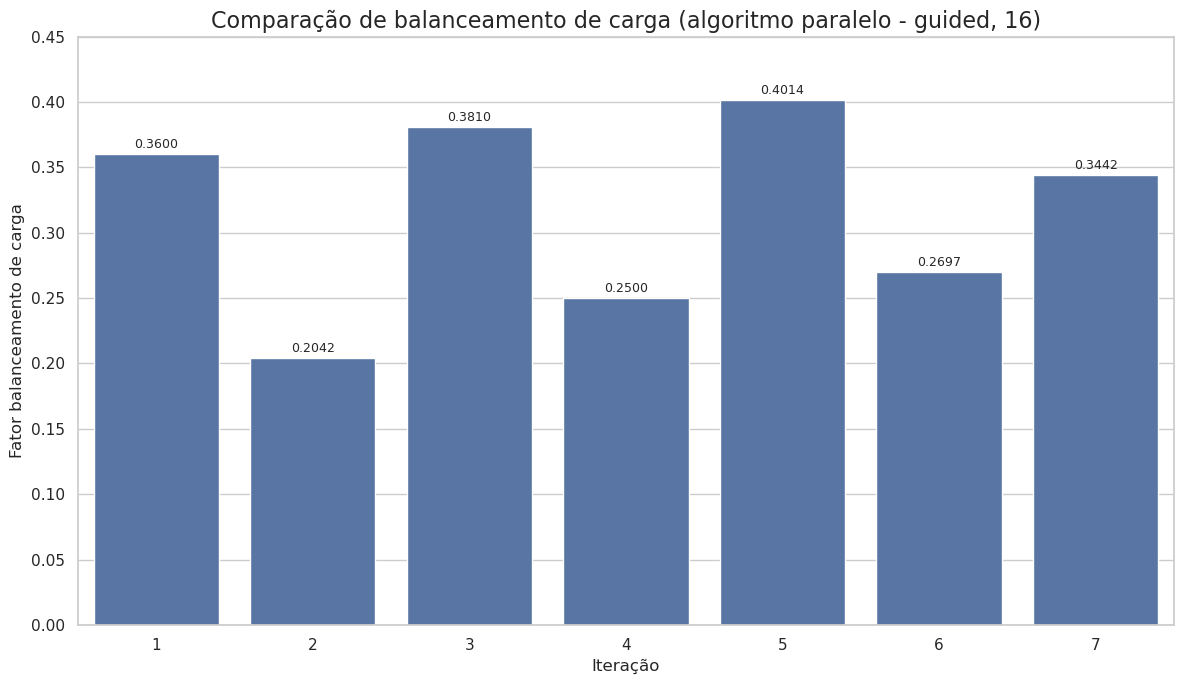

In [172]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - guided, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 0.45)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### *Speed-up*

In [173]:
print("Speed-up")
print("Média:", guided_df["speed_up"].mean())
print("Desvio padrão:", guided_df["speed_up"].std())
print("Valor mínimo:", guided_df["speed_up"].min())
print("Valor máximo:", guided_df["speed_up"].max())

Speed-up
Média: 0.9722131
Desvio padrão: 0.07680002
Valor mínimo: 0.86013174
Valor máximo: 1.0309033


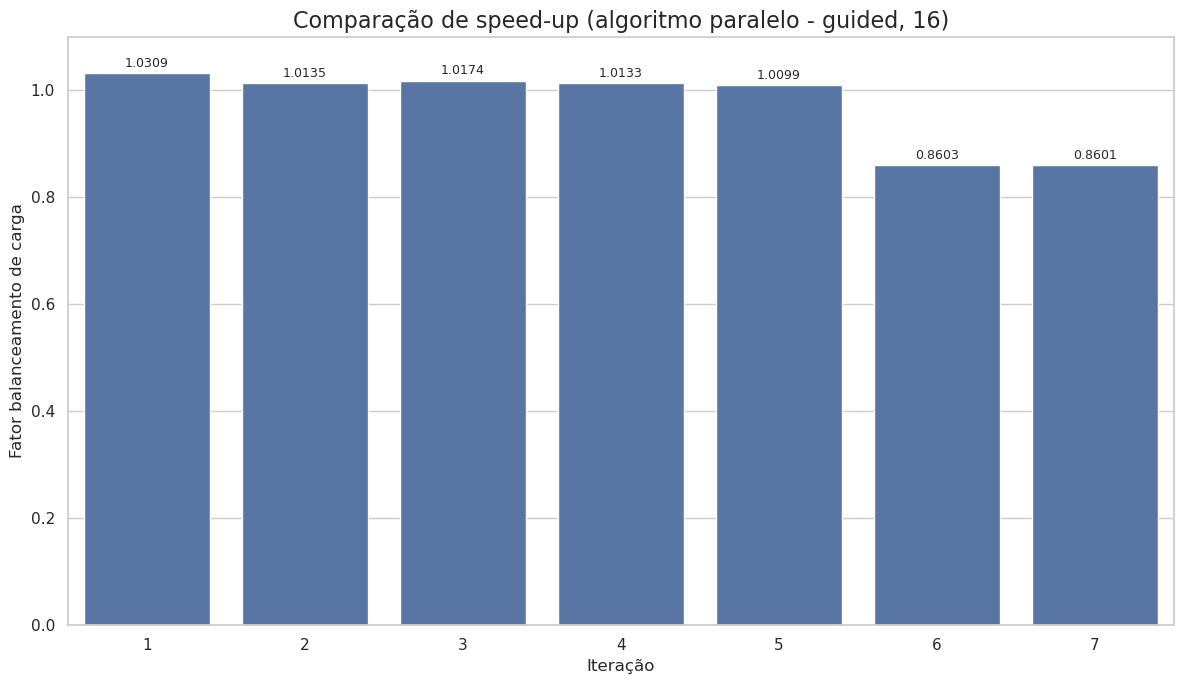

In [174]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="speed_up")
plt.title("Comparação de speed-up (algoritmo paralelo - guided, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)
plt.ylim(0.0, 1.1)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### Eficiência

In [175]:
print("Eficiência")
print("Média:", guided_df["eficiencia"].mean())
print("Desvio padrão:", guided_df["eficiencia"].std())
print("Valor mínimo:", guided_df["eficiencia"].min())
print("Valor máximo:", guided_df["eficiencia"].max())

Eficiência
Média: 0.24305327
Desvio padrão: 0.019200005
Valor mínimo: 0.21503294
Valor máximo: 0.25772583


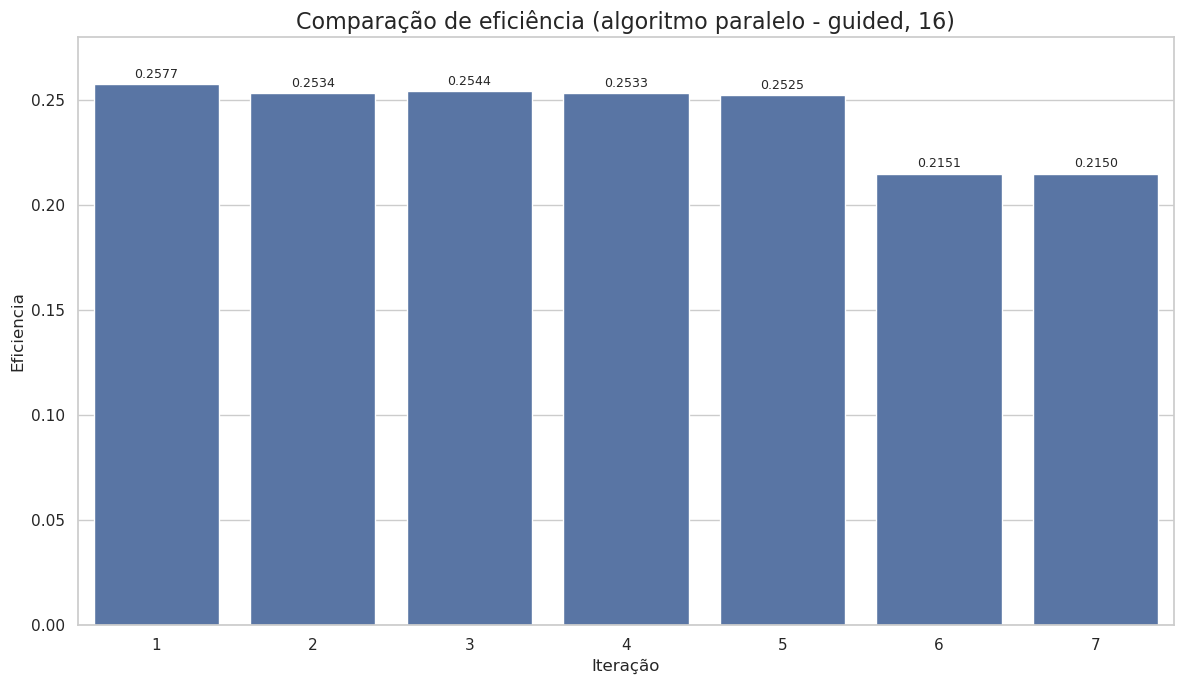

In [176]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=guided_df, x="interacao", y="eficiencia")
plt.title("Comparação de eficiência (algoritmo paralelo - guided, 16)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.28)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### Guided, todos juntos

In [177]:
guided_df: pd.DataFrame = results_df[results_df["nome_modo"] == "guided"]
guided_df.head(10)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
84,1,9.396616,0.5,guided,1,0.060606,1.036121,0.259030
85,2,9.536132,0.5,guided,1,0.372781,1.011305,0.252826
86,3,9.445127,0.5,guided,1,0.409938,1.016814,0.254203
87,4,11.499469,0.5,guided,1,0.371257,0.833700,0.208425
88,5,9.469010,0.5,guided,1,0.491429,1.011343,0.252836
89,6,5.587298,0.5,guided,1,0.418079,1.041663,0.260416
90,7,5.553770,0.5,guided,1,0.142857,1.032368,0.258092
91,1,9.389120,0.5,guided,2,0.190141,1.036948,0.259237
92,2,9.451968,0.5,guided,2,0.417647,1.020310,0.255077
93,3,9.461125,0.5,guided,2,0.347561,1.015095,0.253774


##### Tempo de execução

In [178]:
print("TEMPO")
print("Média:", guided_df["tempo"].mean())
print("Desvio padrão:", guided_df["tempo"].std())
print("Valor mínimo:", guided_df["tempo"].min())
print("Valor máximo:", guided_df["tempo"].max())

TEMPO
Média: 8.574214
Desvio padrão: 1.8038262
Valor mínimo: 5.547305
Valor máximo: 11.572992


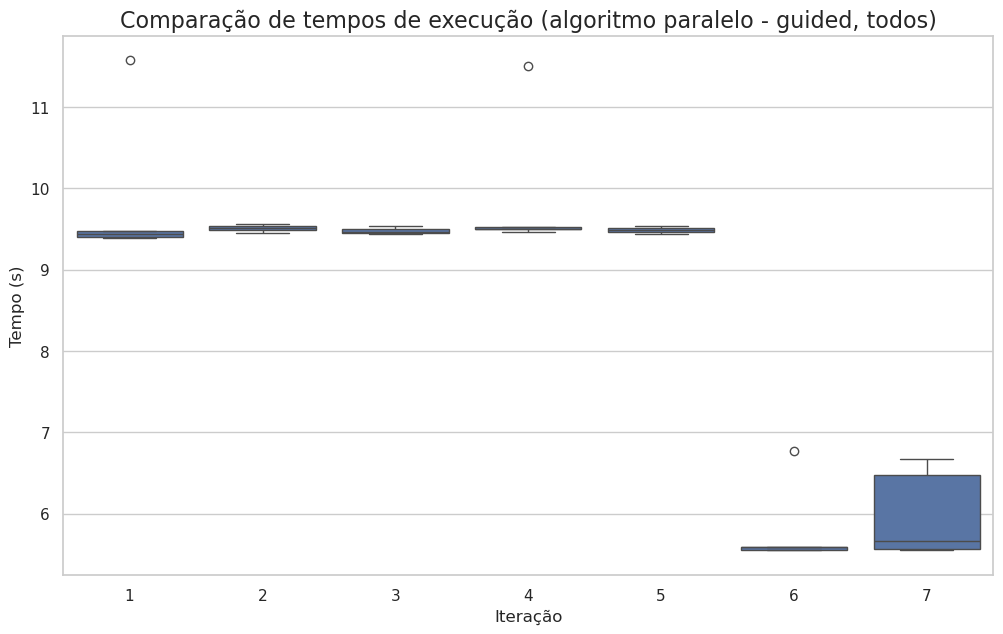

In [179]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=guided_df, x="interacao", y="tempo")

plt.title("Comparação de tempos de execução (algoritmo paralelo - guided, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.show()

##### Fator de balanceamento de carga (Fab)

In [180]:
print("Fab")
print("Média:", guided_df["Fab"].mean())
print("Desvio padrão:", guided_df["Fab"].std())
print("Valor mínimo:", guided_df["Fab"].min())
print("Valor máximo:", guided_df["Fab"].max())

Fab
Média: 0.3645207437142857
Desvio padrão: 0.11056545169688128
Valor mínimo: 0.06060606
Valor máximo: 0.52222222


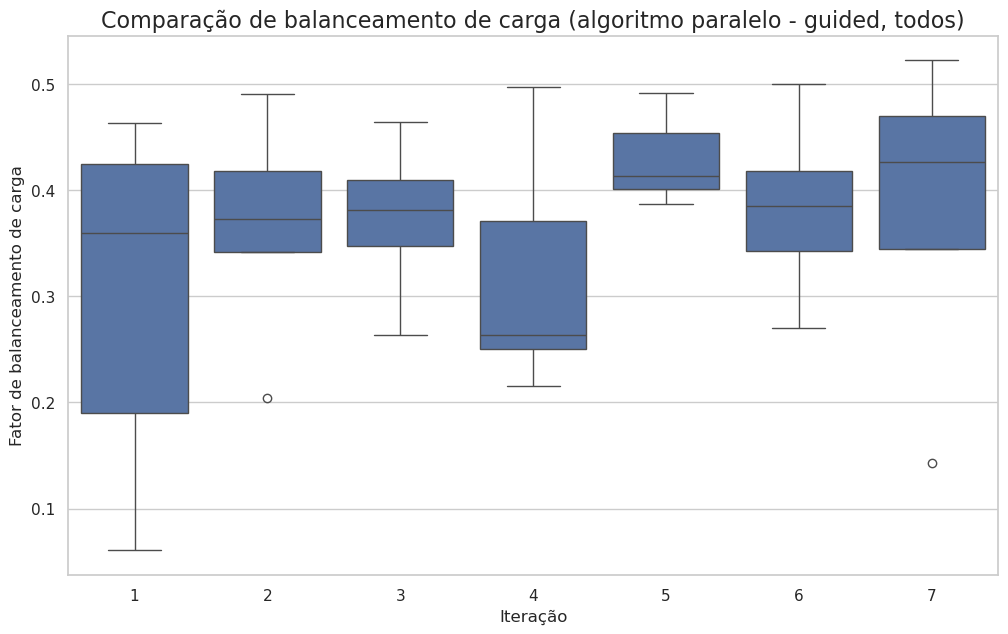

In [181]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=guided_df, x="interacao", y="Fab")

plt.title("Comparação de balanceamento de carga (algoritmo paralelo - guided, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de balanceamento de carga", fontsize=12)
plt.show()

##### *Speed-up*

In [182]:
print("Speed-up")
print("Média:", guided_df["speed_up"].mean())
print("Desvio padrão:", guided_df["speed_up"].std())
print("Valor mínimo:", guided_df["speed_up"].min())
print("Valor máximo:", guided_df["speed_up"].max())

Speed-up
Média: 0.9968813
Desvio padrão: 0.05991887
Valor mínimo: 0.8337005
Valor máximo: 1.0491723


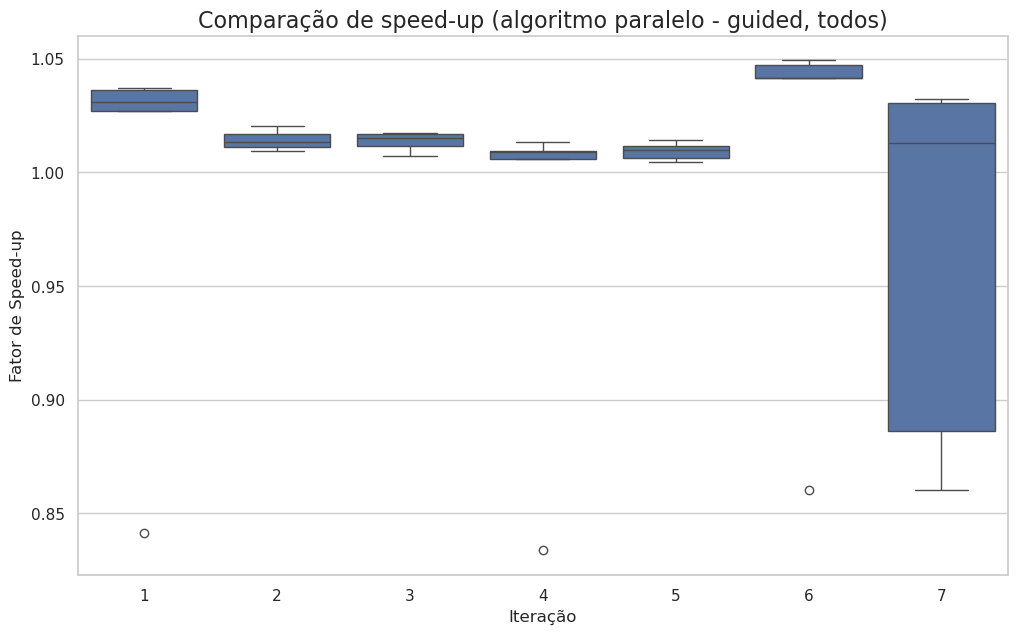

In [183]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=guided_df, x="interacao", y="speed_up")

plt.title("Comparação de speed-up (algoritmo paralelo - guided, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de Speed-up", fontsize=12)
plt.show()

##### Eficiência

In [184]:
print("Eficiência")
print("Média:", guided_df["eficiencia"].mean())
print("Desvio padrão:", guided_df["eficiencia"].std())
print("Valor mínimo:", guided_df["eficiencia"].min())
print("Valor máximo:", guided_df["eficiencia"].max())

Eficiência
Média: 0.24922033
Desvio padrão: 0.014979717
Valor mínimo: 0.20842512
Valor máximo: 0.26229307


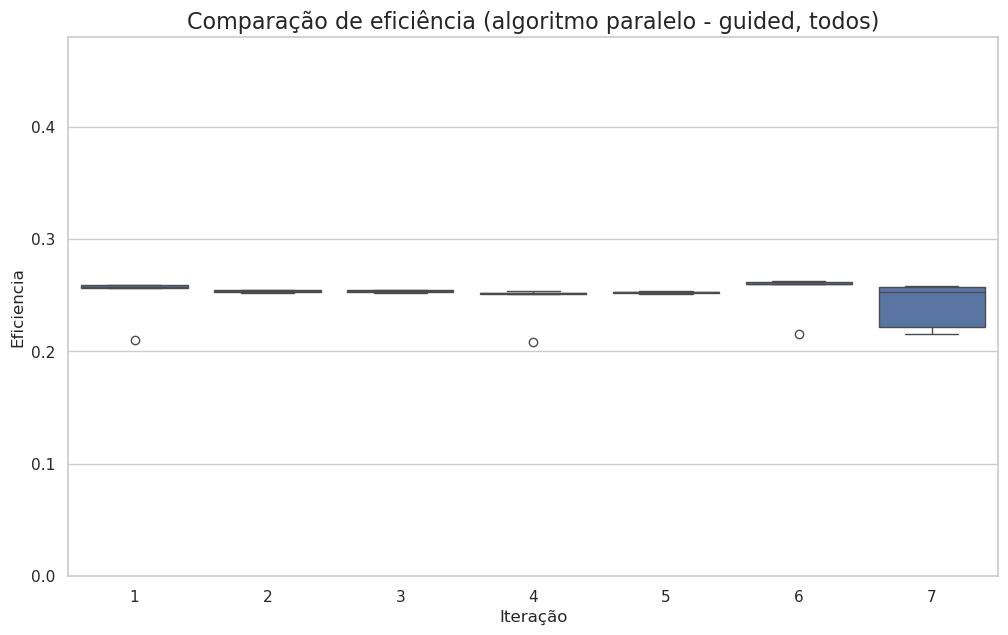

In [185]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=guided_df, x="interacao", y="eficiencia")

plt.title("Comparação de eficiência (algoritmo paralelo - guided, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.48)
plt.show()

## Analisando os resultados

In [186]:
Fab_df: pd.DataFrame = results_df[results_df["nome_modo"] != "sequencial"]

Fab_df["nome_modo"] = Fab_df["nome_modo"].cat.remove_unused_categories()
Fab_df.head()

,interacao,tempo,threshold,nome_modo,valor_modo,Fab,speed_up,eficiencia
7,1,11.402553,0.5,static,0,0.014493,0.853846,0.213462
8,2,9.502563,0.5,static,0,0.014493,1.014877,0.253719
9,3,9.499928,0.5,static,0,0.014493,1.010948,0.252737
10,4,11.049248,0.5,static,0,0.014493,0.867671,0.216918
11,5,9.529516,0.5,static,0,0.014493,1.004922,0.251230


#### Tempo de execução

In [187]:
print("TEMPO")
print("Média:", Fab_df["tempo"].mean())
print("Desvio padrão:", Fab_df["tempo"].std())
print("Valor mínimo:", Fab_df["tempo"].min())
print("Valor máximo:", Fab_df["tempo"].max())

TEMPO
Média: 7.673178
Desvio padrão: 2.0223227
Valor mínimo: 5.485201
Valor máximo: 11.572992


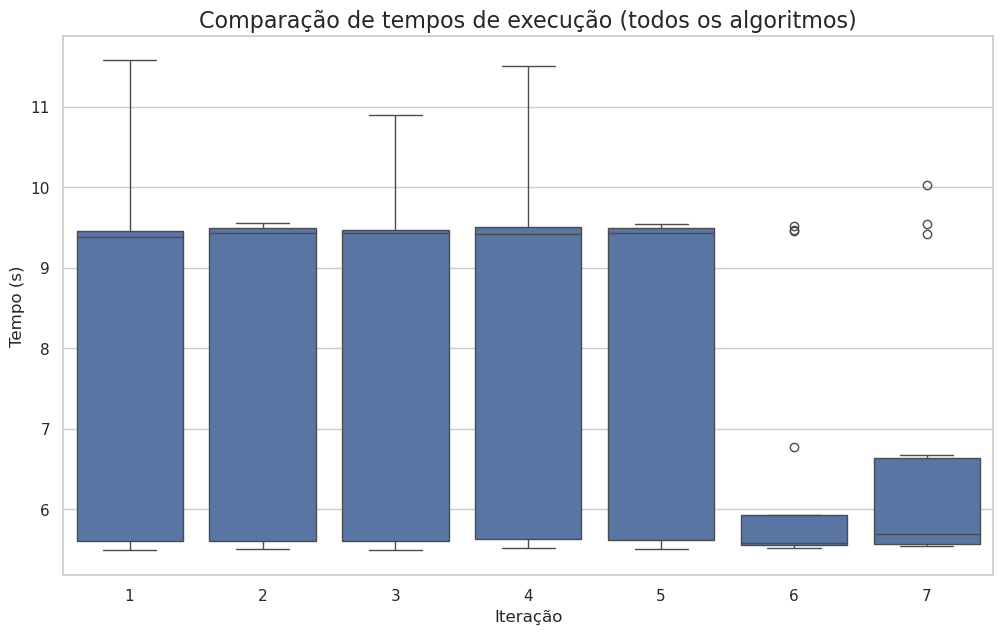

In [188]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=Fab_df, x="interacao", y="tempo")

plt.title("Comparação de tempos de execução (todos os algoritmos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)
plt.show()

#### Fator de balanceamento de carga (Fab)

In [189]:
print("Fab")
print("Média:", Fab_df["Fab"].mean())
print("Desvio padrão:", Fab_df["Fab"].std())
print("Valor mínimo:", Fab_df["Fab"].min())
print("Valor máximo:", Fab_df["Fab"].max())

Fab
Média: 0.26860691419642857
Desvio padrão: 0.18218545219997087
Valor mínimo: 0.01449275
Valor máximo: 0.52222222


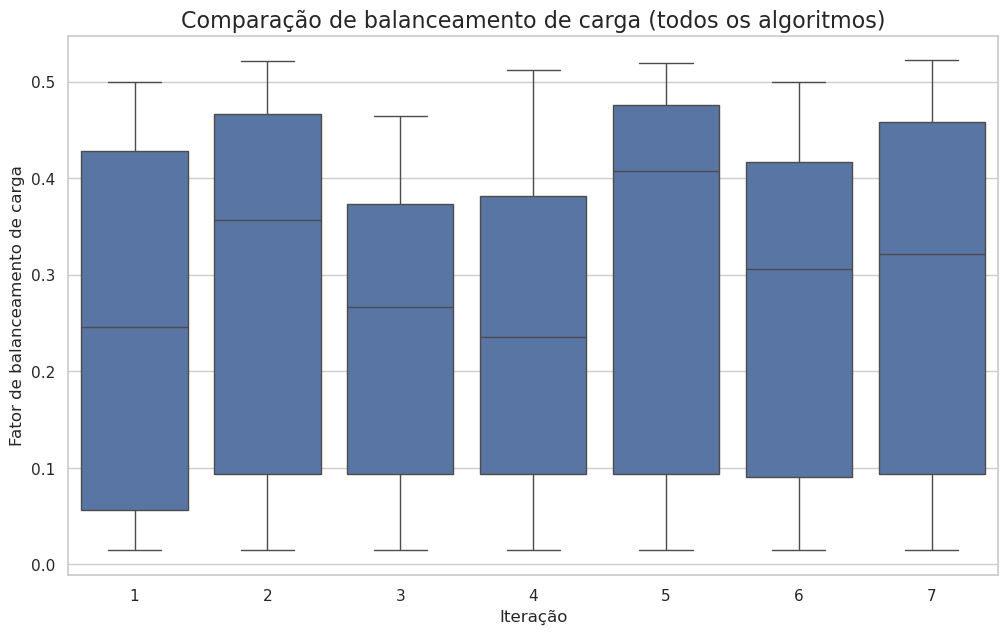

In [190]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=Fab_df, x="interacao", y="Fab")

plt.title("Comparação de balanceamento de carga (todos os algoritmos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de balanceamento de carga", fontsize=12)
plt.show()

##### *Speed-up*

In [191]:
print("Speed-up")
print("Média:", Fab_df["speed_up"].mean())
print("Desvio padrão:", Fab_df["speed_up"].std())
print("Valor mínimo:", Fab_df["speed_up"].min())
print("Valor máximo:", Fab_df["speed_up"].max())

Speed-up
Média: 1.1696966
Desvio padrão: 0.34304821
Valor mínimo: 0.57203025
Valor máximo: 1.7712668


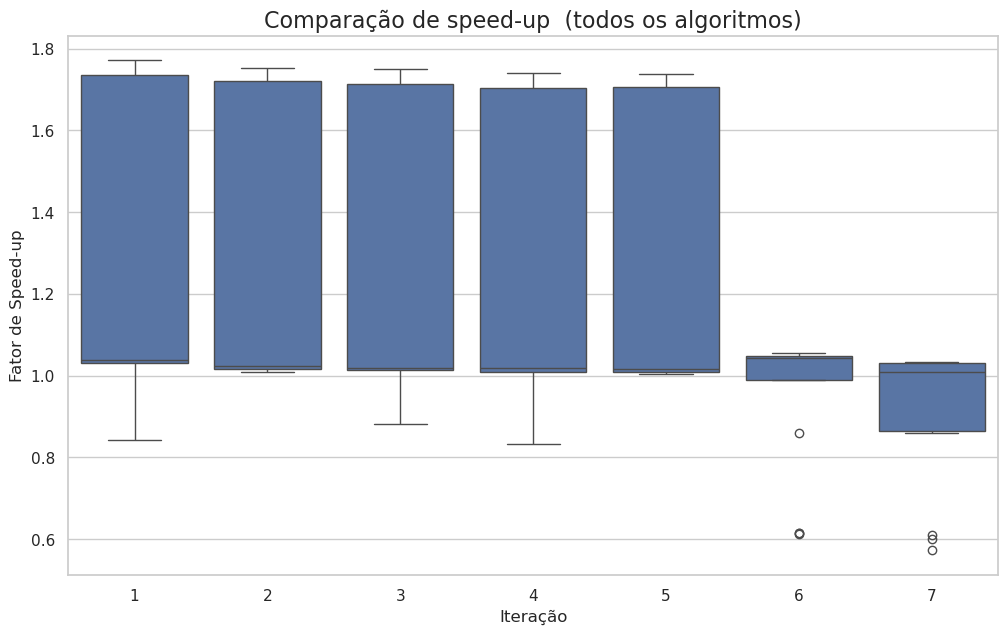

In [192]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=Fab_df, x="interacao", y="speed_up")

plt.title("Comparação de speed-up  (todos os algoritmos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de Speed-up", fontsize=12)
plt.show()

##### Eficiência

In [193]:
print("Eficiência")
print("Média:", Fab_df["eficiencia"].mean())
print("Desvio padrão:", Fab_df["eficiencia"].std())
print("Valor mínimo:", Fab_df["eficiencia"].min())
print("Valor máximo:", Fab_df["eficiencia"].max())

Eficiência
Média: 0.29242414
Desvio padrão: 0.085762054
Valor mínimo: 0.14300756
Valor máximo: 0.4428167


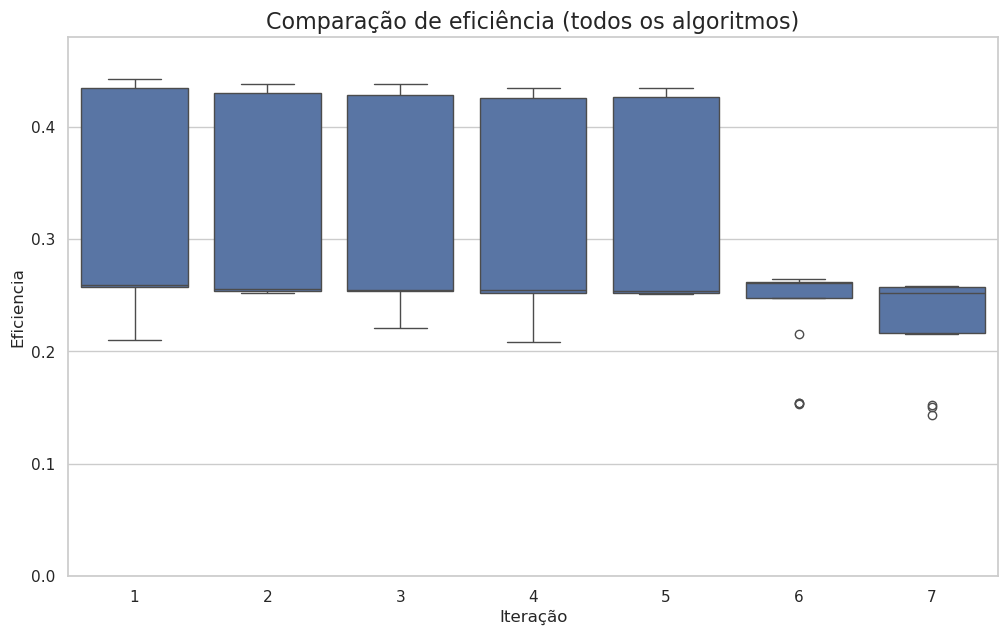

In [194]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=Fab_df, x="interacao", y="eficiencia")

plt.title("Comparação de eficiência (todos os algoritmos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia", fontsize=12)
plt.ylim(0.0, 0.48)
plt.show()

#### Comparação entre todas as diretivas

In [222]:
for strategy in Fab_df["nome_modo"].unique():
    print("Diretiva", strategy)
    print("Tempo mínimo:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["tempo"].min(), 2))
    print("Tempo médio:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["tempo"].mean(), 2))
    print("Tempo máximo:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["tempo"].max(), 2))
    print("F_ab mínimo:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["Fab"].min(), 2))
    print("F_ab médio:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["Fab"].mean(), 2))
    print("F_ab máximo:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["Fab"].max(), 2))
    print("Speed-up mínimo:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["speed_up"].min(), 2))
    print("Speed-up médio:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["speed_up"].mean(), 2))
    print("Speed-up máximo:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["speed_up"].max(), 2))
    print("Eficiência mínima:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["eficiencia"].min(), 2))
    print("Eficiência média:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["eficiencia"].mean(), 2))
    print("Eficiência máxima:", np.round(Fab_df[Fab_df["nome_modo"] == strategy]["eficiencia"].max(), 2), end="\n\n\n")

Diretiva static
Tempo mínimo: 5.54
Tempo médio: 7.56
Tempo máximo: 11.4
F_ab mínimo: 0.01
F_ab médio: 0.07
F_ab máximo: 0.2
Speed-up mínimo: 0.57
Speed-up médio: 1.2
Speed-up máximo: 1.75
Eficiência mínima: 0.14
Eficiência média: 0.3
Eficiência máxima: 0.44


Diretiva dynamic
Tempo mínimo: 5.49
Tempo médio: 6.91
Tempo máximo: 9.47
F_ab mínimo: 0.11
F_ab médio: 0.41
F_ab máximo: 0.52
Speed-up mínimo: 0.61
Speed-up médio: 1.3
Speed-up máximo: 1.77
Eficiência mínima: 0.15
Eficiência média: 0.33
Eficiência máxima: 0.44


Diretiva guided
Tempo mínimo: 5.55
Tempo médio: 8.57
Tempo máximo: 11.57
F_ab mínimo: 0.06
F_ab médio: 0.36
F_ab máximo: 0.52
Speed-up mínimo: 0.83
Speed-up médio: 1.0
Speed-up máximo: 1.05
Eficiência mínima: 0.21
Eficiência média: 0.25
Eficiência máxima: 0.26




### Teste de corretude

#### Consistência

Os testes foram realizados com 5 imagens de *label* de artérias coronárias retiradas do trabalho  [Imagecas](https://www.sciencedirect.com/science/article/abs/pii/S0895611123001052). Mais precisamente, as imagens: 120, 205, 510, 650, e 980.

#### Utilizando o terminal Linux (Bash)

Utilizando o comando `diff` com a *flag* `-q` e os hiperparâmetros `output_sequential.txt` e `output_openMP.txt` foi feita uma comparação entre os dois aquivos de saída.
<br>
O utilitário `diff` mostra quais são as diferenças, mas com a *flag* -q (*quiet*/*brief*), ele apenas dá um resumo se os arquivos são diferentes ou não.
<br>
Nesse teste, o `diff` não mostrou saída nenhuma. Isso é uma indicação de que os arquivo são idênticos.
<br>
É possível reproduzir o resultado no terminal Linux (Bash) utilizando o trecho de código abaixo.

```sh
diff -q output_sequential.txt output_openMP.txt
```

#### Comparação com algoritmo implementado em linguagem Python

O algoritmo de *bounding box* implementando nesse trabalho foi validado em contraste com o algoritmo Python abaixo.
```python
def get_crop(pre_label, img, label,enhance):
    x, y, z = np.where(pre_label == 1)
    img_shape = img.shape

    x_max = (x.max() + 5) if (x.max() + 5) <= img_shape[0] else img_shape[0]
    y_max = (y.max() + 5) if (y.max() + 5) <= img_shape[1] else img_shape[1]
    z_max = (z.max() + 5) if (z.max() + 5) <= img_shape[2] else img_shape[2]

    x_min = x.min() - 5 if (x.min() - 5) >= 0 else 0
    y_min = y.min() - 5 if (y.min() - 5) >= 0 else 0
    z_min = z.min() - 5 if (z.min() - 5) >= 0 else 0

    loc_max = [x_max, y_max, z_max]
    loc_min = [x_min, y_min, z_min]

    img_crop = img[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    label_crop = label[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    enhance_crop = enhance[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    return img_crop, label_crop, enhance_crop, loc_min, loc_max
```
O algoritmo acima for retirado do artigo [Imagecas](https://www.sciencedirect.com/science/article/abs/pii/S0895611123001052).
A saída do trecho acima foi salvo no arquivo `saida_validacao.txt`.
<br>
A implementação do teste está apresentada abaixo.

##### Execução do teste

In [ ]:
def get_crop(pre_label, img, label,enhance):
    x, y, z = np.where(pre_label == 1)
    img_shape = img.shape

    x_max = (x.max() + 5) if (x.max() + 5) <= img_shape[0] else img_shape[0]
    y_max = (y.max() + 5) if (y.max() + 5) <= img_shape[1] else img_shape[1]
    z_max = (z.max() + 5) if (z.max() + 5) <= img_shape[2] else img_shape[2]

    x_min = x.min() - 5 if (x.min() - 5) >= 0 else 0
    y_min = y.min() - 5 if (y.min() - 5) >= 0 else 0
    z_min = z.min() - 5 if (z.min() - 5) >= 0 else 0

    loc_max = [x_max, y_max, z_max]
    loc_min = [x_min, y_min, z_min]

    img_crop = img[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    label_crop = label[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    enhance_crop = enhance[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    return img_crop, label_crop, enhance_crop, loc_min, loc_max

### Melhor resultado (Fab)
As combinaçôes que demonstraram o melhor resultado de balanceamento de carga foram `(static)` e `(static, 1)` com `0,01449275` **(1,45%)**.
<br>
Resultado de todas as iterações.
<br>
### Pior resultado (Fab)
A combinação que demonstrou o melhor resultado de balanceamento de carga foi `(dynamic, 4)` com `0,52222222` **(52,22%)**.
<br>
Resultado da iteração 4.
<br>

### Melhor resultado (Tempo de execução)
A combinação que demonstrou o menor tempo de execução foi `(dynamic, 2)` com `5,485201` segundos.
<br>
Resultado da iteração 3.
<br>
O melhor tempo do algoritmo iterativo foi `5,733536` segundos.
<br>
Resultado da iteração 7.
<br>
### Pior resultado (Tempo de execução)
A combinação que demonstrou o maior tempo de execução foi `(guided, 8)` com `11,572992` segundos.
<br>
Resultado da iteração 1.
<br>
O pior tempo do algoritmo iterativo foi `9,73603` segundos.
<br>
Resultado da iteração 1.
<br>

### Melhor resultado (Speed-up)
A combinação que demonstrou o melhor *speed-up* foi `(dynamic, 2)` com `1,771267`.
<br>
Resultado da iteração 1.
<br>
### Pior resultado (Speed-up)
A combinação que demonstrou o pior *speed-up* foi `(static, 1)` com `0,572030`.
<br>
Resultado da iteração 7.

### Melhor resultado (Eficiência)
A combinação que demonstrou a melhor eficiência foi `(dynamic, 1)` com `0,4428167` *(44,28%)*.
<br>
Resultado da iteração 1.
<br>
### Pior resultado (Eficiência)
A combinação que demonstrou a pior eficiência foi `(static, 1)` com `0.143008` *(14,3%)*.
<br>
Resultado da iteração 7.
<br>